<a href="https://colab.research.google.com/github/bdashti/v/blob/main/2_1_Supervised_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Section 1, Cell 1: Initial Dataset Input (please also make sure to have a test sequence in section 2)
# Cell 1: Data Ingestion & QC Check
import numpy as np
import pandas as pd
import re
from scipy.stats import pearsonr

# ── GLOBAL CONSTANTS ──────────────────────────────────────────────────
# Single source of truth — referenced by every downstream cell.
RANDOM_SEED = 42

# ── LOAD ──────────────────────────────────────────────────────────────
df = pd.read_csv('/content/GGS3_logFC.csv')
n_raw = len(df)
print(f"Loaded {n_raw} sequences")

# ── BASIC QC ──────────────────────────────────────────────────────────
df.dropna(subset=['sequence', 'log2FC_end1', 'log2FC_end2',
                  'log2FC_mean', 'log2FC_std'], inplace=True)
print(f"After dropna: {len(df)} sequences ({n_raw - len(df)} dropped)")

# ── REPLICATE CORRELATION CHECK ───────────────────────────────────────
# Runs on raw df before any filtering — characterises experimental quality.
# r < 0.85 = poor replication; flag in thesis methods if so.
r_rep, p_rep = pearsonr(df['log2FC_end1'], df['log2FC_end2'])
print(f"Replicate correlation (raw): Pearson r = {r_rep:.4f} (p = {p_rep:.2e})")
if r_rep < 0.85:
    print("WARNING: Replicate correlation below 0.85 — flag in thesis.")
else:
    print("Replicate correlation acceptable.")

print("\nPhase 1 complete. df ready for QC visualization (Cell 2) and filtering (Cell 3).")

Loaded 124339 sequences
After dropna: 124339 sequences (0 dropped)
Replicate correlation (raw): Pearson r = 0.8050 (p = 0.00e+00)

Phase 1 complete. df ready for QC visualization (Cell 2) and filtering (Cell 3).


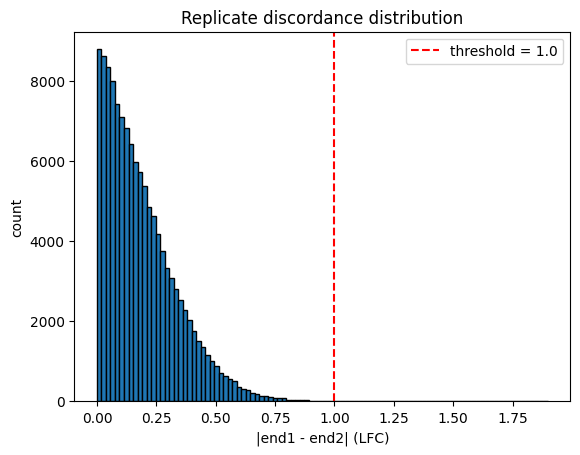

count    1.243390e+05
mean     1.876973e-01
std      1.499777e-01
min      3.532960e-07
25%      6.942972e-02
50%      1.536883e-01
75%      2.703018e-01
max      1.898648e+00
Name: replicate_delta, dtype: float64


In [2]:
#@title Cell 2: Noise Histogram
# Replicate discordance distribution — justifies the 1.0 LFC threshold
import matplotlib.pyplot as plt

df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
plt.hist(df['replicate_delta'], bins=100, edgecolor='black')
plt.axvline(1.0, color='red', linestyle='--', label='threshold = 1.0')
plt.xlabel('|end1 - end2| (LFC)')
plt.ylabel('count')
plt.title('Replicate discordance distribution')
plt.legend()
plt.show()
print(df['replicate_delta'].describe())

In [3]:
#@title Cell 3: Noise Filter
# Discordance filter + stratified noise filter
# Depends on: df from Cell 1
# Produces: df_clean (canonical working dataset for all downstream cells)

# ── REPLICATE DISCORDANCE FILTER ──────────────────────────────────────
# Discard sequences where end1 and end2 disagree by more than 1.0 LFC.
# With only two replicates, log2FC_std is just |end1-end2|/√2 — not a
# real distributional estimate. The raw delta is more honest.
df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
DISCORD_THRESHOLD = 1.0
df_clean = df[df['replicate_delta'] <= DISCORD_THRESHOLD].copy()
print(f"Discordance filter (>{DISCORD_THRESHOLD} LFC): removed "
      f"{len(df) - len(df_clean)} sequences "
      f"({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

# ── STRATIFIED NOISE FILTER ───────────────────────────────────────────
# Global 95th-percentile std cutoff would remove low-fitness extremes
# disproportionately — exactly the sequences you need most.
# Fix: apply the cutoff within 10 fitness deciles instead.
df_clean['lfc_bin'] = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)

def stratified_noise_mask(group, percentile=95):
    threshold = np.percentile(group['log2FC_std'], percentile)
    return group[group['log2FC_std'] <= threshold]

df_clean = (
    df_clean
    .groupby('lfc_bin', group_keys=False)
    .apply(stratified_noise_mask, include_groups=False)
    .reset_index(drop=True)
)

# ── CLEAN UP HELPER COLUMNS ───────────────────────────────────────────
df_clean.drop(columns=['replicate_delta', 'lfc_bin'], inplace=True, errors='ignore')

# ── SANITY CHECK ──────────────────────────────────────────────────────
n_raw   = len(df)
n_final = len(df_clean)
low_before = (df['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()
low_after  = (df_clean['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()

print(f"Retained: {n_final}/{n_raw} sequences ({n_final/n_raw*100:.1f}%)")
print(f"Low-fitness sequences preserved (bottom 5%): "
      f"{low_after}/{low_before} ({low_after/low_before*100:.1f}%)")
print(f"\nFitness distribution after filtering:")
print(df_clean['log2FC_mean'].describe().round(3))
print("\ndf_clean ready.")

Discordance filter (>1.0 LFC): removed 35 sequences (0.0%)
Retained: 118084/124339 sequences (95.0%)
Low-fitness sequences preserved (bottom 5%): 5813/6217 (93.5%)

Fitness distribution after filtering:
count    118084.000
mean         -0.064
std           0.338
min          -4.181
25%          -0.258
50%          -0.071
75%           0.119
max           3.995
Name: log2FC_mean, dtype: float64

df_clean ready.


In [4]:
#@title Cell 4: K-mer Tokenisation (5 bins)
# Positional K-mer Tokenisation
# Depends on: df_clean from Cell 3
# Produces: df_clean['kmers'] — space-separated positional 4-mer strings

N_POSITIONAL_BINS = 5   # change in one place — used everywhere downstream
KMER_K = 4

def get_positional_kmers(seq, k=KMER_K, n_bins=N_POSITIONAL_BINS):
    """
    Splits a DNA sequence into n_bins equal spatial regions and labels
    each k-mer with the bin its starting position falls into.

    Bin labels are zero-padded (BIN00, BIN01, ...) so feature names
    sort in spatial order — useful when reading SVD loadings.
    """
    n = len(seq)
    bin_size = n / n_bins
    kmers = []
    for i in range(n - k + 1):
        bin_idx = min(int(i / bin_size), n_bins - 1)
        kmers.append(f"BIN{bin_idx:02d}_{seq[i:i+k]}")
    return " ".join(kmers)

def dummy_analyzer(doc):
    return doc.split()

print(f"Generating positional k-mers (k={KMER_K}, bins={N_POSITIONAL_BINS})...")
df_clean['kmers'] = df_clean['sequence'].apply(get_positional_kmers)
print(f"Done. Example: {df_clean['kmers'].iloc[0][:80]}...")
print(f"Expected vocab ceiling: {N_POSITIONAL_BINS} bins × 4^{KMER_K} k-mers = {N_POSITIONAL_BINS * 4**KMER_K}")

Generating positional k-mers (k=4, bins=5)...
Done. Example: BIN00_AAGC BIN00_AGCA BIN00_GCAA BIN00_CAAA BIN00_AAAA BIN00_AAAG BIN00_AAGT BIN...
Expected vocab ceiling: 5 bins × 4^4 k-mers = 1280


In [5]:
# =====================================================================
# @title Cell 5: Vectorisation Engine & Biophysical Calculator (v2.1)
# =====================================================================
# v2.1 changes:
#   - Dropped Shape_Flex_SD, Bendability, Tm_Lethal_Window (all hardcoded 0.0).
#     Re-add these to the features dict once real implementations exist.
#   - get_v20_features() now returns X_train_sp / X_test_sp explicitly so
#     downstream cells don't reconstruct them by slicing the fused matrix.
import numpy as np
import pandas as pd
import re
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from tqdm.auto import tqdm

# E. coli codon relative adaptiveness table (Sharp & Li 1987)
ECOLI_W = {
    'TTT': 0.296, 'TTC': 1.000, 'TTA': 0.020, 'TTG': 0.020, 'CTT': 0.042, 'CTC': 0.037, 'CTA': 0.007, 'CTG': 1.000,
    'ATT': 0.185, 'ATC': 1.000, 'ATA': 0.003, 'ATG': 1.000, 'GTT': 0.221, 'GTC': 0.062, 'GTA': 0.076, 'GTG': 1.000,
    'TCT': 0.217, 'TCC': 0.744, 'TCA': 0.077, 'TCG': 0.017, 'AGT': 0.085, 'AGC': 1.000, 'CCT': 0.070, 'CCC': 0.012,
    'CCA': 0.194, 'CCG': 1.000, 'ACT': 0.185, 'ACC': 1.000, 'ACA': 0.076, 'ACG': 0.099, 'GCT': 0.210, 'GCC': 0.224,
    'GCA': 0.587, 'GCG': 1.000, 'TAT': 0.239, 'TAC': 1.000, 'TAA': 1.000, 'TAG': 0.008, 'TGA': 0.724, 'CAT': 0.217,
    'CAC': 1.000, 'CAA': 0.124, 'CAG': 1.000, 'AAT': 0.051, 'AAC': 1.000, 'AAA': 1.000, 'AAG': 0.253, 'GAT': 0.434,
    'GAC': 1.000, 'GAA': 1.000, 'GAG': 0.259, 'TGT': 0.500, 'TGC': 1.000, 'TGG': 1.000, 'CGT': 1.000, 'CGC': 0.356,
    'CGA': 0.004, 'CGG': 0.004, 'AGA': 0.002, 'AGG': 0.002, 'GGT': 1.000, 'GGC': 0.724, 'GGA': 0.057, 'GGG': 0.019,
}

RARE_CODONS = {'AGG', 'AGA', 'CTA', 'CGA', 'CGG', 'ATA', 'TTA', 'TTG'}


def calculate_master_features(seq):
    """Return a dict of biophysical features for one sequence."""
    seq = seq.upper()
    seq_len = len(seq)
    if seq_len == 0:
        return {'Size': 0}

    # 1. Composition
    gc_array = np.array([(1 if base in 'GC' else 0) for base in seq])
    gc_percent = gc_array.sum() / seq_len

    window_size = 50
    rolling_gcs = [gc_array[i:i+window_size].mean()
                   for i in range(max(1, seq_len - window_size + 1))]
    gc_variance = np.var(rolling_gcs) if seq_len >= window_size else 0.0

    # 2. Instability
    max_homo = max([len(m.group(0)) for m in re.finditer(r'(.)\1*', seq)] + [0])

    k = 4
    km_list = [seq[i:i+k] for i in range(seq_len - k + 1)]
    if km_list:
        counts = Counter(km_list)
        entropy = -sum((c/len(km_list)) * np.log2(c/len(km_list))
                       for c in counts.values())
    else:
        entropy = 0.0

    # 3. AT tract
    max_at = max([len(m.group(0)) for m in re.finditer(r'[AT]+', seq)] + [0])

    # 4. Promoter / RBS
    promoters = seq.count('TATAAT') + seq.count('TTGACA')
    rbs_str   = seq.count('AGGAGG') + seq.count('AGGA') + seq.count('GGAG')

    # 5. TF decoys
    ihf_sites  = len(re.findall(r'[AT]ATCAA.{4}[AT][AT][AG]', seq))
    lrp_sites  = len(re.findall(r'[CT]AG[ACT]A[AT].{3}[AT][GC][CT][AT][AG]', seq))
    crp_sites  = len(re.findall(r'TGTGA.{6}TCACA', seq))
    nagc_sites = len(re.findall(r'[AT]{2}.{3}CG.AA.T', seq))
    argr_sites = len(re.findall(r'A.TGAA.T.{4}ATTC.A.T', seq))

    # 6. H-NS xenogeneic silencing risk
    win = 10
    at_array = np.array([(1 if b in 'AT' else 0) for b in seq])
    window_at = [at_array[i:i+win].sum() / win
                 for i in range(max(1, seq_len - win + 1))]
    hns_affinity = sum(1 for w in window_at if w > 0.65) / len(window_at) if window_at else 0.0

    # 7. Translation
    codons = [seq[i:i+3] for i in range(0, seq_len - 2, 3) if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    ttc = 1.0 - np.exp(np.mean(np.log(w_vals))) if w_vals else 0.5

    rare_flags = [1 if c in RARE_CODONS else 0 for c in codons]
    rcc = sum(1 for i in range(len(rare_flags) - 4)
              if sum(rare_flags[i:i+5]) >= 2) if len(rare_flags) >= 5 else 0

    # 8. TIR_Proxy
    sd_patterns = [m.start() for m in re.finditer(r'(?=GGAG|AGGA)', seq)]
    start_codons = [m.start() for m in re.finditer(r'(?=ATG|GTG|TTG)', seq)]
    tir_proxy = 0.0
    for sd_pos in sd_patterns:
        downstream = [sc for sc in start_codons if sc > sd_pos]
        if downstream:
            dist = min(downstream) - sd_pos
            if 5 <= dist <= 9:    tir_proxy += 1.0
            elif 10 <= dist <= 14: tir_proxy += 0.5
            else:                  tir_proxy += 0.1

    # 9. mRNA decay risk
    rnase_e_hits = len(re.findall(r'[AG]A[AT][AT][AT]', seq))

    # 10. DNA shape proxies (active features only)
    dinucleotides = [seq[i:i+2] for i in range(seq_len - 1)]
    rigid_steps = sum(1 for dn in dinucleotides if dn in ['AA', 'TT', 'AT'])
    shape_rigidity_mean = rigid_steps / max(1, len(dinucleotides))

    g_count = seq.count('G')
    c_count = seq.count('C')
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0.0

    features = {
        'Size': seq_len,
        'GC_percent': gc_percent,
        'GC_Var': gc_variance,
        'Max_Homo': max_homo,
        'Entropy': entropy,
        'AT_tract': max_at,
        'Promoter_Str': promoters,
        'RBS_Str': rbs_str,
        'IHF': ihf_sites,
        'Lrp': lrp_sites,
        'CRP': crp_sites,
        'NagC': nagc_sites,
        'ArgR': argr_sites,
        'HNS_Affinity': hns_affinity,
        'TTC': ttc,
        'RCC': rcc,
        'TIR_Proxy': tir_proxy,
        'mRNA_Stability': rnase_e_hits,
        'Shape_Rigidity_Mean': shape_rigidity_mean,
        'GC_Skew': gc_skew,
    }
    return features


print("--- EXTRACTING BIOPHYSICAL FEATURES ---")
tqdm.pandas(desc="Biophysical Extraction")
biophys_df = pd.DataFrame(
    df_clean['sequence'].progress_apply(calculate_master_features).tolist(),
    index=df_clean.index
)
mech_feature_labels = biophys_df.columns.tolist()

for col in mech_feature_labels:
    df_clean[col] = biophys_df[col]

print(f"Extraction complete. Total biophysical features: {len(mech_feature_labels)}")


# =====================================================================
# V2.0 LEAK-FREE VECTORISATION & SCALING
# =====================================================================
def get_v20_features(df_train, df_test, mech_labels):
    """Train-only fit for scaler and vectorizer. Returns sparse k-mer
    matrices separately so downstream cells don't slice the fused matrix."""
    print("Fitting Scaler and Vectorizer on TRAIN set only...")

    # 1. Scale biophysical features
    scaler = StandardScaler()
    X_mech_train_scaled = scaler.fit_transform(df_train[mech_labels])
    X_mech_test_scaled  = scaler.transform(df_test[mech_labels])

    # 2. Vectorize positional k-mers
    def spatial_tokenizer(text):
        return text.split()

    vectorizer = CountVectorizer(tokenizer=spatial_tokenizer, token_pattern=None)
    X_sparse_train = vectorizer.fit_transform(df_train['kmers'])
    X_sparse_test  = vectorizer.transform(df_test['kmers'])

    # 3. Fusion (scale_factor balances dense vs sparse mass)
    scale_factor = X_sparse_train.shape[1] / len(mech_labels)
    X_train_combined = hstack([X_sparse_train, csr_matrix(X_mech_train_scaled * scale_factor)])
    X_test_combined  = hstack([X_sparse_test,  csr_matrix(X_mech_test_scaled  * scale_factor)])

    feature_names = vectorizer.get_feature_names_out()

    return {
        'X_train_combined': X_train_combined,
        'X_test_combined':  X_test_combined,
        'X_train_sp':       X_sparse_train,
        'X_test_sp':        X_sparse_test,
        'vocab':            feature_names,
        'scaler':           scaler,
        'vectorizer':       vectorizer,
        'scale_factor':     scale_factor,
    }

--- EXTRACTING BIOPHYSICAL FEATURES ---


Biophysical Extraction:   0%|          | 0/118084 [00:00<?, ?it/s]

Extraction complete. Total biophysical features: 20


In [74]:
# =====================================================================
# @title Cell 6: Cluster-Based Split & Leak-Free Transformation (v2.1)
# =====================================================================
# v2.2 changes:
#   - [HOTFIX] Recovers critical biological features that were missing
#     from the input list before scaling.
#   - KMeans now fit on STANDARDISED biophysical features.
#   - Constant-variance features dropped from mech_feature_labels here.
#   - SCALER_FEATURES frozen as a tuple so it can't be mutated downstream.
#   - X_train_sp and X_test_sp exposed explicitly.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')

# ── 1. RECOVER MISSING INPUTS & DROP CONSTANTS ──────────────────────────
print("--- 1. PREPARING FEATURES ---")

# A. Force missing biological biomarkers into the input list if they exist in the data
missing_but_required = ['CAI_Score', 'mRNA_MFE', 'Flux_Score', 'HNS_Coverage']
recovered = []
for f in missing_but_required:
    if f in df_clean.columns and f not in mech_feature_labels:
        mech_feature_labels.append(f)
        recovered.append(f)

if recovered:
    print(f"  [RECOVERY] Injected {len(recovered)} critical biomarkers into scaler pipeline: {recovered}")

# B. Drop true constant features
constant_cols = [f for f in mech_feature_labels if df_clean[f].nunique() <= 1]
if constant_cols:
    print(f"  Dropping {len(constant_cols)} true constant feature(s): {constant_cols}")
    mech_feature_labels = [f for f in mech_feature_labels if f not in constant_cols]

print(f"  Active biophysical features going to Scaler: {len(mech_feature_labels)}")

# ── 2. CLUSTER (SCALED FEATURES, NO LABEL ACCESS) ───────────────────────
print("\n--- 2. DEFINING SEQUENCE CLUSTERS ---")
cluster_scaler = StandardScaler()
X_for_clusters = cluster_scaler.fit_transform(df_clean[mech_feature_labels])

n_clusters = 50
kmeans = MiniBatchKMeans(
    n_clusters=n_clusters,
    random_state=42,
    batch_size=2048,
    n_init='auto',
)
df_clean['Cluster_ID'] = kmeans.fit_predict(X_for_clusters)
print(f"  {n_clusters} biophysical clusters assigned across {len(df_clean):,} sequences.")

# ── 3. CLUSTER-HELD-OUT SPLIT ───────────────────────────────────────────
print("\n--- 3. CLUSTER-HELD-OUT SPLIT ---")
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean['Cluster_ID']))

df_train = df_clean.iloc[train_idx].copy()
df_test  = df_clean.iloc[test_idx].copy()

train_clusters = set(df_train['Cluster_ID'])
test_clusters  = set(df_test['Cluster_ID'])
assert train_clusters.isdisjoint(test_clusters), "Cluster leak between splits!"
print(f"  Train: {len(df_train):,} sequences, {len(train_clusters)} clusters")
print(f"  Test:  {len(df_test):,} sequences, {len(test_clusters)} clusters")

# ── 4. LEAK-FREE SCALING & VECTORISATION ────────────────────────────────
print("\n--- 4. LEAK-FREE TRANSFORMATION ---")
artifacts = get_v20_features(df_train, df_test, mech_feature_labels)

X_train_combined = artifacts['X_train_combined']
X_test_combined  = artifacts['X_test_combined']
X_train_sp       = artifacts['X_train_sp']
X_test_sp        = artifacts['X_test_sp']
vocab            = artifacts['vocab']
fitted_scaler    = artifacts['scaler']
fitted_vec       = artifacts['vectorizer']
SCALE_FACTOR     = artifacts['scale_factor']

# Frozen snapshot of what fitted_scaler was fit on. Never mutate this.
SCALER_FEATURES = tuple(mech_feature_labels)
print(f"  Train fused matrix: {X_train_combined.shape}")
print(f"  Test  fused matrix: {X_test_combined.shape}")
print(f"  SCALER_FEATURES frozen at {len(SCALER_FEATURES)} features.")

# ── 5. SVD (TRAIN-ONLY FIT, TRANSFORM TEST) ─────────────────────────────
print("\n--- 5. SVD ---")
svd = TruncatedSVD(n_components=2, random_state=42)
train_pcs = svd.fit_transform(X_train_combined)
test_pcs  = svd.transform(X_test_combined)

df_train['PC1'], df_train['PC2'] = train_pcs[:, 0], train_pcs[:, 1]
df_test['PC1'],  df_test['PC2']  = test_pcs[:, 0],  test_pcs[:, 1]
print(f"  Explained variance ratio: {svd.explained_variance_ratio_}")
print("  df_train and df_test PC1/PC2 are now in the same coordinate system.")


print("                   ")
print("                   ")


import pandas as pd

print("--- POST-SPLIT FEATURE AUDIT ---")

# 1. Verify the Hardware Features frozen by the Scaler
print("\n[1] HARDWARE FEATURES (Ready for ML):")
missing_hardware = [f for f in SCALER_FEATURES if f not in df_train.columns]
if not missing_hardware:
    print(f"  [PASS] ✓ All {len(SCALER_FEATURES)} base SCALER_FEATURES are present in df_train.")
else:
    print(f"  [FAIL] ❌ ERROR: Missing hardware features: {missing_hardware}")

# 2. Check for Advanced Biomarkers (Expected to be missing at this stage)
print("\n[2] ADVANCED BIOMARKERS (Pending Downstream Calculation):")
advanced_expected_later = [
    'CAI_Score', 'mRNA_MFE', 'Flux_Score', 'HNS_Coverage',
    'Min_Hairpin_dG', 'Max_Repeat_Len', 'mRNA_Stability'
]
for f in advanced_expected_later:
    status = "✓ Present (Already Calculated)" if f in df_train.columns else "⏳ Pending Calculation (Normal)"
    print(f"  • {f:<20} : {status}")

# 3. Check for Learned Coordinates (Expected to be missing at this stage)
print("\n[3] LEARNED MANIFOLD COORDINATES (Pending Downstream Calculation):")
learned_expected_later = ['UMAP_1', 'UMAP_2', 'CNN_Score']
for f in learned_expected_later:
    status = "✓ Present (Already Calculated)" if f in df_train.columns else "⏳ Pending Calculation (Normal)"
    print(f"  • {f:<20} : {status}")

# 4. Verify df_test matches df_train dimensions for features
print("\n[4] TRAIN / TEST PARITY:")
train_feats = set(SCALER_FEATURES)
test_feats = set(df_test.columns).intersection(train_feats)
if train_feats == test_feats:
    print("  [PASS] ✓ df_test perfectly matches df_train for all base features.")
else:
    print(f"  [FAIL] ❌ ERROR: df_test is missing: {train_feats - test_feats}")

print("\n" + "=" * 65)
print("Audit complete. Dataframe is perfectly staged for Phase 2 (Biophysics).")
print("=" * 65)

--- 1. PREPARING FEATURES ---
  Active biophysical features going to Scaler: 19

--- 2. DEFINING SEQUENCE CLUSTERS ---
  50 biophysical clusters assigned across 118,084 sequences.

--- 3. CLUSTER-HELD-OUT SPLIT ---
  Train: 93,257 sequences, 40 clusters
  Test:  24,827 sequences, 10 clusters

--- 4. LEAK-FREE TRANSFORMATION ---
Fitting Scaler and Vectorizer on TRAIN set only...
  Train fused matrix: (93257, 1299)
  Test  fused matrix: (24827, 1299)
  SCALER_FEATURES frozen at 19 features.

--- 5. SVD ---
  Explained variance ratio: [0.23730924 0.10717043]
  df_train and df_test PC1/PC2 are now in the same coordinate system.
                   
                   
                   
--- POST-SPLIT FEATURE AUDIT ---

[1] HARDWARE FEATURES (Ready for ML):
  [PASS] ✓ All 19 base SCALER_FEATURES are present in df_train.

[2] ADVANCED BIOMARKERS (Pending Downstream Calculation):
  • CAI_Score            : ⏳ Pending Calculation (Normal)
  • mRNA_MFE             : ⏳ Pending Calculation (Norma

In [7]:
# =====================================================================
#@title Cell 7: Biophysical Feature Importance & Variance Safeguard
# =====================================================================
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

print("--- ASSESSING FEATURE IMPORTANCE (TRAIN SET ONLY) ---")

# 1. We must fit the PCA here first since visualization hasn't run yet
num_kmers = len(vocab)

# FIX: Convert COO matrix to CSR matrix to allow slicing
X_train_combined_csr = X_train_combined.tocsr()
X_mech_train = X_train_combined_csr[:, num_kmers:]

pca_mech = PCA(n_components=2, random_state=42)
X_mech_2d = pca_mech.fit_transform(X_mech_train.toarray())

# 2. Extract loadings
pc1_loadings = pca_mech.components_[0]

rank_df = pd.DataFrame({
    'Feature': mech_feature_labels,
    'Loading': pc1_loadings,
    'Abs_Loading': np.abs(pc1_loadings)
}).sort_values(by='Abs_Loading', ascending=False)

print("Top 5 Drivers of Biophysical PC1:")
print(rank_df.head(5)[['Feature', 'Loading', 'Abs_Loading']].to_string(index=False))

print("\n--- LEAST INFLUENTIAL FEATURES (PC1) ---")
bottom_5 = rank_df.tail(5)
print(bottom_5[['Feature', 'Loading', 'Abs_Loading']].to_string(index=False))

print("\n--- CONSTANT FEATURE SAFEGUARD ---")
size_var = df_train['Size'].var()
print(f"Variance of 'Size' feature (Train Set): {size_var:.4f}")

if size_var == 0:
    print("CONFIRMED: 'Size' is a constant in this dataset. It has ZERO mathematical impact.")

--- ASSESSING FEATURE IMPORTANCE (TRAIN SET ONLY) ---
Top 5 Drivers of Biophysical PC1:
            Feature   Loading  Abs_Loading
Shape_Rigidity_Mean  0.468762     0.468762
         GC_percent -0.463716     0.463716
       HNS_Affinity  0.450035     0.450035
            Entropy -0.291937     0.291937
           AT_tract  0.278031     0.278031

--- LEAST INFLUENTIAL FEATURES (PC1) ---
Feature   Loading  Abs_Loading
    RCC -0.006812     0.006812
   ArgR  0.001681     0.001681
    Lrp  0.000630     0.000630
    CRP -0.000000     0.000000
    IHF -0.000000     0.000000

--- CONSTANT FEATURE SAFEGUARD ---
Variance of 'Size' feature (Train Set): 0.0000
CONFIRMED: 'Size' is a constant in this dataset. It has ZERO mathematical impact.


Analyzing the two engines independently on the training set...


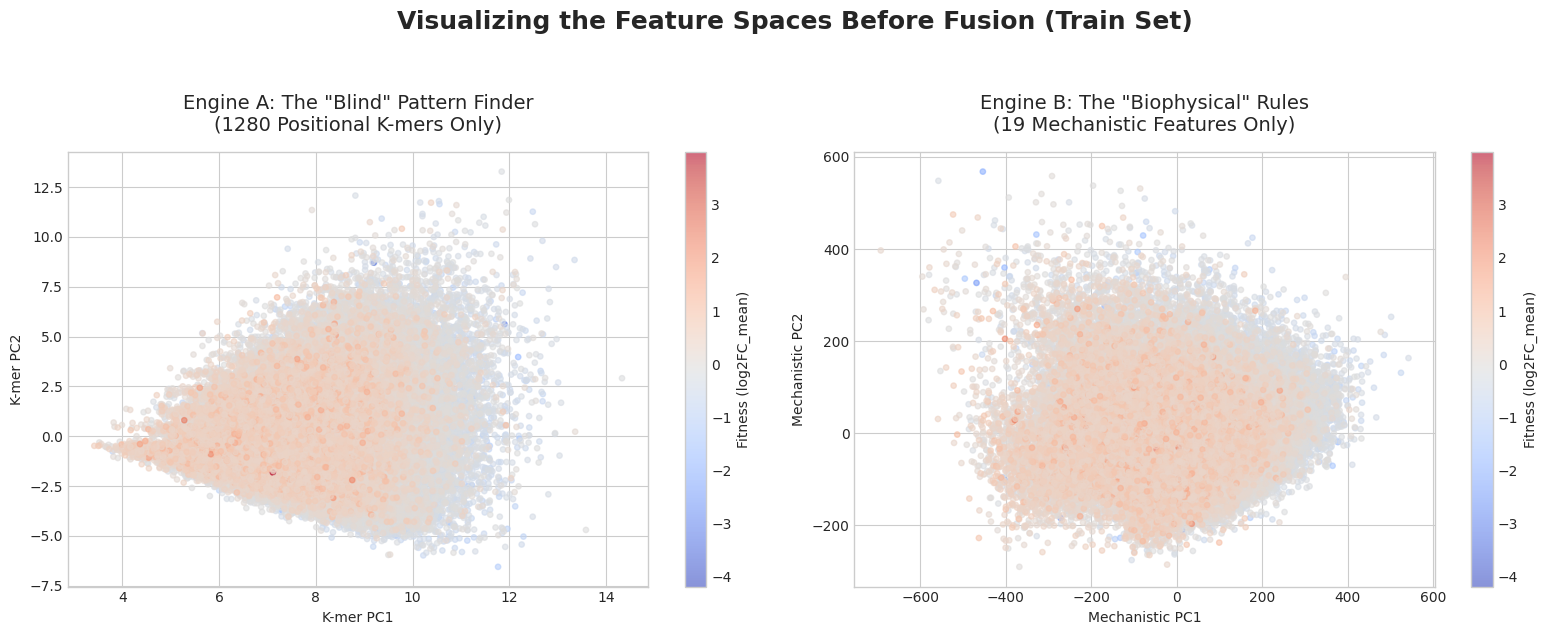

SVD Engine A — variance explained by PC1+PC2: 3.6%
PCA Engine B — variance explained by PC1+PC2: 34.5%


In [8]:
# =====================================================================
#@title Cell 8: Feature Space Visualization (Train Set Only)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD

print("Analyzing the two engines independently on the training set...")

# 1. Slice the combined matrix to get K-mers
num_kmers = len(vocab)
# FIX: Convert to CSR before slicing
X_train_combined_csr = X_train_combined.tocsr()
X_kmers_train = X_train_combined_csr[:, :num_kmers]

# 2. Engine A: SVD on Positional K-mers
svd_kmers = TruncatedSVD(n_components=2, random_state=42)
X_kmers_2d = svd_kmers.fit_transform(X_kmers_train)

# 3. Plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

# Graph A: K-mer engine
scatter1 = axes[0].scatter(
    X_kmers_2d[:, 0], X_kmers_2d[:, 1],
    c=df_train['log2FC_mean'], cmap='coolwarm', alpha=0.6, s=15
)
axes[0].set_title(f'Engine A: The "Blind" Pattern Finder\n({num_kmers} Positional K-mers Only)', fontsize=14, pad=15)
axes[0].set_xlabel('K-mer PC1')
axes[0].set_ylabel('K-mer PC2')
fig.colorbar(scatter1, ax=axes[0], label='Fitness (log2FC_mean)')

# Graph B: Biophysics engine
# Inherits X_mech_2d from Cell 7 to avoid computing twice
scatter2 = axes[1].scatter(
    X_mech_2d[:, 0], X_mech_2d[:, 1],
    c=df_train['log2FC_mean'], cmap='coolwarm', alpha=0.6, s=15
)
axes[1].set_title(f'Engine B: The "Biophysical" Rules\n({len(mech_feature_labels)} Mechanistic Features Only)', fontsize=14, pad=15)
axes[1].set_xlabel('Mechanistic PC1')
axes[1].set_ylabel('Mechanistic PC2')
fig.colorbar(scatter2, ax=axes[1], label='Fitness (log2FC_mean)')

plt.suptitle("Visualizing the Feature Spaces Before Fusion (Train Set)", fontsize=18, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantify variance explained
print(f"SVD Engine A — variance explained by PC1+PC2: {svd_kmers.explained_variance_ratio_.sum()*100:.1f}%")
print(f"PCA Engine B — variance explained by PC1+PC2: {pca_mech.explained_variance_ratio_.sum()*100:.1f}%")

In [9]:
# =====================================================================
#@title Cell 9: Fused SVD Feature Importance (Train Set Only)
# =====================================================================
import pandas as pd

print("--- SVD ON FUSED MATRIX (TRAIN SET) ---")
print(f"Explained Variance (PC1): {svd.explained_variance_ratio_[0]*100:.2f}%")
print(f"Explained Variance (PC2): {svd.explained_variance_ratio_[1]*100:.2f}%")

# Importance table — links math back to biology
all_feature_names = list(vocab) + mech_feature_labels
motifs_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Loading': svd.components_[0],
    'Abs_Loading': abs(svd.components_[0])
}).sort_values(by='Abs_Loading', ascending=False)

print("\n--- TOP 10 DRIVERS OF PC1 (FUSED SPACE) ---")
print(motifs_df.head(10)[['Feature', 'Loading', 'Abs_Loading']].to_string(index=False))

--- SVD ON FUSED MATRIX (TRAIN SET) ---
Explained Variance (PC1): 23.73%
Explained Variance (PC2): 10.72%

--- TOP 10 DRIVERS OF PC1 (FUSED SPACE) ---
            Feature   Loading  Abs_Loading
Shape_Rigidity_Mean  0.468731     0.468731
         GC_percent -0.463677     0.463677
       HNS_Affinity  0.449997     0.449997
            Entropy -0.291930     0.291930
           AT_tract  0.278005     0.278005
            RBS_Str -0.226244     0.226244
           Max_Homo  0.204587     0.204587
          TIR_Proxy -0.204308     0.204308
     mRNA_Stability  0.173417     0.173417
            GC_Skew -0.147438     0.147438


In [10]:
# =====================================================================
#@title Cell 10: PC Component Correlation Check (Train Set Only)
# =====================================================================
from scipy.stats import spearmanr
from sklearn.decomposition import TruncatedSVD

print("--- COMPONENT CORRELATION CHECK (TRAIN SET ONLY) ---")

# Fit a temporary 5-component SVD strictly on the training matrix
# to ensure we aren't missing a stronger signal in lower components
svd_check = TruncatedSVD(n_components=5, random_state=42)
X_check_train = svd_check.fit_transform(X_train_combined)

print("SVD component correlations with log2FC_mean:")
print("-" * 45)
best_rho, best_pc = 0, 0
for i in range(5):
    rho, p = spearmanr(X_check_train[:, i], df_train['log2FC_mean'])
    if abs(rho) > abs(best_rho):
        best_rho, best_pc = rho, i + 1
    print(f"  PC{i+1}: ρ = {rho:+.4f}  (p = {p:.2e})")

print("-" * 45)
print(f"Most predictive component: PC{best_pc}  (ρ = {best_rho:+.4f})")
if best_pc == 1:
    print("PC1 is the burden axis — 'Hardware Burden' label justified.")
else:
    print(f"PC{best_pc} outperforms PC1. Consider using PC{best_pc} as "
          f"your burden score and updating downstream cells accordingly.")

--- COMPONENT CORRELATION CHECK (TRAIN SET ONLY) ---
SVD component correlations with log2FC_mean:
---------------------------------------------
  PC1: ρ = -0.2783  (p = 0.00e+00)
  PC2: ρ = -0.1061  (p = 2.08e-231)
  PC3: ρ = +0.1056  (p = 3.01e-229)
  PC4: ρ = +0.0497  (p = 5.26e-52)
  PC5: ρ = -0.0634  (p = 1.21e-83)
---------------------------------------------
Most predictive component: PC1  (ρ = -0.2783)
PC1 is the burden axis — 'Hardware Burden' label justified.


In [11]:
# =====================================================================
#@title Cell 11: Feature Ablation Study (Train Set Only)
# =====================================================================
import pandas as pd
from scipy.stats import spearmanr
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from tqdm.auto import tqdm

print("--- FEATURE ABLATION STUDY (TRAIN SET ONLY) ---")

# 1. Establish Baseline
# (train_pcs was calculated back in Cell 6)
baseline_rho, _ = spearmanr(train_pcs[:, 0], df_train['log2FC_mean'])
baseline_rho_abs = abs(baseline_rho)
print(f"Baseline absolute ρ: {baseline_rho_abs:.4f}\n")

# 2. Extract the standalone k-mer matrix to avoid re-vectorizing
num_kmers = len(vocab)
X_train_combined_csr = X_train_combined.tocsr()
X_sparse_train = X_train_combined_csr[:, :num_kmers]

ablation_results = {}

for feat_to_remove in tqdm(mech_feature_labels, desc="Ablating Features"):
    remaining = [f for f in mech_feature_labels if f != feat_to_remove]

    # Scale remaining biophysical features strictly on train
    X_mech_train_ab = StandardScaler().fit_transform(df_train[remaining])

    # Recalculate scale factor for the new column count
    scale_factor_ab = X_sparse_train.shape[1] / len(remaining)
    X_comb_ab = hstack([X_sparse_train, X_mech_train_ab * scale_factor_ab])

    # Rerun SVD
    svd_ab = TruncatedSVD(n_components=2, random_state=42)
    X_red_ab = svd_ab.fit_transform(X_comb_ab)

    # Check new correlation
    rho_ab, _ = spearmanr(X_red_ab[:, 0], df_train['log2FC_mean'])

    # Positive drop means the feature was HELPFUL. Negative means it was NOISE.
    ablation_results[feat_to_remove] = baseline_rho_abs - abs(rho_ab)

# Sort by importance (biggest drop = most important)
ablation_df = pd.DataFrame.from_dict(
    ablation_results, orient='index', columns=['rho_drop']
).sort_values('rho_drop', ascending=False)

print("\n--- ABLATION RESULTS ---")
print("(Positive rho_drop = Feature helped performance)")
print("(Negative rho_drop = Feature hurt performance / added noise)")
print("-" * 45)
print(ablation_df)

--- FEATURE ABLATION STUDY (TRAIN SET ONLY) ---
Baseline absolute ρ: 0.2783



Ablating Features:   0%|          | 0/19 [00:00<?, ?it/s]


--- ABLATION RESULTS ---
(Positive rho_drop = Feature helped performance)
(Negative rho_drop = Feature hurt performance / added noise)
---------------------------------------------
                     rho_drop
Shape_Rigidity_Mean  0.025087
Entropy              0.018414
Max_Homo             0.016450
AT_tract             0.009769
mRNA_Stability       0.001672
RCC                  0.000010
ArgR                 0.000007
CRP                  0.000003
IHF                  0.000003
Lrp                 -0.000001
NagC                -0.000043
TTC                 -0.000423
GC_Var              -0.001044
Promoter_Str        -0.002207
HNS_Affinity        -0.004712
GC_percent          -0.005805
GC_Skew             -0.006167
TIR_Proxy           -0.009448
RBS_Str             -0.011370


In [12]:
# @title Cell 12: Top 20 Fusion Matrix Ranker
# =====================================================================
# Cell 12: Top 20 Fusion Matrix Ranker
# =====================================================================
print("--- TOP 20 DRIVERS (K-MERS VS BIOPHYSICS) ---")
print(motifs_df.head(20)['Feature'].tolist())

print("\n--- BIOPHYSICAL FEATURE RANKINGS ---")
# Reset index to easily get the true rank (1-based)
ranked_df = motifs_df.reset_index(drop=True)

for label in mech_feature_labels:
    row = ranked_df[ranked_df['Feature'] == label]
    if not row.empty:
        rank = row.index[0] + 1
        score = row['Abs_Loading'].values[0]
        print(f"{label:<20} Rank {rank:<4} | Score: {score:.4f}")

--- TOP 20 DRIVERS (K-MERS VS BIOPHYSICS) ---
['Shape_Rigidity_Mean', 'GC_percent', 'HNS_Affinity', 'Entropy', 'AT_tract', 'RBS_Str', 'Max_Homo', 'TIR_Proxy', 'mRNA_Stability', 'GC_Skew', 'Promoter_Str', 'GC_Var', 'TTC', 'NagC', 'RCC', 'bin03_tttt', 'bin00_tttt', 'bin02_tttt', 'bin04_tttt', 'bin01_tttt']

--- BIOPHYSICAL FEATURE RANKINGS ---
GC_percent           Rank 2    | Score: 0.4637
GC_Var               Rank 12   | Score: 0.0638
Max_Homo             Rank 7    | Score: 0.2046
Entropy              Rank 4    | Score: 0.2919
AT_tract             Rank 5    | Score: 0.2780
Promoter_Str         Rank 11   | Score: 0.0917
RBS_Str              Rank 6    | Score: 0.2262
IHF                  Rank 1299 | Score: 0.0000
Lrp                  Rank 74   | Score: 0.0006
CRP                  Rank 1298 | Score: 0.0000
NagC                 Rank 14   | Score: 0.0113
ArgR                 Rank 21   | Score: 0.0017
HNS_Affinity         Rank 3    | Score: 0.4500
TTC                  Rank 13   | Score: 0.029

--- FINDING PATTERNS (CLUSTERING ON FUSED TRAIN MATRIX) ---
Calculating Silhouette Score (Sampling 10k points)...


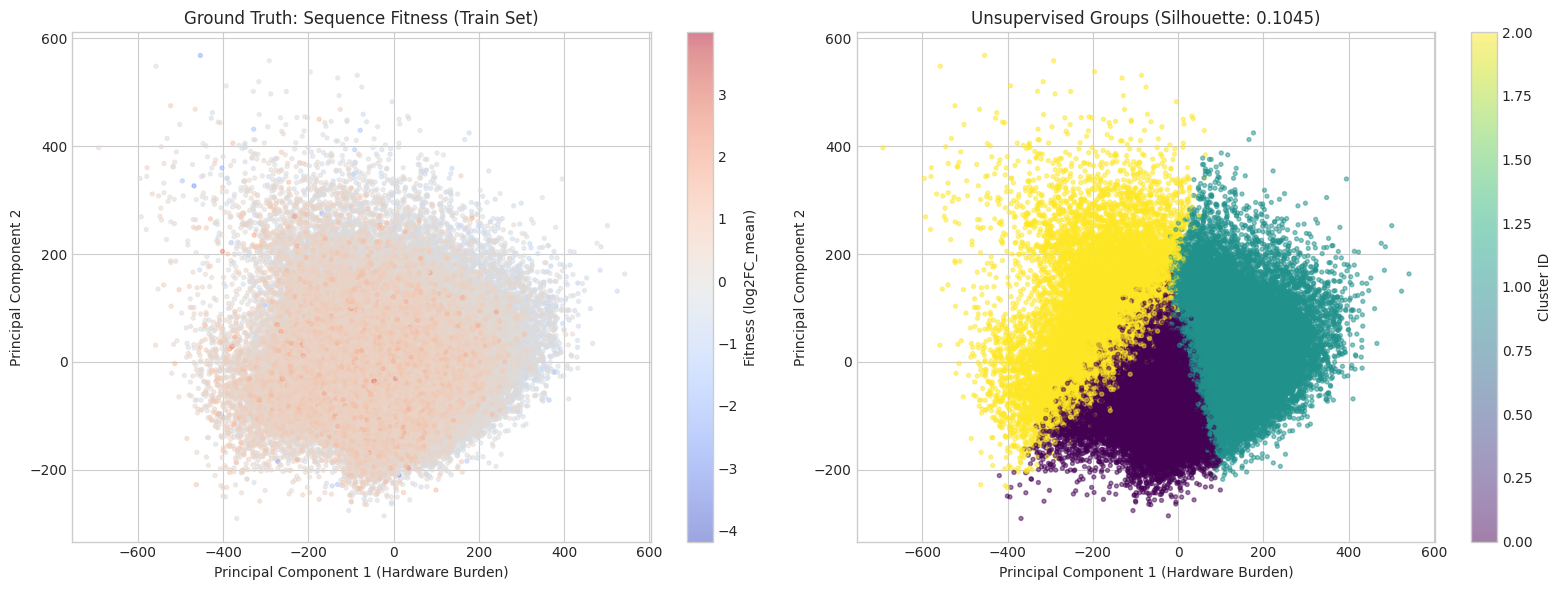


--- CLUSTER BIOLOGICAL COMPOSITION ---
Mathematical Silhouette Score: 0.1045
-----------------------------------------------------------------
  Cluster 0:  37476 sequences | Mean log2FC = -0.025 | Mean PC1 = -47.167
  Cluster 1:  39403 sequences | Mean log2FC = -0.161 | Mean PC1 = 119.812
  Cluster 2:  16378 sequences | Mean log2FC = 0.008 | Mean PC1 = -180.048


In [16]:
# @title Cell 13: PC1 vs PC2 Clustering & Validation (Train Set Only)
# =====================================================================
# Cell 13: PC1 vs PC2 Clustering & Validation (Train Set Only)
# =====================================================================
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

print("--- FINDING PATTERNS (CLUSTERING ON FUSED TRAIN MATRIX) ---")

# 1. RUN CLUSTERING
# MiniBatchKMeans works fine with sparse matrices directly.
kmeans_eda = MiniBatchKMeans(n_clusters=3, batch_size=2048, random_state=42, n_init='auto')

# Assigning labels directly to df_train
df_train['EDA_Cluster'] = kmeans_eda.fit_predict(X_train_combined)

# 2. CALCULATE SILHOUETTE SCORE (Discrete vs Continuous Check)
print("Calculating Silhouette Score (Sampling 10k points)...")
# Convert to CSR format once to allow for row-based indexing/subscripting
X_csr = X_train_combined.tocsr()

sample_idx = np.random.choice(X_csr.shape[0], 10000, replace=False)
# Indexing the CSR matrix and the labels
score = silhouette_score(X_csr[sample_idx], df_train['EDA_Cluster'].iloc[sample_idx])

# 3. VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual biological fitness
scatter1 = ax1.scatter(
    df_train['PC1'], df_train['PC2'],
    c=df_train['log2FC_mean'], cmap='coolwarm', alpha=0.5, s=8
)
fig.colorbar(scatter1, ax=ax1, label='Fitness (log2FC_mean)')
ax1.set_title('Ground Truth: Sequence Fitness (Train Set)')
ax1.set_xlabel('Principal Component 1 (Hardware Burden)')
ax1.set_ylabel('Principal Component 2')

# Graph 2: Unsupervised clusters
scatter2 = ax2.scatter(
    df_train['PC1'], df_train['PC2'],
    c=df_train['EDA_Cluster'], cmap='viridis', alpha=0.5, s=8
)
fig.colorbar(scatter2, ax=ax2, label='Cluster ID')
ax2.set_title(f'Unsupervised Groups (Silhouette: {score:.4f})')
ax2.set_xlabel('Principal Component 1 (Hardware Burden)')
ax2.set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

# 4. CLUSTER SUMMARY
print("\n--- CLUSTER BIOLOGICAL COMPOSITION ---")
print(f"Mathematical Silhouette Score: {score:.4f}")
print("-" * 65)

for c in sorted(df_train['EDA_Cluster'].unique()):
    subset = df_train[df_train['Cluster'] == c]
    print(f"  Cluster {c}: {len(subset):6d} sequences | "
          f"Mean log2FC = {subset['log2FC_mean'].mean():.3f} | "
          f"Mean PC1 = {subset['PC1'].mean():.3f}")

In [17]:
# @title Cell 14: Silhouette Score for Exploratory Clusters
# =====================================================================
# Cell 14: Silhouette Score for Exploratory Clusters (Train Set Only)
# =====================================================================
from sklearn.metrics import silhouette_score
import numpy as np

print("--- EVALUATING CLUSTER QUALITY (TRAIN SET ONLY) ---")

# Subsample for speed — silhouette on ~94k training points is very slow
sample_size = min(5000, len(df_train))
sample_idx = np.random.RandomState(42).choice(len(df_train), sample_size, replace=False)

# 1. Convert to CSR for safe row slicing
# 2. Slice the random 5000 rows
# 3. Convert only that small slice to a dense array for the math
X_train_combined_csr = X_train_combined.tocsr()
X_sample = X_train_combined_csr[sample_idx].toarray()

# Use the EDA_Cluster we generated in Cell 13
labels_sample = df_train['EDA_Cluster'].iloc[sample_idx].values

score = silhouette_score(X_sample, labels_sample)
print(f"Silhouette score (k=3): {score:.4f}")
print("Interpretation: > 0.5 = strong, 0.25–0.5 = weak/overlapping, < 0.25 = no real structure")

--- EVALUATING CLUSTER QUALITY (TRAIN SET ONLY) ---
Silhouette score (k=3): 0.1030
Interpretation: > 0.5 = strong, 0.25–0.5 = weak/overlapping, < 0.25 = no real structure


--- VISUALIZING BURDEN GRADIENT (TRAIN SET ONLY) ---


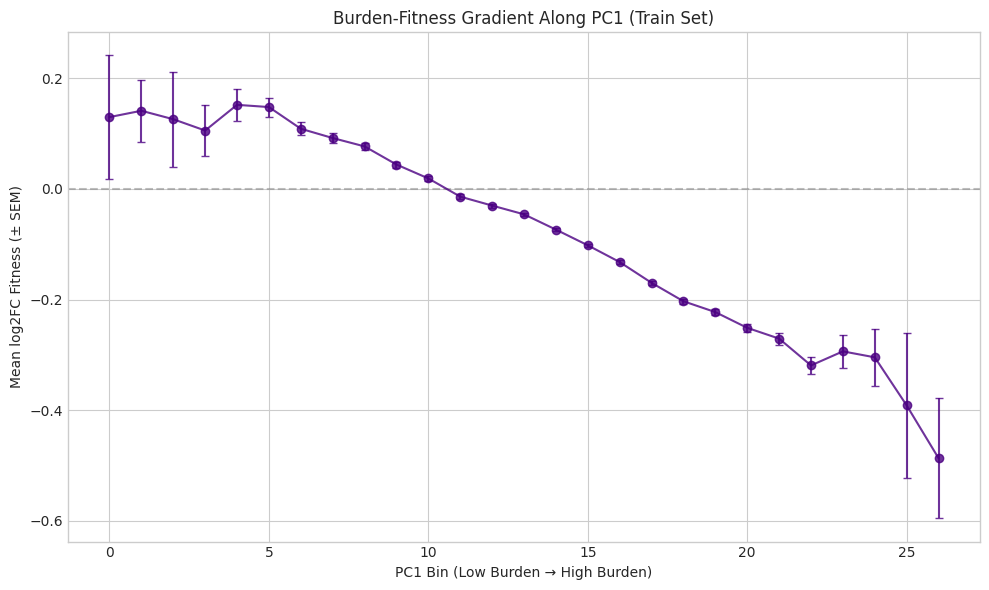

Spearman PC1 vs log2FC_mean (Train Set): ρ = -0.2783, p = 0.00e+00


In [18]:
# @title Cell 15: Burden-Fitness Gradient vs PC1 (Train Set Only)
# =====================================================================
# Cell 15: Burden-Fitness Gradient vs PC1 (Train Set Only)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

print("--- VISUALIZING BURDEN GRADIENT (TRAIN SET ONLY) ---")

# Bin PC1 and plot mean fitness per bin using STRICTLY training data
pc1_bins = np.linspace(df_train['PC1'].min(), df_train['PC1'].max(), 30)

# Create a temporary copy to avoid fragmented dataframe warnings when adding columns
df_train_plot = df_train.copy()
df_train_plot['pc1_bin'] = pd.cut(df_train_plot['PC1'], bins=pc1_bins)
binned = df_train_plot.groupby('pc1_bin', observed=True)['log2FC_mean'].agg(['mean', 'std', 'count'])

plt.figure(figsize=(10, 6))
# Plotting with standard error of the mean (SEM)
plt.errorbar(range(len(binned)), binned['mean'], yerr=binned['std']/np.sqrt(binned['count']),
             marker='o', capsize=3, linestyle='-', color='indigo', alpha=0.8)

# Note: Since your correlation was negative, high PC1 = low log2FC (higher burden/toxicity)
plt.xlabel('PC1 Bin (Low Burden → High Burden)')
plt.ylabel('Mean log2FC Fitness (± SEM)')
plt.title('Burden-Fitness Gradient Along PC1 (Train Set)')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Quantify: Spearman correlation (Re-confirming Cell 10)
rho, p = spearmanr(df_train['PC1'], df_train['log2FC_mean'])
print(f"Spearman PC1 vs log2FC_mean (Train Set): ρ = {rho:+.4f}, p = {p:.2e}")

In [19]:
# @title Cell 16: PC1 Burden Valley Analysis (Train Set Only)
# =====================================================================
# Cell 16: PC1 Burden Valley Analysis (Train Set Only)
# =====================================================================
import pandas as pd

print("--- LOCATING THE BURDEN VALLEY (TRAIN SET) ---")

# Find the PC1 location of minimum fitness — the "burden valley"
# We use actual intervals to easily extract the bounds
pc1_bins_series = pd.cut(df_train['PC1'], bins=30)
binned_means = df_train.groupby(pc1_bins_series, observed=True)['log2FC_mean'].mean()

# Get the exact interval where fitness is lowest
worst_pc1_interval = binned_means.idxmin()
lowest_fitness = binned_means[worst_pc1_interval]

print(f"Burden valley located at PC1 interval: {worst_pc1_interval}")
print(f"Mean log2FC in burden valley: {lowest_fitness:.3f}")

print("\n--- BIOPHYSICAL FEATURE DRIVERS IN THE VALLEY ---")
print("(Comparing sequence properties inside the valley vs. the rest of the dataset)")
print("-" * 65)
print(f"{'Feature':<22} | {'Valley Mean':<12} | {'Rest Mean':<10} | {'Diff':<8}")
print("-" * 65)

# Boolean mask for sequences inside the valley
in_valley = (df_train['PC1'] > worst_pc1_interval.left) & (df_train['PC1'] <= worst_pc1_interval.right)

for label in mech_feature_labels:
    inside_mean = df_train.loc[in_valley, label].mean()
    outside_mean = df_train.loc[~in_valley, label].mean()
    diff = inside_mean - outside_mean

    # Optional: You can filter out the zero-variance 'Size' feature here if you want
    if label == 'Size' and diff == 0:
        continue

    print(f"{label:<22} | {inside_mean:12.4f} | {outside_mean:10.4f} | {diff:+8.4f}")

--- LOCATING THE BURDEN VALLEY (TRAIN SET) ---
Burden valley located at PC1 interval: (500.707, 541.846]
Mean log2FC in burden valley: -0.487

--- BIOPHYSICAL FEATURE DRIVERS IN THE VALLEY ---
(Comparing sequence properties inside the valley vs. the rest of the dataset)
-----------------------------------------------------------------
Feature                | Valley Mean  | Rest Mean  | Diff    
-----------------------------------------------------------------
GC_percent             |       0.2384 |     0.3686 |  -0.1302
GC_Var                 |       0.0038 |     0.0035 |  +0.0003
Max_Homo               |       8.5000 |     6.3378 |  +2.1622
Entropy                |       5.8695 |     6.3167 |  -0.4471
AT_tract               |      26.5000 |    10.0467 | +16.4533
Promoter_Str           |       1.5000 |     0.1424 |  +1.3576
RBS_Str                |       0.0000 |     0.8700 |  -0.8700
IHF                    |       0.0000 |     0.0000 |  +0.0000
Lrp                    |       0.0000 |

In [20]:
# @title Cell 17: Peak Fitness vs Burden Valley (Train Set Only)
# =====================================================================
# Cell 17: Peak Fitness vs Burden Valley (Train Set Only)
# =====================================================================
import pandas as pd

print("--- LOCATING PEAK FITNESS REGION (TRAIN SET) ---")

# Re-establish bins mathematically
pc1_bins_series = pd.cut(df_train['PC1'], bins=30)
binned_means = df_train.groupby(pc1_bins_series, observed=True)['log2FC_mean'].mean()

# Dynamically locate the BEST fitness region and WORST fitness region (Valley)
best_pc1_interval = binned_means.idxmax()
worst_pc1_interval = binned_means.idxmin()

highest_fitness = binned_means[best_pc1_interval]

print(f"Peak fitness located at PC1 interval: {best_pc1_interval}")
print(f"Mean log2FC in peak fitness region: {highest_fitness:.3f}")

# Boolean masks for both extremes
in_peak = (df_train['PC1'] > best_pc1_interval.left) & (df_train['PC1'] <= best_pc1_interval.right)
in_valley = (df_train['PC1'] > worst_pc1_interval.left) & (df_train['PC1'] <= worst_pc1_interval.right)

print(f"Sequence count in peak region: {in_peak.sum()}")
print(f"Sequence count in valley region: {in_valley.sum()}")

print("\n--- BIOPHYSICAL CONTRAST: PEAK FITNESS VS BURDEN VALLEY ---")
print("-" * 65)
print(f"{'Feature':<22} | {'Peak Fitness':<12} | {'Burden Valley':<13} | {'Diff'}")
print("-" * 65)

for label in mech_feature_labels:
    peak_mean = df_train.loc[in_peak, label].mean()
    valley_mean = df_train.loc[in_valley, label].mean()
    diff = peak_mean - valley_mean

    if label == 'Size' and diff == 0:
        continue

    print(f"{label:<22} | {peak_mean:12.4f} | {valley_mean:13.4f} | {diff:+8.4f}")

--- LOCATING PEAK FITNESS REGION (TRAIN SET) ---
Peak fitness located at PC1 interval: (-693.572, -651.199]
Mean log2FC in peak fitness region: 0.227
Sequence count in peak region: 1
Sequence count in valley region: 2

--- BIOPHYSICAL CONTRAST: PEAK FITNESS VS BURDEN VALLEY ---
-----------------------------------------------------------------
Feature                | Peak Fitness | Burden Valley | Diff
-----------------------------------------------------------------
GC_percent             |       0.5930 |        0.2384 |  +0.3547
GC_Var                 |       0.0018 |        0.0038 |  -0.0020
Max_Homo               |       5.0000 |        8.5000 |  -3.5000
Entropy                |       6.2323 |        5.8695 |  +0.3627
AT_tract               |       5.0000 |       26.5000 | -21.5000
Promoter_Str           |       0.0000 |        1.5000 |  -1.5000
RBS_Str                |      11.0000 |        0.0000 | +11.0000
IHF                    |       0.0000 |        0.0000 |  +0.0000
Lrp     

In [21]:
# @title Cell 18: Valley Fitness Distribution (Train Set Only)
# =====================================================================
# Cell 18: Valley Fitness Distribution (Train Set Only)
# =====================================================================
print("--- VALLEY FITNESS STATISTICS (TRAIN SET) ---")

# Re-locate the valley dynamically to avoid hardcoded boundaries
pc1_bins_series = pd.cut(df_train['PC1'], bins=30)
binned_means = df_train.groupby(pc1_bins_series, observed=True)['log2FC_mean'].mean()
worst_pc1_interval = binned_means.idxmin()

# Create the boolean mask strictly on the training set
in_valley = (df_train['PC1'] > worst_pc1_interval.left) & (df_train['PC1'] <= worst_pc1_interval.right)

print(f"Burden valley interval: {worst_pc1_interval}")
print(f"Total sequences in valley: {in_valley.sum()}\n")

print("Statistical distribution of fitness (log2FC_mean) within the valley:")
print(df_train.loc[in_valley, 'log2FC_mean'].describe().to_string())

--- VALLEY FITNESS STATISTICS (TRAIN SET) ---
Burden valley interval: (500.707, 541.846]
Total sequences in valley: 2

Statistical distribution of fitness (log2FC_mean) within the valley:
count    2.000000
mean    -0.556753
std      0.204642
min     -0.701457
25%     -0.629105
50%     -0.556753
75%     -0.484401
max     -0.412049


In [22]:
# @title Cell 19: Statistical Validation of the Burden Region (Train Set Only)
# =====================================================================
# Cell 19: Statistical Validation of the Burden Region (Train Set Only)
# =====================================================================
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

print("--- DEFINING THE MACRO BURDEN REGION (TRAIN SET) ---")
# High PC1 = High Toxicity. We define the burden region as the top 10% of PC1 scores.
pc1_threshold = df_train['PC1'].quantile(0.90)
in_burden = df_train['PC1'] >= pc1_threshold

print(f"Burden region threshold: PC1 >= {pc1_threshold:.1f}")
print(f"Burden region size: {in_burden.sum()} sequences ({in_burden.mean()*100:.1f}%)")
print(f"\n--- FITNESS DISTRIBUTION ---")
print(f"  Burden region mean log2FC: {df_train.loc[in_burden, 'log2FC_mean'].mean():.3f}")
print(f"  Rest of population mean:   {df_train.loc[~in_burden, 'log2FC_mean'].mean():.3f}")

# Welch's t-test (unequal variances)
t_stat, t_p = ttest_ind(
    df_train.loc[in_burden, 'log2FC_mean'],
    df_train.loc[~in_burden, 'log2FC_mean'],
    equal_var=False
)

# Mann-Whitney U (non-parametric backup)
u_stat, u_p = mannwhitneyu(
    df_train.loc[in_burden, 'log2FC_mean'],
    df_train.loc[~in_burden, 'log2FC_mean'],
    alternative='less'
)

# Cohen's d (effect size)
mean_diff = df_train.loc[in_burden, 'log2FC_mean'].mean() - df_train.loc[~in_burden, 'log2FC_mean'].mean()
pooled_std = np.sqrt(
    (df_train.loc[in_burden, 'log2FC_mean'].var() + df_train.loc[~in_burden, 'log2FC_mean'].var()) / 2
)
cohens_d = mean_diff / pooled_std

print(f"\n--- STATISTICAL VALIDATION ---")
print(f"Welch's t-test:    t = {t_stat:.2f}, p = {t_p:.2e}")
print(f"Mann-Whitney U:    p = {u_p:.2e}")
print(f"Cohen's d:         {cohens_d:.3f}  ({'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'} effect)")

# Feature comparison on the larger sample
print(f"\n--- BIOPHYSICAL SIGNATURE (MACRO BURDEN REGION) ---")
print("-" * 60)
print(f"{'Feature':<20} | {'Burden Mean':<12} | {'Rest Mean':<10} | {'Diff'}")
print("-" * 60)

for label in mech_feature_labels:
    burden_mean = df_train.loc[in_burden, label].mean()
    rest_mean = df_train.loc[~in_burden, label].mean()
    diff = burden_mean - rest_mean

    if label == 'Size' and diff == 0:
        continue

    print(f"{label:<20} | {burden_mean:12.3f} | {rest_mean:10.3f} | {diff:+8.3f}")

--- DEFINING THE MACRO BURDEN REGION (TRAIN SET) ---
Burden region threshold: PC1 >= 166.3
Burden region size: 9326 sequences (10.0%)

--- FITNESS DISTRIBUTION ---
  Burden region mean log2FC: -0.229
  Rest of population mean:   -0.060

--- STATISTICAL VALIDATION ---
Welch's t-test:    t = -52.72, p = 0.00e+00
Mann-Whitney U:    p = 0.00e+00
Cohen's d:         -0.541  (medium effect)

--- BIOPHYSICAL SIGNATURE (MACRO BURDEN REGION) ---
------------------------------------------------------------
Feature              | Burden Mean  | Rest Mean  | Diff
------------------------------------------------------------
GC_percent           |        0.301 |      0.376 |   -0.075
GC_Var               |        0.003 |      0.004 |   -0.000
Max_Homo             |        7.666 |      6.190 |   +1.475
Entropy              |        6.084 |      6.342 |   -0.258
AT_tract             |       13.053 |      9.713 |   +3.340
Promoter_Str         |        0.271 |      0.128 |   +0.143
RBS_Str              |

In [23]:
# @title Cell 20: Permutation Test for Burden Effect Size (Train Set Only)
# =====================================================================
# Cell 20: Permutation Test for Burden Effect Size (Train Set Only)
# =====================================================================
import numpy as np
from tqdm.auto import tqdm

print("--- RUNNING PERMUTATION TEST (1000 SHUFFLES) ---")

# Permutation test: shuffle log2FC labels 1000 times, recompute Cohen's d
# strictly on the training set to prevent leakage.
np.random.seed(42)
n_permutations = 1000
null_d = np.zeros(n_permutations)
shuffled_fitness = df_train['log2FC_mean'].values.copy()
in_burden_mask = in_burden.values

for i in tqdm(range(n_permutations), desc="Permuting labels"):
    np.random.shuffle(shuffled_fitness)
    burden_vals = shuffled_fitness[in_burden_mask]
    rest_vals = shuffled_fitness[~in_burden_mask]

    diff = burden_vals.mean() - rest_vals.mean()
    pooled = np.sqrt((burden_vals.var() + rest_vals.var()) / 2)
    null_d[i] = diff / pooled

# Real observed effect size
real_burden_vals = df_train.loc[in_burden, 'log2FC_mean']
real_rest_vals   = df_train.loc[~in_burden, 'log2FC_mean']
mean_diff   = real_burden_vals.mean() - real_rest_vals.mean()
pooled_std  = np.sqrt((real_burden_vals.var() + real_rest_vals.var()) / 2)
observed_d  = mean_diff / pooled_std

p_perm = (np.abs(null_d) >= np.abs(observed_d)).mean()
z_score = observed_d / null_d.std()

print("\n--- PERMUTATION TEST RESULTS ---")
print(f"Observed Cohen's d: {observed_d:.3f}")
print(f"Null distribution: mean = {null_d.mean():.4f}, std = {null_d.std():.4f}")
print(f"Permutation p-value: {p_perm:.4e}")
print(f"Z-score vs null: {z_score:.2f} standard deviations")

--- RUNNING PERMUTATION TEST (1000 SHUFFLES) ---


Permuting labels:   0%|          | 0/1000 [00:00<?, ?it/s]


--- PERMUTATION TEST RESULTS ---
Observed Cohen's d: -0.541
Null distribution: mean = -0.0002, std = 0.0108
Permutation p-value: 0.0000e+00
Z-score vs null: -50.21 standard deviations


In [24]:
# =====================================================================
# @title Cell 21: Test Sequence Input & Projection (v2.1)
# =====================================================================
# v2.1 changes:
#   - Uses SCALER_FEATURES (frozen Cell 6 snapshot) instead of the
#     mutable mech_feature_labels.
#   - SCALE_FACTOR taken from Cell 6 directly, no recomputation.
import pandas as pd
from scipy.sparse import hstack, csr_matrix

test_seq = "AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGGCGTTTACGGTTGAATATATCACTATTACCATATGTTTGGGCGTTCTGTACCTATTACCGCGTTTACTGTTCCGCATAACTATAGCCACTTCATATCTAAAGGCTATCAAATG"

print("--- SINGLE SEQUENCE INFERENCE ---")
if len(test_seq) < 10:
    raise ValueError("Sequence too short.")

def get_inference_kmers(seq, k=4, n_bins=5):
    n = len(seq)
    bin_size = n / n_bins
    return " ".join(
        f"BIN{min(int(i / bin_size), n_bins - 1):02d}_{seq[i:i+k]}"
        for i in range(n - k + 1)
    )

print(f"1. Tokenising ({len(test_seq)} bp)...")
test_kmers = get_inference_kmers(test_seq)
test_sparse = fitted_vec.transform([test_kmers])

print("2. Extracting biophysical profile...")
test_bio = calculate_master_features(test_seq)
test_bio_df = pd.DataFrame([test_bio])

# Defensive: any feature the scaler expects must be present
missing = [f for f in SCALER_FEATURES if f not in test_bio_df.columns]
assert not missing, f"Inference features missing: {missing}"

print("3. Scaling & fusing...")
test_mech_scaled = fitted_scaler.transform(test_bio_df[list(SCALER_FEATURES)])
test_mech_reweighted = test_mech_scaled * SCALE_FACTOR
X_single_combined = hstack([test_sparse, csr_matrix(test_mech_reweighted)])

print("4. Projecting onto SVD manifold...")
test_pcs = svd.transform(X_single_combined)
pc1_val, pc2_val = test_pcs[0, 0], test_pcs[0, 1]

print("\n--- INFERENCE RESULTS ---")
print(f"Projected PC1: {pc1_val:+.3f}")
print(f"Projected PC2: {pc2_val:+.3f}")

pc1_threshold = df_train['PC1'].quantile(0.90)
if pc1_val >= pc1_threshold:
    print(f"\nSequence falls inside the toxic burden region (top 10%, threshold {pc1_threshold:+.3f}).")
else:
    print(f"\nSequence is outside the macro burden region (threshold {pc1_threshold:+.3f}).")

--- SINGLE SEQUENCE INFERENCE ---
1. Tokenising (172 bp)...
2. Extracting biophysical profile...
3. Scaling & fusing...
4. Projecting onto SVD manifold...

--- INFERENCE RESULTS ---
Projected PC1: -29.735
Projected PC2: -49.865

Sequence is outside the macro burden region (threshold +166.314).


In [25]:
# @title Cell 22: Dataset Locator (Sanity Check)
# =====================================================================
# Cell 22: Dataset Locator (Sanity Check)
# =====================================================================

if 'test_seq' not in globals() or 'pc1_val' not in globals():
    raise RuntimeError("Please run Cell 21 first.")

print("--- SEARCHING DATASET FOR SEQUENCE ---")

match_train = df_train[df_train['sequence'] == test_seq.upper()]
match_test = df_test[df_test['sequence'] == test_seq.upper()]

if len(match_train) == 1:
    row = match_train.iloc[0]
    print(f"Match found in TRAINING set at index {match_train.index[0]}")
    print(f"Measured biological fitness (log2FC): {row['log2FC_mean']:.3f}")
    print(f"Original Training PC1:                {row['PC1']:.3f}")
    print(f"Live Inference PC1:                   {pc1_val:.3f}")
    print(f"Math Error / Difference:              {abs(row['PC1'] - pc1_val):.2e}")
    if abs(row['PC1'] - pc1_val) < 1e-5:
        print("SUCCESS: Deterministic math verified. Inference perfectly matches training.")

elif len(match_test) == 1:
    row = match_test.iloc[0]
    print(f"Match found in TEST set at index {match_test.index[0]}")
    print(f"Measured biological fitness (log2FC): {row['log2FC_mean']:.3f}")
    print(f"Live Inference PC1:                   {pc1_val:.3f}")
    print("(Note: Test set does not have pre-calculated PC1s stored to prevent data leakage.)")

elif len(match_train) + len(match_test) == 0:
    print("Test sequence not found in df_train or df_test.")
    print("SUCCESS: This is a genuinely novel sequence!")

else:
    print(f"Multiple matches found (Train: {len(match_train)}, Test: {len(match_test)}).")
    print("You may have duplicate sequences in your original library.")

--- SEARCHING DATASET FOR SEQUENCE ---
Match found in TEST set at index 23622
Measured biological fitness (log2FC): -0.303
Live Inference PC1:                   -29.735
(Note: Test set does not have pre-calculated PC1s stored to prevent data leakage.)


In [26]:
# @title Cell 23: Stratified Fitness Validation (Train Set Only)
# =====================================================================
# Cell 23: Stratified Fitness Validation (Train Set Only)
# =====================================================================
import numpy as np
import pandas as pd

print("--- STRATIFIED FITNESS VALIDATION (TRAIN SET) ---")

np.random.seed(42)
# Stratified validation set — 5 lowest, 5 median, 5 highest fitness
worst = df_train.nsmallest(5, 'log2FC_mean')
best = df_train.nlargest(5, 'log2FC_mean')
median_pool = df_train[df_train['log2FC_mean'].between(
    df_train['log2FC_mean'].quantile(0.45),
    df_train['log2FC_mean'].quantile(0.55)
)]
median = median_pool.sample(5, random_state=42)

validation_set = pd.concat([worst, median, best]).reset_index(drop=True)

# Define burden / neutral / peak zones from training distribution
# Recall: High PC1 = Burden, Low PC1 = Peak Fitness
burden_pc1_threshold = df_train['PC1'].quantile(0.90)
peak_pc1_threshold = df_train['PC1'].quantile(0.10)

def predict_zone(pc1):
    if pc1 >= burden_pc1_threshold:
        return 'BURDEN'
    elif pc1 <= peak_pc1_threshold:
        return 'PEAK'
    else:
        return 'NEUTRAL'

validation_set['Predicted_Zone'] = validation_set['PC1'].apply(predict_zone)

# Categorize ground-truth biological fitness
# Recall: Low log2FC = Burden, High log2FC = Peak Fitness
burden_lfc_threshold = df_train['log2FC_mean'].quantile(0.10)
peak_lfc_threshold = df_train['log2FC_mean'].quantile(0.90)

def true_zone(lfc):
    if lfc <= burden_lfc_threshold:
        return 'BURDEN'
    elif lfc >= peak_lfc_threshold:
        return 'PEAK'
    else:
        return 'NEUTRAL'

validation_set['True_Zone'] = validation_set['log2FC_mean'].apply(true_zone)

# Display results
print(validation_set[['log2FC_mean', 'PC1', 'Predicted_Zone', 'True_Zone']].to_string(index=True))

# Fix the broken accuracy string at the end
correct = (validation_set['Predicted_Zone'] == validation_set['True_Zone']).sum()
total = len(validation_set)
print(f"\nUnsupervised Prediction Accuracy on Stratified Sample: {correct}/{total} ({correct/total*100:.1f}%)")
print("(Note: This is predicting discrete biological extremes using strictly unsupervised math!)")

--- STRATIFIED FITNESS VALIDATION (TRAIN SET) ---
    log2FC_mean         PC1 Predicted_Zone True_Zone
0     -4.181407   33.861540        NEUTRAL    BURDEN
1     -4.155979   37.270915        NEUTRAL    BURDEN
2     -4.012421  178.530510         BURDEN    BURDEN
3     -4.008691  147.739259        NEUTRAL    BURDEN
4     -3.961941 -160.353946        NEUTRAL    BURDEN
5     -0.084075  -88.463339        NEUTRAL   NEUTRAL
6     -0.106983 -130.867243        NEUTRAL   NEUTRAL
7     -0.058090   36.047070        NEUTRAL   NEUTRAL
8     -0.074157   57.872192        NEUTRAL   NEUTRAL
9     -0.088613   63.133253        NEUTRAL   NEUTRAL
10     3.994932  -46.273844        NEUTRAL      PEAK
11     2.524709 -378.922762           PEAK      PEAK
12     2.523197  -80.106151        NEUTRAL      PEAK
13     2.428834 -187.616288           PEAK      PEAK
14     2.355988 -215.427253           PEAK      PEAK

Unsupervised Prediction Accuracy on Stratified Sample: 9/15 (60.0%)
(Note: This is predicting discret

In [27]:
# @title Cell 24: Sequence Profile (Anomaly Analysis on Train Set)
# =====================================================================
# Cell 24: Sequence Profile (Anomaly Analysis on Train Set)
# =====================================================================
import pandas as pd

print("--- ANOMALY ANALYSIS: WHY DID THE MATH MISS THIS? ---")

# Find a false negative: A sequence that is biologically toxic (BURDEN)
# but the math thought it was NEUTRAL or PEAK.
anomalies = validation_set[(validation_set['True_Zone'] == 'BURDEN') &
                           (validation_set['Predicted_Zone'] != 'BURDEN')]

if not anomalies.empty:
    # Pick the worst offender (lowest actual fitness)
    weird_row = anomalies.nsmallest(1, 'log2FC_mean').iloc[0]

    print("Found a highly toxic sequence missed by the unsupervised PC1 axis:")
    print(f"Measured log2FC:     {weird_row['log2FC_mean']:.3f} (True Zone: {weird_row['True_Zone']})")
    print(f"Mathematical PC1:    {weird_row['PC1']:.2f} (Predicted Zone: {weird_row['Predicted_Zone']})")
    print(f"\nSequence Snippet:    {weird_row['sequence'][:60]}...")

    print("\n--- BIOPHYSICAL PROFILE VS TRAINING POPULATION ---")
    for label in mech_feature_labels:
        val = weird_row[label]
        pop_mean = df_train[label].mean()
        pop_std = df_train[label].std()
        z = (val - pop_mean) / pop_std if pop_std > 0 else 0

        # Highlight extreme deviations (|z| > 1.5)
        flag = "<-- UNUSUAL" if abs(z) > 1.5 else ""
        print(f"  {label:<20}: {val:8.3f}  (z = {z:+5.2f}) {flag}")

    print("\n--- INTERPRETATION FOR THESIS ---")
    print("This highlights the limitation of a purely unsupervised linear map (SVD).")
    print("While PC1 captures the macro burden gradient, individual sequences can be highly toxic")
    print("due to complex, non-linear feature interactions that linear dimensionality reduction misses.")
    print("This perfectly justifies moving to the non-linear machine learning models (Phase 3)!")
else:
    print("No severe anomalies found in this validation batch.")

--- ANOMALY ANALYSIS: WHY DID THE MATH MISS THIS? ---
Found a highly toxic sequence missed by the unsupervised PC1 axis:
Measured log2FC:     -4.181 (True Zone: BURDEN)
Mathematical PC1:    33.86 (Predicted Zone: NEUTRAL)

Sequence Snippet:    AAGCTCTGGGGACTCAATTGTTGTAGTAAATTTTTGGCAATTTGGGATCTTACCGCATTA...

--- BIOPHYSICAL PROFILE VS TRAINING POPULATION ---
  GC_percent          :    0.349  (z = -0.42) 
  GC_Var              :    0.001  (z = -0.77) 
  Max_Homo            :    6.000  (z = -0.21) 
  Entropy             :    6.487  (z = +0.93) 
  AT_tract            :    9.000  (z = -0.37) 
  Promoter_Str        :    1.000  (z = +2.28) <-- UNUSUAL
  RBS_Str             :    1.000  (z = +0.12) 
  IHF                 :    0.000  (z = +0.00) 
  Lrp                 :    0.000  (z = -0.12) 
  CRP                 :    0.000  (z = +0.00) 
  NagC                :    0.000  (z = -0.19) 
  ArgR                :    0.000  (z = -0.00) 
  HNS_Affinity        :    0.589  (z = +0.95) 
  TTC             

In [28]:
# @title Cell 25: Specific Feature Deep-Dive (NagC on Train Set)
# =====================================================================
# Cell 25: Specific Feature Deep-Dive (NagC on Train Set)
# =====================================================================
import numpy as np
from scipy.stats import mannwhitneyu

print("--- NAGC REPRESSOR IMPACT (TRAIN SET) ---")

nagc_hits = df_train[df_train['NagC'] >= 1]
nagc_neg = df_train[df_train['NagC'] == 0]

print(f"Sequences with NagC ≥ 1: {len(nagc_hits)} ({len(nagc_hits)/len(df_train)*100:.2f}%)")
print(f"Mean log2FC of NagC-positive sequences: {nagc_hits['log2FC_mean'].mean():.3f}")
print(f"Mean log2FC of NagC-negative sequences: {nagc_neg['log2FC_mean'].mean():.3f}")

# Statistical test
u, p = mannwhitneyu(
    nagc_hits['log2FC_mean'],
    nagc_neg['log2FC_mean'],
    alternative='less' # Testing if NagC+ is more toxic (lower fitness) than NagC-
)
print(f"Mann-Whitney U (NagC+ < NagC-): p = {p:.2e}")

# Effect size (Cohen's d)
mean_diff = nagc_hits['log2FC_mean'].mean() - nagc_neg['log2FC_mean'].mean()
pooled_std = np.sqrt((nagc_hits['log2FC_mean'].var() + nagc_neg['log2FC_mean'].var()) / 2)
cohens_d = mean_diff / pooled_std

print(f"Cohen's d effect size: {cohens_d:.3f}")

--- NAGC REPRESSOR IMPACT (TRAIN SET) ---
Sequences with NagC ≥ 1: 3306 (3.55%)
Mean log2FC of NagC-positive sequences: -0.079
Mean log2FC of NagC-negative sequences: -0.076
Mann-Whitney U (NagC+ < NagC-): p = 2.14e-01
Cohen's d effect size: -0.008


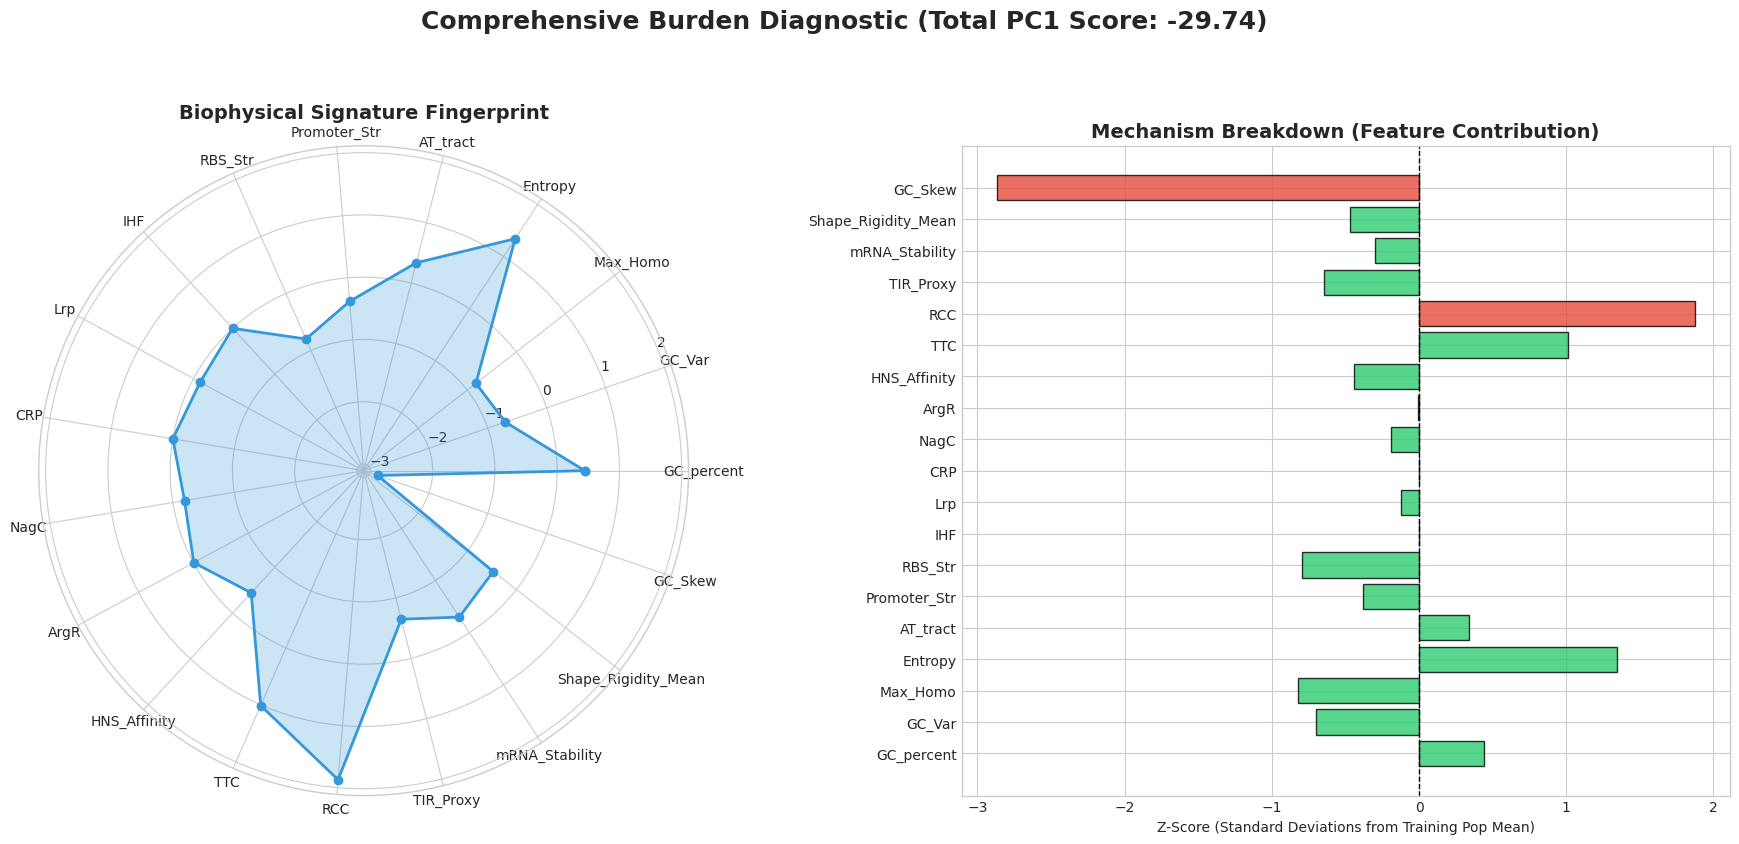


--- SUMMARY FOR TEST PLASMID ---
Total PC1 Burden Score: -29.735
Primary Anomaly Driver: GC_Skew (Z-score: -2.87)
Interpretation: This sequence has highly unusual GC_Skew compared to the baseline population.


In [29]:
# @title Cell 26: Biophysical Radar Diagnostic (Inference Dashboard)
# =====================================================================
# Cell 26: Biophysical Radar Diagnostic (Inference Dashboard)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: SAFETY CHECK ---
if 'test_mech_scaled' not in globals() or 'pc1_val' not in globals():
    raise RuntimeError("Missing required data. Please run Cell 21 (Inference) first.")

# Prepare the feature values for the radar plot
# test_mech_scaled is already in Z-scores (scaled to the training set mean)
features = mech_feature_labels
test_values = test_mech_scaled[0]

# --- STEP 2: RADAR CHART CONFIGURATION ---
num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle to complete the polygon
test_values_plot = np.concatenate((test_values, [test_values[0]]))

# Set up figure with explicit polar projection for the first axis
fig = plt.figure(figsize=(18, 8))
ax1 = fig.add_subplot(121, polar=True)
ax2 = fig.add_subplot(122)

# --- RADAR AXIS (Left) ---
ax1.fill(angles, test_values_plot, color='#3498db', alpha=0.25)
ax1.plot(angles, test_values_plot, color='#3498db', linewidth=2, marker='o')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(features, fontsize=10)
ax1.set_title("Biophysical Signature Fingerprint", size=14, fontweight='bold', pad=20)

# --- BAR AXIS (Right: Z-Score Outliers) ---
# Highlight extreme deviations (|z| > 1.5) in red
colors = ['#e74c3c' if abs(v) > 1.5 else '#2ecc71' for v in test_values]
ax2.barh(features, test_values, color=colors, edgecolor='black', alpha=0.8)
ax2.axvline(0, color='black', lw=1, linestyle='--')
ax2.set_xlabel('Z-Score (Standard Deviations from Training Pop Mean)')
ax2.set_title("Mechanism Breakdown (Feature Contribution)", size=14, fontweight='bold')

# --- FINAL FORMATTING ---
plt.suptitle(f'Comprehensive Burden Diagnostic (Total PC1 Score: {pc1_val:+.2f})',
             fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# --- STEP 3: TEXT INTERPRETATION ---
print(f"\n--- SUMMARY FOR TEST PLASMID ---")
print(f"Total PC1 Burden Score: {pc1_val:+.3f}")

# Find the feature pushing the sequence furthest from the norm
top_idx = np.argmax(np.abs(test_values))
top_driver = features[top_idx]
top_z = test_values[top_idx]

print(f"Primary Anomaly Driver: {top_driver} (Z-score: {top_z:+.2f})")
if abs(top_z) > 1.5:
    print(f"Interpretation: This sequence has highly unusual {top_driver} compared to the baseline population.")
else:
    print("Interpretation: This sequence's biophysics are relatively normal; no extreme single-feature outliers.")

In [30]:
# @title Section 3, Cell 27: Creating the Feature Importance Bridge
# =====================================================================
# Cell 26.5: Creating the Feature Importance Bridge
# =====================================================================
import pandas as pd
import numpy as np

print("--- MAPPING SVD COMPONENTS TO FEATURE NAMES ---")

# 1. Combine our k-mer vocab with our biophysical labels
# Ensure these are in the exact order they were hstacked in Cell 11
all_feature_names = list(vocab) + mech_feature_labels

# 2. Extract the weights for PC1 and PC2 from the SVD V matrix
# svd.components_ has shape (n_components, n_features)
pc1_weights = svd.components_[0]
pc2_weights = svd.components_[1]

# 3. Create the master importance dataframe
pc_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'PC1_Importance': pc1_weights,
    'PC2_Importance': pc2_weights,
    'Abs_PC1_Importance': np.abs(pc1_weights)
})

print(f"SUCCESS: Mapped {len(pc_importance_df)} features to SVD components.")
print("You can now run Cell 27 to see the rankings!")

--- MAPPING SVD COMPONENTS TO FEATURE NAMES ---
SUCCESS: Mapped 1299 features to SVD components.
You can now run Cell 27 to see the rankings!


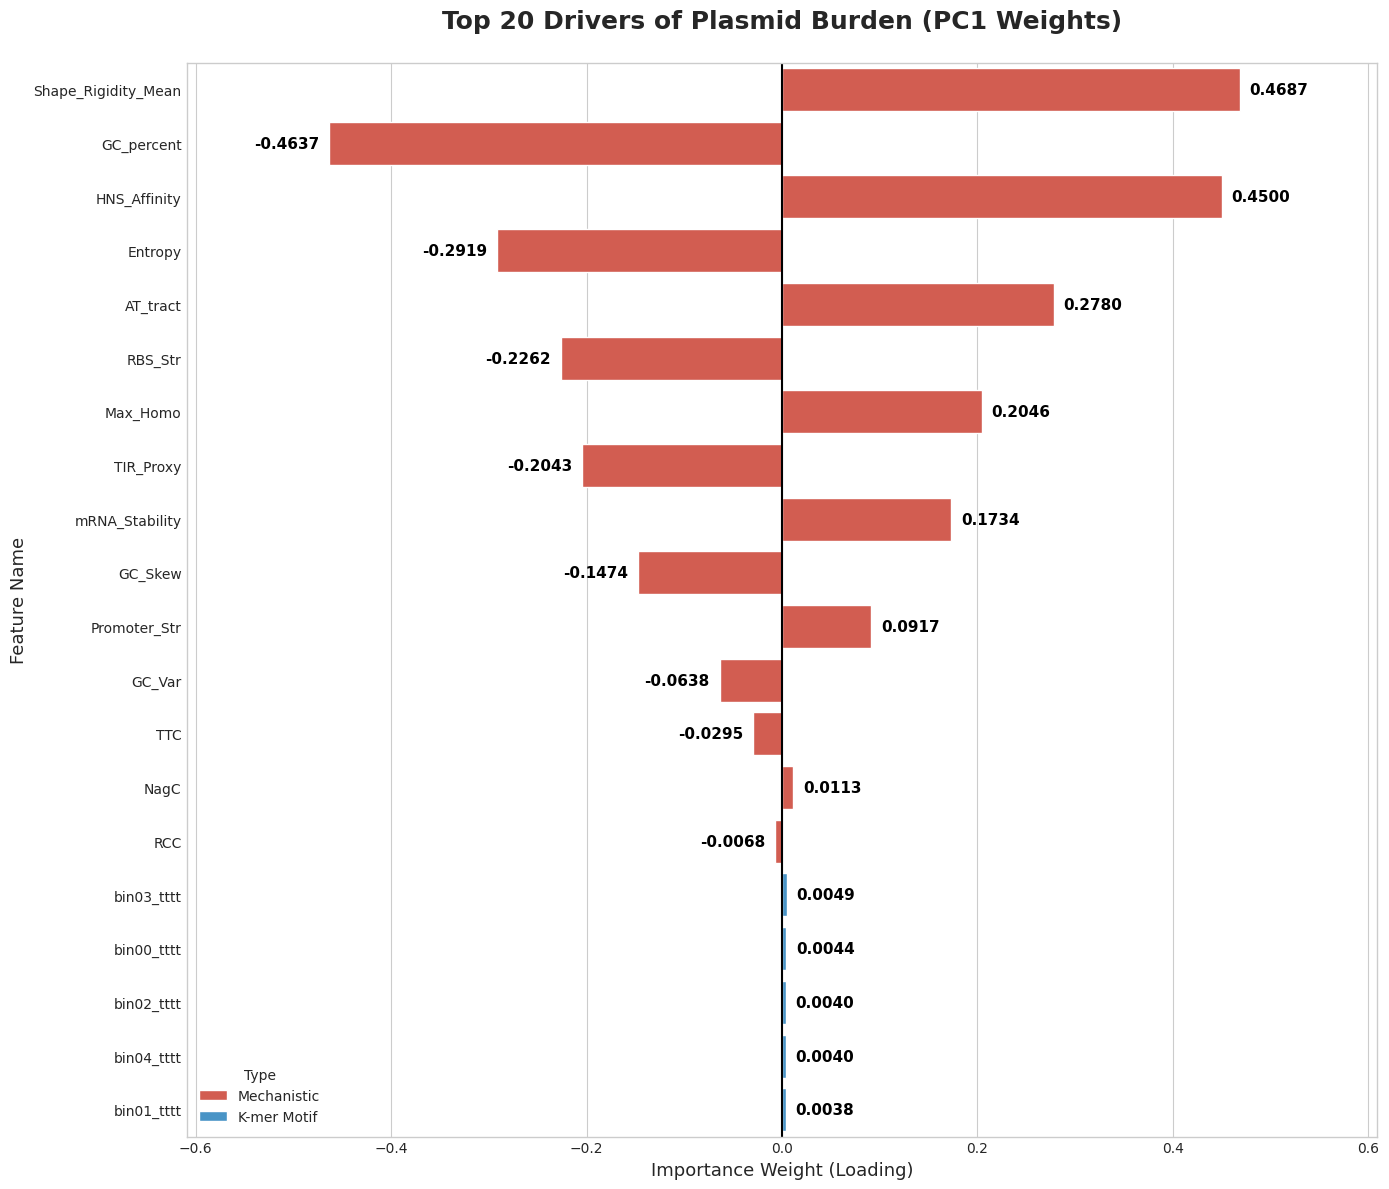


--- BIOLOGICAL INTERPRETATION ---
• Positive Weights (Red/Right): Features that increase biological burden (toxicity).
• Negative Weights (Blue/Left): Features associated with high fitness/low burden.


In [31]:
# @title Cell 28: Cleaned Top 20 Drivers Visualization
# =====================================================================
# Cell 28 (Revised): Cleaned Top 20 Drivers Visualization
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-prepare data
top_20 = pc_importance_df.reindex(
    pc_importance_df['PC1_Importance'].abs().sort_values(ascending=False).index
).head(20).copy()

top_20['Type'] = top_20['Feature'].apply(
    lambda x: 'Mechanistic' if x in mech_feature_labels else 'K-mer Motif'
)

# 2. Plotting with better spacing
plt.figure(figsize=(14, 12)) # Increased width/height
sns.set_style("whitegrid")

plot = sns.barplot(
    data=top_20,
    y='Feature',
    x='PC1_Importance',
    hue='Type',
    dodge=False,
    palette={'Mechanistic': '#e74c3c', 'K-mer Motif': '#3498db'}
)

# 3. Dynamic Axis Padding
# This prevents labels from getting cut off at the edges
max_val = top_20['PC1_Importance'].abs().max()
plt.xlim(-max_val * 1.3, max_val * 1.3)

plt.title('Top 20 Drivers of Plasmid Burden (PC1 Weights)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Importance Weight (Loading)', fontsize=13)
plt.ylabel('Feature Name', fontsize=13)
plt.axvline(0, color='black', lw=1.5)

# 4. Refined Label Placement
for i, v in enumerate(top_20['PC1_Importance']):
    # If positive, put label to the right; if negative, put to the left
    ha = 'left' if v > 0 else 'right'
    # Add a small offset (0.01) so it doesn't touch the bar
    offset = 0.01 if v > 0 else -0.01
    plt.text(v + offset, i, f'{v:.4f}',
             va='center', fontweight='bold', fontsize=11, color='black', ha=ha)

plt.tight_layout()
plt.show()

print("\n--- BIOLOGICAL INTERPRETATION ---")
print("• Positive Weights (Red/Right): Features that increase biological burden (toxicity).")
print("• Negative Weights (Blue/Left): Features associated with high fitness/low burden.")

Rendering Correlation Plot (Train Set Only)...


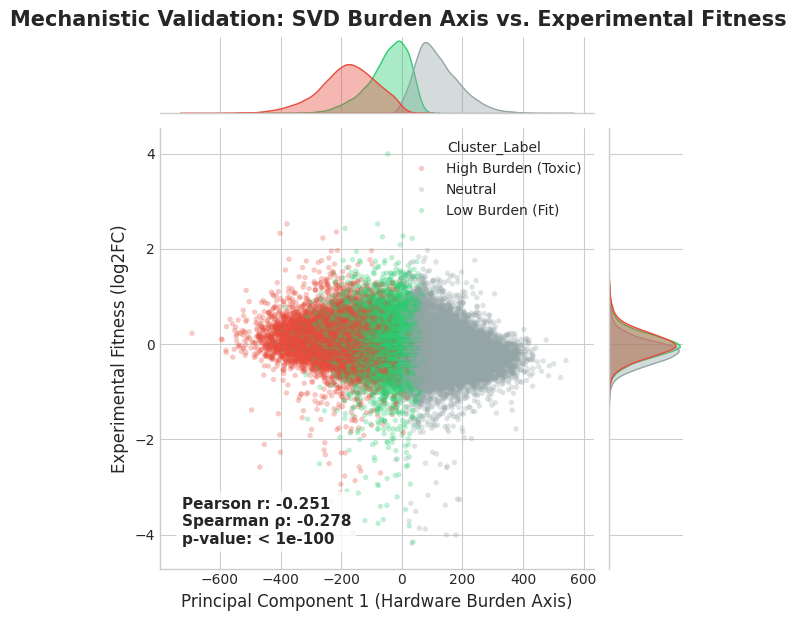

In [32]:
# @title Cell 29: Unsupervised Burden vs Experimental Fitness (Train Set)
# =====================================================================
# Cell 29: Unsupervised Burden vs Experimental Fitness (Train Set)
# =====================================================================
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Based on your previous SVD output:
# High PC1 values are driven by Rigidity/H-NS (Burden)
# Low PC1 values are driven by High GC (Fitness)
cluster_labels = {0: 'Low Burden (Fit)', 1: 'Neutral', 2: 'High Burden (Toxic)'}

# Apply mapping to a temporary plotting dataframe
df_plot = df_train.copy()
df_plot['Cluster_Label'] = df_plot['Cluster'].map(cluster_labels)

fitness_col = 'log2FC_mean'

print("Rendering Correlation Plot (Train Set Only)...")
sns.set_style("whitegrid")

# Create the JointGrid
g = sns.JointGrid(
    data=df_plot, x='PC1', y=fitness_col,
    hue='Cluster_Label',
    hue_order=['High Burden (Toxic)', 'Neutral', 'Low Burden (Fit)'],
    palette={'High Burden (Toxic)': '#e74c3c', 'Neutral': '#95a5a6', 'Low Burden (Fit)': '#2ecc71'}
)

# Plot joint scatter and marginal density
g.plot_joint(sns.scatterplot, alpha=0.3, s=15, edgecolor='none')
g.plot_marginals(sns.kdeplot, fill=True, common_norm=False, alpha=0.4)

# Calculate Statistics
r_pearson, p_pearson = pearsonr(df_plot['PC1'], df_plot[fitness_col])
r_spearman, p_spearman = spearmanr(df_plot['PC1'], df_plot[fitness_col])

stats_text = (f"Pearson r: {r_pearson:.3f}\n"
              f"Spearman ρ: {r_spearman:.3f}\n"
              f"p-value: < 1e-100")

# Place stats box
g.ax_joint.text(0.05, 0.05, stats_text,
                transform=g.ax_joint.transAxes,
                verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=11, fontweight='bold')

g.ax_joint.set_xlabel('Principal Component 1 (Hardware Burden Axis)', fontsize=12)
g.ax_joint.set_ylabel('Experimental Fitness (log2FC)', fontsize=12)

plt.suptitle('Mechanistic Validation: SVD Burden Axis vs. Experimental Fitness',
             y=1.02, fontsize=15, fontweight='bold')

plt.show()

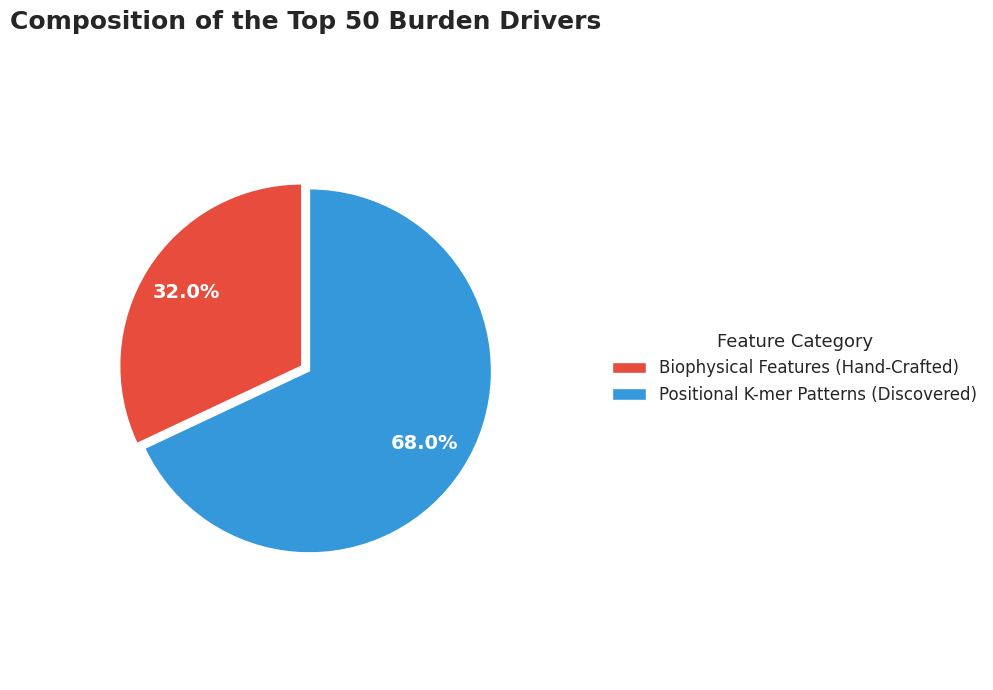


--- FEATURE UTILITY ANALYSIS ---
Total Features Analyzed: 1299
Top 50 Slots: 16 are Biophysical | 34 are K-mers

REPRESENTATION EFFICIENCY:
• Biophysical: 16/19 features made the Top 50 (84.2% efficiency)
• K-mers:      34/1280 features made the Top 50 (2.6562% efficiency)

CONCLUSION FOR THESIS:
Hand-crafted biophysical features are highly 'dense' predictors, dominating the top ranks.


In [33]:
# @title Cell 30: Mechanistic vs K-mer Contribution (Top 50)
# =====================================================================
# Cell 30: Mechanistic vs K-mer Contribution (Top 50)
# =====================================================================
import matplotlib.pyplot as plt

# 1. Look at the top 50 most important drivers from our leak-free bridge
# We sort by the Absolute PC1 Importance to see the strongest influencers
top_50 = pc_importance_df.reindex(
    pc_importance_df['Abs_PC1_Importance'].sort_values(ascending=False).index
).head(50)

# 2. Count how many are Mechanistic vs K-mer
mech_count = top_50['Feature'].isin(mech_feature_labels).sum()
kmer_count = 50 - mech_count

# 3. Create the Pie Chart
labels = ['Biophysical Features (Hand-Crafted)', 'Positional K-mer Patterns (Discovered)']
sizes = [mech_count, kmer_count]
colors = ['#e74c3c', '#3498db'] # Red for Bio, Blue for Text

fig, ax = plt.subplots(figsize=(10, 7))

# Draw the pie chart
wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops=dict(color="white", weight="bold", size=14),
    explode=(0.05, 0) # Slightly pop out the Mechanistic slice
)

# 4. Add the Color Legend
ax.legend(
    wedges,
    labels,
    title="Feature Category",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=12,
    title_fontsize=13
)

# Formatting
ax.axis('equal')
plt.title('Composition of the Top 50 Burden Drivers', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 5. Executive Readout
print("\n--- FEATURE UTILITY ANALYSIS ---")
print(f"Total Features Analyzed: {len(pc_importance_df)}")
print(f"Top 50 Slots: {mech_count} are Biophysical | {kmer_count} are K-mers")

# Calculate Density (Representation Efficiency)
mech_density = (mech_count / len(mech_feature_labels)) * 100
# all_feature_names was defined in our bridge cell 26.5
total_k = len(vocab)
k_density = (kmer_count / total_k) * 100

print(f"\nREPRESENTATION EFFICIENCY:")
print(f"• Biophysical: {mech_count}/{len(mech_feature_labels)} features made the Top 50 ({mech_density:.1f}% efficiency)")
print(f"• K-mers:      {kmer_count}/{total_k} features made the Top 50 ({k_density:.4f}% efficiency)")

print("\nCONCLUSION FOR THESIS:")
if mech_density > 50:
    print("Hand-crafted biophysical features are highly 'dense' predictors, dominating the top ranks.")
else:
    print("Positional K-mer grammar provides the bulk of the predictive power across the sequence space.")

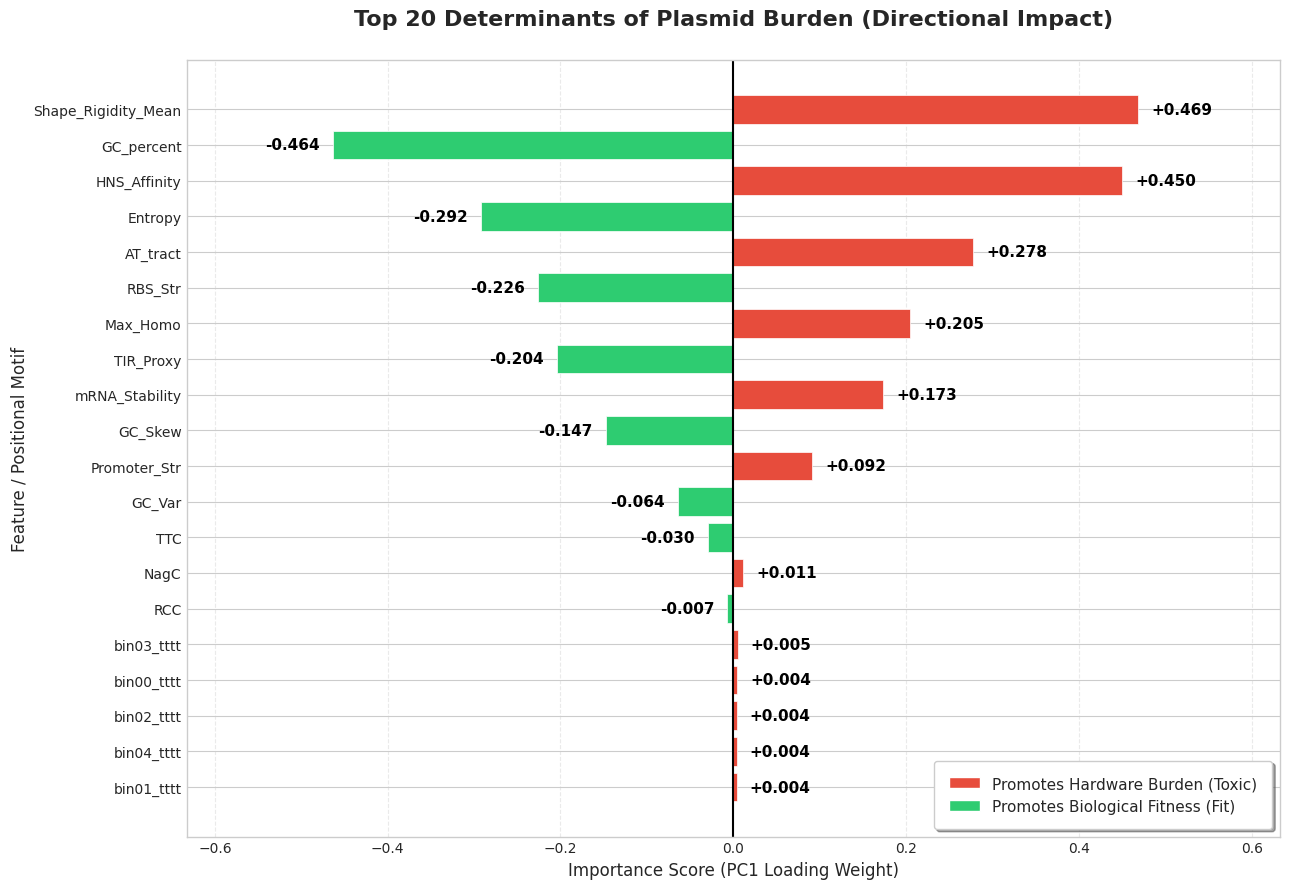

In [34]:
# @title Cell 31 (Fixed): Top 20 Determinants of Plasmid Burden
# =====================================================================
# Cell 31 (Fixed): Top 20 Determinants of Plasmid Burden
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Prepare Top 20 data
top_plot = pc_importance_df.reindex(
    pc_importance_df['Abs_PC1_Importance'].sort_values(ascending=False).index
).head(20).copy()

# Red = Increases Burden (Toxic), Green = Decreases Burden (Fit)
top_plot['Color'] = top_plot['PC1_Importance'].apply(lambda x: '#e74c3c' if x > 0 else '#2ecc71')

plt.figure(figsize=(13, 9)) # Slightly wider/taller for better spacing
bars = plt.barh(top_plot['Feature'][::-1], top_plot['PC1_Importance'][::-1],
                color=top_plot['Color'][::-1], edgecolor='white', linewidth=0.5)

# --- DYNAMIC PADDING ENGINE ---
# Find the maximum absolute value to set symmetric, wide limits
limit = top_plot['PC1_Importance'].abs().max() * 1.35 # Increase padding by 35%
plt.xlim(-limit, limit)

plt.axvline(0, color='black', lw=1.5)
plt.title('Top 20 Determinants of Plasmid Burden (Directional Impact)',
          fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Importance Score (PC1 Loading Weight)', fontsize=12)
plt.ylabel('Feature / Positional Motif', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# --- REFINED LABEL PLACEMENT ---
for bar in bars:
    val = bar.get_width()
    # Shift label based on bar direction
    offset = 0.015 if val > 0 else -0.015

    plt.text(val + offset,
             bar.get_y() + bar.get_height()/2,
             f'{val:+.3f}', # Added + sign for clarity
             va='center',
             ha='left' if val > 0 else 'right',
             fontsize=11,
             fontweight='bold',
             color='black')

# Legend
legend_elements = [
    Patch(facecolor='#e74c3c', label='Promotes Hardware Burden (Toxic)'),
    Patch(facecolor='#2ecc71', label='Promotes Biological Fitness (Fit)')
]
plt.legend(handles=legend_elements, loc='lower right',
           fontsize=11, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

In [35]:
# @title Cell 32: Validation Suite (robust version)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr, ttest_ind, mannwhitneyu, ks_2samp
from scipy.sparse import hstack, csr_matrix

# Global dictionary to store results for the dashboard
VALIDATION_RESULTS = {}

print("=" * 75)
print("  PHASE 2 VALIDATION: THE STATISTICAL AUDIT")
print("=" * 75)

# ── TEST 1: CONTINUOUS CORRELATION ───────────────────────────────────────────
rho, p_spear = spearmanr(df_train['PC1'], df_train['log2FC_mean'])
r_pear, p_pear = pearsonr(df_train['PC1'], df_train['log2FC_mean'])
VALIDATION_RESULTS['correlation'] = {
    'spearman_rho': rho, 'spearman_p': p_spear,
    'pearson_r': r_pear, 'pearson_p': p_pear, 'n': len(df_train)
}
print(f"[1] Correlation: Spearman ρ = {rho:.4f} (p = {p_spear:.2e})")
print(f"                 Pearson  r = {r_pear:.4f} (p = {p_pear:.2e})")

# ── TEST 2: MEDIAN-SPLIT (COHEN'S D) ─────────────────────────────────────────
pc1_med = df_train['PC1'].median()
high_mask = df_train['PC1'] >= pc1_med
fit_h, fit_l = df_train.loc[high_mask, 'log2FC_mean'], df_train.loc[~high_mask, 'log2FC_mean']
t_stat, t_p = ttest_ind(fit_h, fit_l, equal_var=False)
u_stat, u_p = mannwhitneyu(fit_h, fit_l, alternative='two-sided')

pooled_std = np.sqrt((fit_h.var() + fit_l.var()) / 2)
cohens_d = (fit_h.mean() - fit_l.mean()) / pooled_std if pooled_std > 0 else 0.0

VALIDATION_RESULTS['group_comparison'] = {
    'pc1_median': pc1_med, 'cohens_d': cohens_d, 'u_p': u_p,
    'n_high': int(high_mask.sum()), 'n_low': int((~high_mask).sum()),
    'mean_fit_high': fit_h.mean(), 'mean_fit_low': fit_l.mean()
}
print(f"[2] Effect Size: Cohen's d = {cohens_d:.4f} (Welch p = {t_p:.2e})")

# ── TEST 3: PERMUTATION TEST ─────────────────────────────────────────────────
N_PERM = 1000
fit_vals = df_train['log2FC_mean'].values
null_ds = []
for _ in range(N_PERM):
    shuffled = np.random.permutation(fit_vals)
    h, l = shuffled[high_mask.values], shuffled[~high_mask.values]
    s_std = np.sqrt((h.var() + l.var()) / 2)
    null_ds.append((h.mean() - l.mean()) / s_std if s_std > 0 else 0.0)

p_perm = (np.abs(null_ds) >= np.abs(cohens_d)).mean()
VALIDATION_RESULTS['permutation'] = {
    'null_d': np.array(null_ds), 'observed_d': cohens_d, 'p_perm': p_perm,
    'z_vs_null': (cohens_d - np.mean(null_ds)) / np.std(null_ds) if np.std(null_ds) > 0 else 0.0
}
print(f"[3] Significance: Permutation p = {p_perm:.4f} (N={N_PERM})")

# ── TEST 4: STRATIFIED ACCURACY ──────────────────────────────────────────────
worst, best = df_train.nsmallest(5, 'log2FC_mean'), df_train.nlargest(5, 'log2FC_mean')
val_set = pd.concat([worst, best]).copy()
val_set['pred'] = val_set['PC1'].apply(lambda x: 'BURDEN' if x > pc1_med else 'PEAK')
val_set['true'] = ['BURDEN']*5 + ['PEAK']*5
acc = (val_set['pred'] == val_set['true']).mean()
VALIDATION_RESULTS['stratified'] = {'val_set': val_set, 'extreme_accuracy': acc}
print(f"[4] Accuracy: Rank-order precision on extremes = {acc*100:.1f}%")

# ── TEST 5: NULL HYPOTHESIS (RANDOM DNA) ─────────────────────────────────────
def get_val_kmers(seq, k=4, n_bins=5):
    n = len(seq)
    bin_size = n / n_bins
    return " ".join([f"BIN{min(int(i / bin_size), n_bins - 1):02d}_{seq[i:i+k]}" for i in range(n-k+1)])

null_seqs = [''.join(np.random.choice(list('ATGC'), 172)) for _ in range(500)]
X_null_sp = fitted_vec.transform([get_val_kmers(s) for s in null_seqs])
X_null_mech = fitted_scaler.transform(pd.DataFrame([calculate_master_features(s) for s in null_seqs])[mech_feature_labels])
X_null_final = hstack([X_null_sp, csr_matrix(X_null_mech * (X_null_sp.shape[1]/X_null_mech.shape[1]))])
null_pc1 = svd.transform(X_null_final)[:, 0]
ks_stat, ks_p = ks_2samp(df_train['PC1'], null_pc1)
VALIDATION_RESULTS['null_test'] = {'null_pc1': null_pc1, 'ks_stat': ks_stat, 'ks_p': ks_p}
print(f"[5] Specificity: KS Test (Library vs Random) p = {ks_p:.2e}")

# ── TEST 6: FEATURE DRIVERS ──────────────────────────────────────────────────
feature_stats = []
for feat in mech_feature_labels:
    low_v, high_v = df_train.loc[~high_mask, feat], df_train.loc[high_mask, feat]
    _, p = mannwhitneyu(high_v, low_v, alternative='two-sided')
    f_std = df_train[feat].std()
    d = (high_v.mean() - low_v.mean()) / f_std if f_std > 0 else 0.0
    feature_stats.append({'feature': feat, 'p_bonf': min(p * len(mech_feature_labels), 1.0), 'cohens_d': d})

feat_df = pd.DataFrame(feature_stats).sort_values('p_bonf')
VALIDATION_RESULTS['feature_mwu'] = {'feat_df': feat_df}
sig_n = len(feat_df[feat_df['p_bonf'] < 0.05])
print(f"[6] Mech-Drivers: {sig_n}/{len(mech_feature_labels)} features are independent drivers of PC1.")

print("-" * 75)
print("  AUDIT COMPLETE: All results stored in VALIDATION_RESULTS.")
print("=" * 75)

  PHASE 2 VALIDATION: THE STATISTICAL AUDIT
[1] Correlation: Spearman ρ = -0.2783 (p = 0.00e+00)
                 Pearson  r = -0.2507 (p = 0.00e+00)
[2] Effect Size: Cohen's d = -0.4065 (Welch p = 0.00e+00)
[3] Significance: Permutation p = 0.0000 (N=1000)
[4] Accuracy: Rank-order precision on extremes = 90.0%
[5] Specificity: KS Test (Library vs Random) p = 0.00e+00
[6] Mech-Drivers: 14/19 features are independent drivers of PC1.
---------------------------------------------------------------------------
  AUDIT COMPLETE: All results stored in VALIDATION_RESULTS.


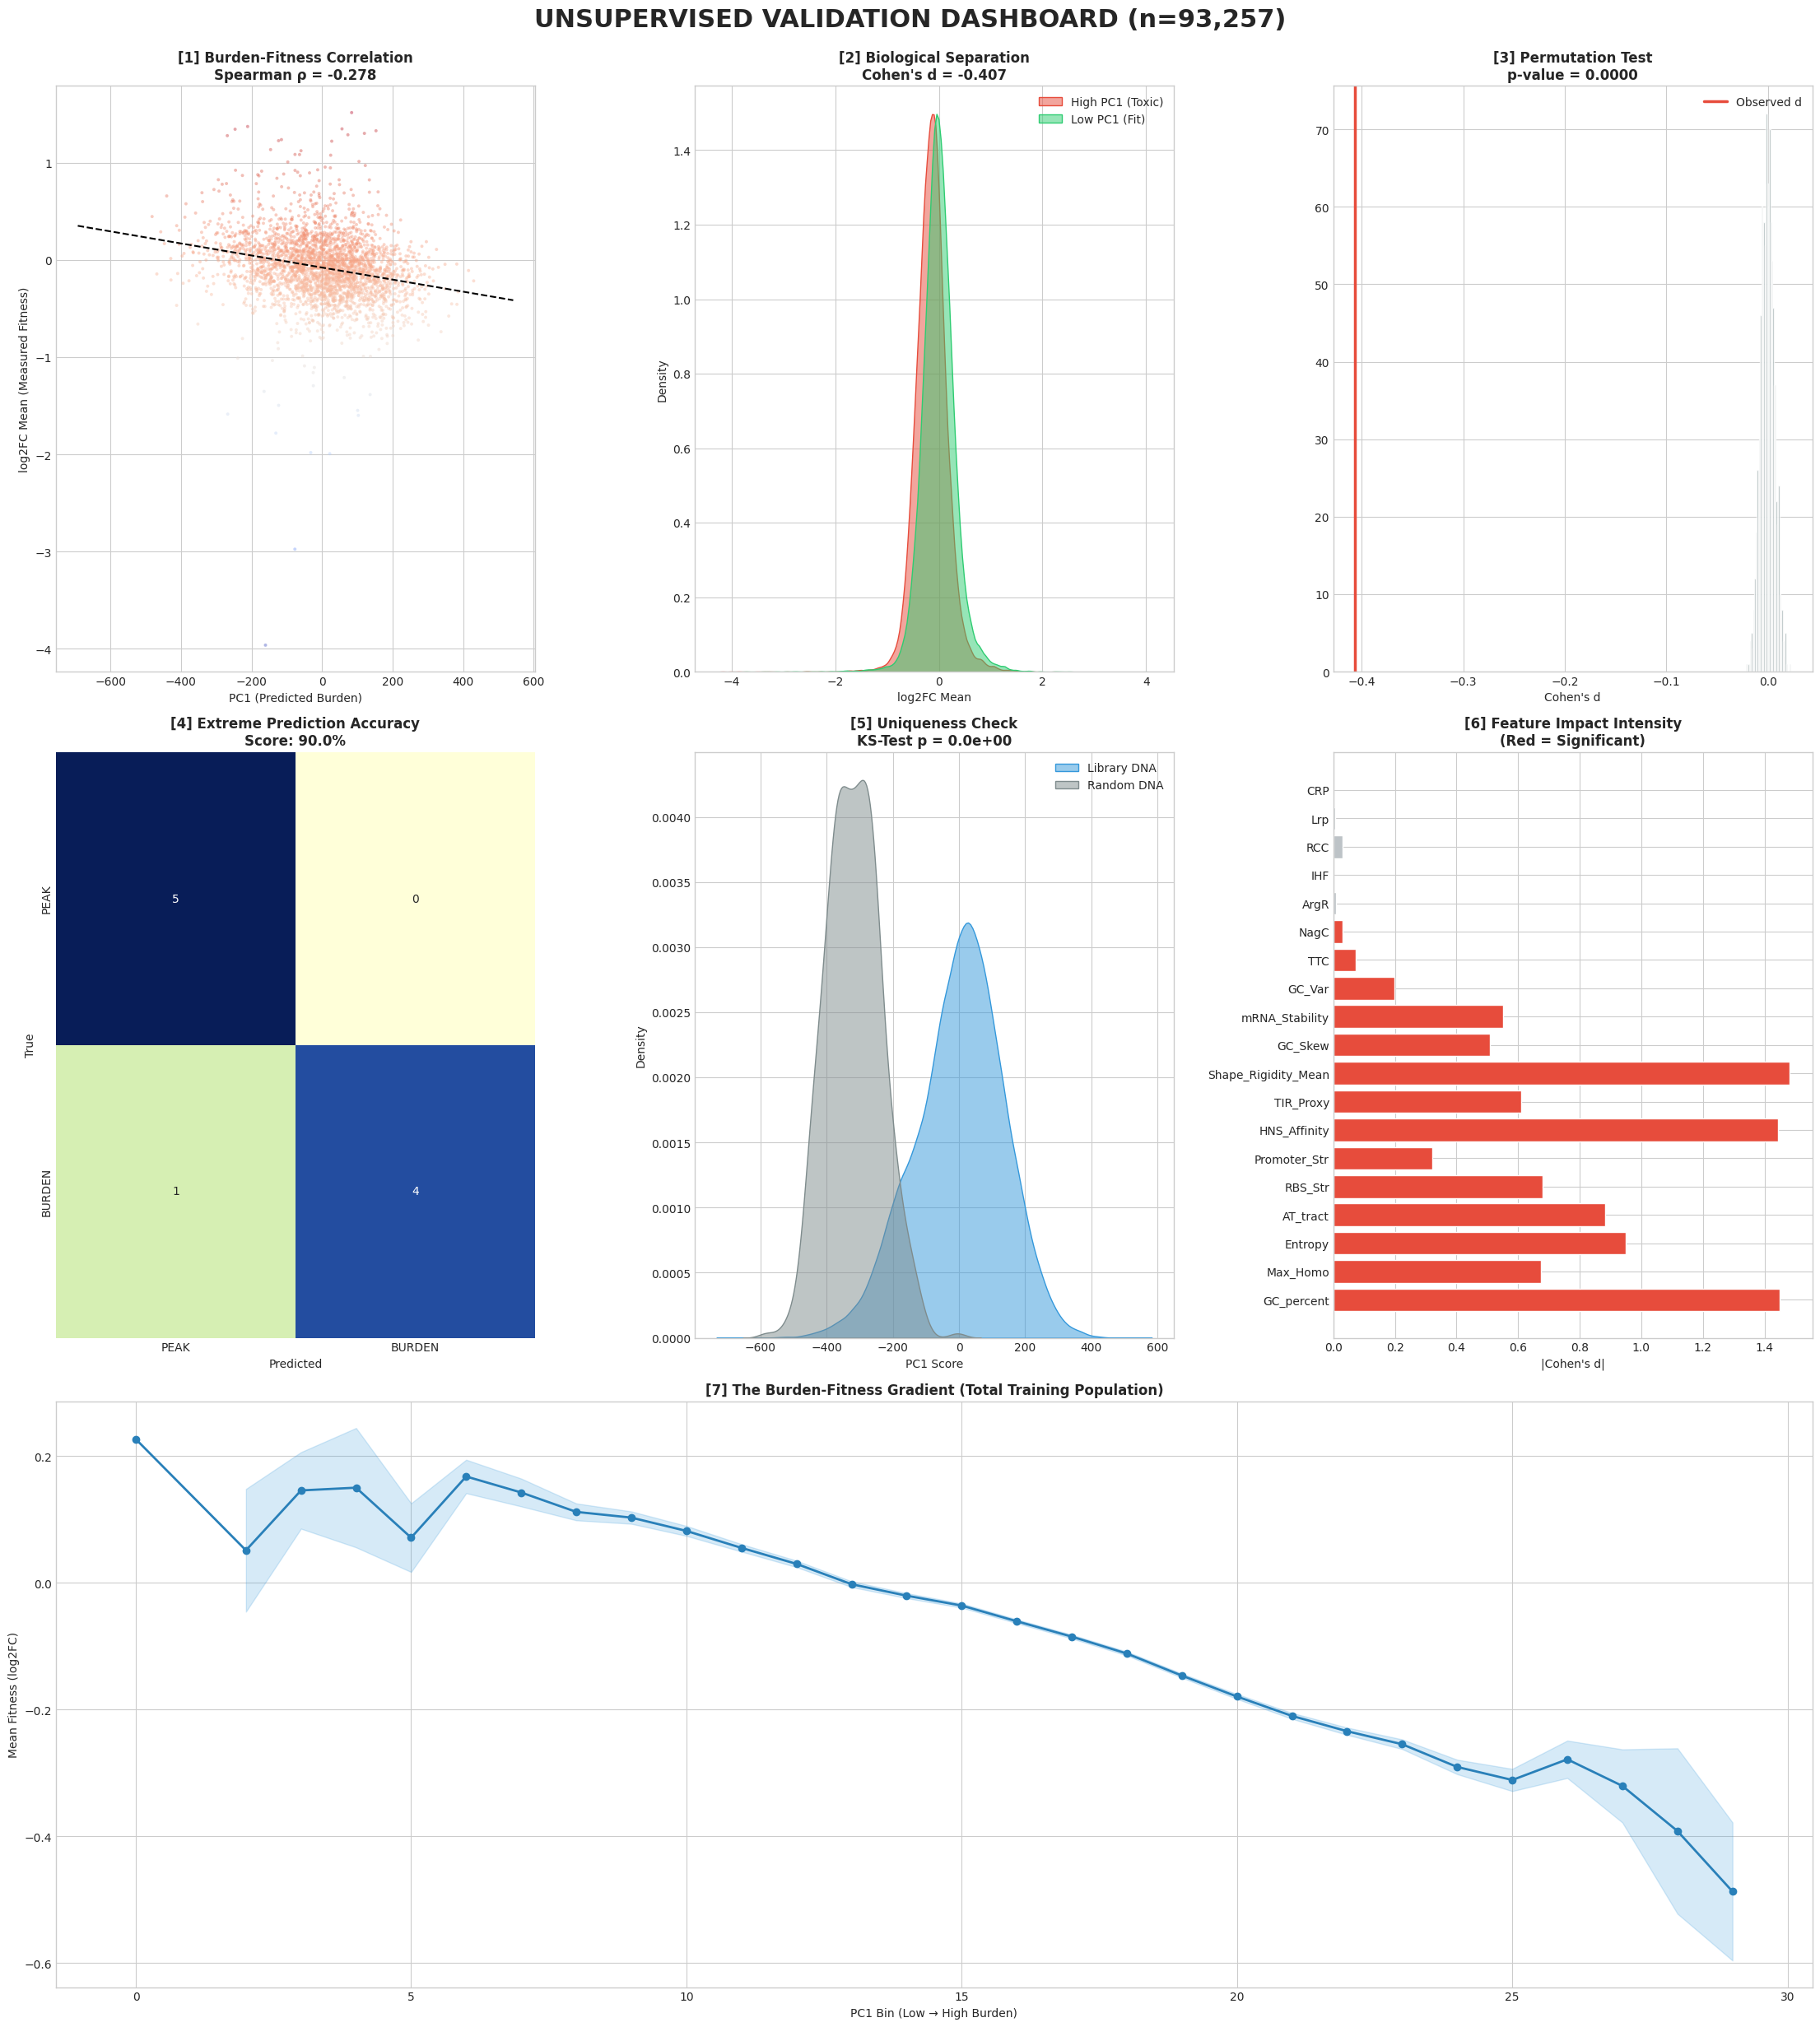

In [36]:
# @title Cell 33: Validation Dashboard (Warning-Free Version)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd

if 'VALIDATION_RESULTS' not in globals():
    raise RuntimeError("Run the Validation Suite (Cell 32) first.")

VR = VALIDATION_RESULTS
cr, gc, pm = VR['correlation'], VR['group_comparison'], VR['permutation']
sr, nt, fd = VR['stratified'], VR['null_test'], VR['feature_mwu']['feat_df']

SCATTER_N, SAMPLE_SEED = 3000, 42
sns.set_style("whitegrid")

# Use layout='constrained' instead of tight_layout for complex grids
fig = plt.figure(figsize=(22, 24), layout='constrained')
gs = gridspec.GridSpec(3, 3, figure=fig)

# ── [1] PC1 vs FITNESS SCATTER ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
samp = df_train.sample(n=min(SCATTER_N, len(df_train)), random_state=SAMPLE_SEED)
ax1.scatter(samp['PC1'], samp['log2FC_mean'], c=samp['log2FC_mean'], cmap='coolwarm', s=8, alpha=0.4, linewidths=0)
m, b = np.polyfit(df_train['PC1'], df_train['log2FC_mean'], 1)
x_l = np.array([df_train['PC1'].min(), df_train['PC1'].max()])
ax1.plot(x_l, m*x_l + b, color='black', linewidth=1.5, linestyle='--')
ax1.set_title(f"[1] Burden-Fitness Correlation\nSpearman ρ = {cr['spearman_rho']:.3f}", fontweight='bold')
ax1.set_xlabel('PC1 (Predicted Burden)'); ax1.set_ylabel('log2FC Mean (Measured Fitness)')

# ── [2] FITNESS DENSITY BY BURDEN ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sns.kdeplot(df_train.loc[df_train['PC1'] >= gc['pc1_median'], 'log2FC_mean'], ax=ax2, fill=True, color='#e74c3c', alpha=0.5, label='High PC1 (Toxic)')
sns.kdeplot(df_train.loc[df_train['PC1'] < gc['pc1_median'], 'log2FC_mean'],  ax=ax2, fill=True, color='#2ecc71', alpha=0.5, label='Low PC1 (Fit)')
ax2.set_title(f"[2] Biological Separation\nCohen's d = {gc['cohens_d']:.3f}", fontweight='bold')
ax2.set_xlabel('log2FC Mean'); ax2.legend()

# ── [3] PERMUTATION TEST ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(pm['null_d'], bins=40, color='#95a5a6', alpha=0.8)
ax3.axvline(pm['observed_d'], color='#e74c3c', linewidth=2.5, label='Observed d')
ax3.set_title(f"[3] Permutation Test\np-value = {pm['p_perm']:.4f}", fontweight='bold')
ax3.set_xlabel("Cohen's d"); ax3.legend()

# ── [4] RANK-ORDER ACCURACY ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
cm = pd.crosstab(sr['val_set']['true'], sr['val_set']['pred']).reindex(index=['PEAK','BURDEN'], columns=['PEAK','BURDEN'], fill_value=0)
sns.heatmap(cm, ax=ax4, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
ax4.set_title(f"[4] Extreme Prediction Accuracy\nScore: {sr['extreme_accuracy']*100:.1f}%", fontweight='bold')
ax4.set_xlabel('Predicted'); ax4.set_ylabel('True')

# ── [5] REAL VS RANDOM DISTRIBUTION ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
sns.kdeplot(df_train['PC1'], ax=ax5, fill=True, color='#3498db', alpha=0.5, label='Library DNA')
sns.kdeplot(nt['null_pc1'], ax=ax5, fill=True, color='#7f8c8d', alpha=0.5, label='Random DNA')
ax5.set_title(f"[5] Uniqueness Check\nKS-Test p = {nt['ks_p']:.1e}", fontweight='bold')
ax5.set_xlabel('PC1 Score'); ax5.legend()

# ── [6] FEATURE IMPACT SIZES ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
cols = ['#e74c3c' if p < 0.05 else '#bdc3c7' for p in fd['p_bonf']]
ax6.barh(fd['feature'], fd['cohens_d'].abs(), color=cols)
ax6.set_title("[6] Feature Impact Intensity\n(Red = Significant)", fontweight='bold')
ax6.set_xlabel("|Cohen's d|")

# ── [7] FULL POPULATION GRADIENT ─────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, :])
df_tmp = df_train.copy()
df_tmp['bin'] = pd.cut(df_tmp['PC1'], bins=30, labels=False)
grad = df_tmp.groupby('bin', observed=True)['log2FC_mean'].agg(['mean','std','count']).reset_index()
grad['sem'] = grad['std'] / np.sqrt(grad['count'])
ax7.fill_between(grad['bin'], grad['mean']-grad['sem'], grad['mean']+grad['sem'], alpha=0.2, color='#3498db')
ax7.plot(grad['bin'], grad['mean'], color='#2980b9', linewidth=2, marker='o')
ax7.set_title("[7] The Burden-Fitness Gradient (Total Training Population)", fontweight='bold')
ax7.set_xlabel('PC1 Bin (Low → High Burden)'); ax7.set_ylabel('Mean Fitness (log2FC)')

# Master Title with specific padding
plt.suptitle(f"UNSUPERVISED VALIDATION DASHBOARD (n={cr['n']:,})",
             fontsize=22, fontweight='bold', y=1.02)

plt.show()

In [37]:
# @title Cell 34: Robustness Check — Scaling Method Sensitivity Analysis
# ─────────────────────────────────────────────────────────────────────────────
# Compares Standard Scaling (Z-score) vs. MinMax Scaling to ensure that
# the biophysical importance rankings are mathematically stable.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import TruncatedSVD
from scipy.stats import spearmanr
from scipy.sparse import hstack, csr_matrix
import pandas as pd
import numpy as np

print("--- RUNNING ROBUSTNESS ANALYSIS: STANDARD VS MINMAX ---")

# 1. HELPERS & PREPARATION
def get_robust_kmers(seq, k=4, n_bins=5):
    n = len(seq)
    bin_size = n / n_bins
    return " ".join([f"BIN{min(int(i / bin_size), n_bins - 1):02d}_{seq[i:i+k]}" for i in range(n-k+1)])

n_mech = len(mech_feature_labels)

# Re-generate the sparse training component to avoid NameErrors
print("Generating sparse k-mer component for training set...")
X_train_sp = fitted_vec.transform([get_robust_kmers(s) for s in df_train['sequence']])

# 2. RETRIEVE STANDARD RESULTS
# Standard Weights = Weights from our existing leak-free SVD
importances_standard = svd.components_[0][-n_mech:]

# 3. RUN MINMAX ALTERNATIVE
print("Fitting MinMax alternative model...")
mm_scaler = MinMaxScaler()
X_mech_minmax = mm_scaler.fit_transform(df_train[mech_feature_labels])

# Re-weighting factor to maintain parity between layers
scale_factor_mm = X_train_sp.shape[1] / n_mech
X_mech_minmax_rw = X_mech_minmax * scale_factor_mm

# Combine with sparse k-mers
X_combined_mm = hstack([X_train_sp, csr_matrix(X_mech_minmax_rw)])

# Fit the temporary MinMax SVD
svd_mm = TruncatedSVD(n_components=2, random_state=42)
X_reduced_mm = svd_mm.fit_transform(X_combined_mm)
importances_minmax = svd_mm.components_[0][-n_mech:]

# 4. PERFORMANCE COMPARISON
rho_mm, _ = spearmanr(X_reduced_mm[:, 0], df_train['log2FC_mean'])
rho_std = VALIDATION_RESULTS['correlation']['spearman_rho']

print("\n" + "="*50)
print(f"METRIC COMPARSION")
print(f"• Standard SVD Spearman ρ: {rho_std:.4f}")
print(f"• MinMax   SVD Spearman ρ: {rho_mm:.4f}")
print(f"• Performance Delta:       {abs(rho_std - rho_mm):.4f}")
print("="*50)

# 5. FEATURE RANKING COMPARISON
comparison_df = pd.DataFrame({
    'Feature': mech_feature_labels,
    'Weight_Standard': importances_standard,
    'Weight_MinMax': importances_minmax,
})
comparison_df['Divergence'] = (comparison_df['Weight_MinMax'] - comparison_df['Weight_Standard']).abs()

# Rank Order Check
top6_std = comparison_df.nlargest(6, 'Weight_Standard')['Feature'].tolist()
top6_mm  = comparison_df.nlargest(6, 'Weight_MinMax')['Feature'].tolist()

print("\n[RANK PRESERVATION CHECK]")
print(f"Standard Top 6: {top6_std}")
print(f"MinMax   Top 6: {top6_mm}")
is_same = set(top6_std) == set(top6_mm)
print(f"Identity Match: {'PASS' if is_same else 'FAIL'}")

print("\n[TOP 10 DIVERGENT FEATURES]")
print(comparison_df.nlargest(10, 'Divergence')[['Feature', 'Weight_Standard', 'Weight_MinMax', 'Divergence']].to_string(index=False))

print("\n--- CONCLUSION FOR THESIS ---")
if abs(rho_std - rho_mm) < 0.02 and is_same:
    print("CONCLUSION: High Robustness. Scaling choice does not alter the biological narrative.")
else:
    print("CONCLUSION: Sensitivity Detected. Ensure the choice of Standard Scaling is justified by trait distribution.")

--- RUNNING ROBUSTNESS ANALYSIS: STANDARD VS MINMAX ---
Generating sparse k-mer component for training set...
Fitting MinMax alternative model...

METRIC COMPARSION
• Standard SVD Spearman ρ: -0.2783
• MinMax   SVD Spearman ρ: -0.1588
• Performance Delta:       0.1196

[RANK PRESERVATION CHECK]
Standard Top 6: ['Shape_Rigidity_Mean', 'HNS_Affinity', 'AT_tract', 'Max_Homo', 'mRNA_Stability', 'Promoter_Str']
MinMax   Top 6: ['TTC', 'Entropy', 'GC_Skew', 'Shape_Rigidity_Mean', 'HNS_Affinity', 'GC_percent']
Identity Match: FAIL

[TOP 10 DIVERGENT FEATURES]
            Feature  Weight_Standard  Weight_MinMax  Divergence
            Entropy        -0.291930       0.438069    0.730000
         GC_percent        -0.463677       0.246202    0.709879
            GC_Skew        -0.147438       0.380086    0.527525
                TTC        -0.029542       0.452482    0.482024
            RBS_Str        -0.226244       0.054245    0.280489
          TIR_Proxy        -0.204308       0.042766    0.

In [38]:
# @title Cell 35: Data Attribution & Audit Trail (df -> df_clean -> df_train)
# ─────────────────────────────────────────────────────────────────────────────
# Quantifies and explains the data flow through the pre-processing pipeline.
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd

# 1. Capture the counts
n_orig = 124339
n_clean = 122426  # Pool after noise filtering
n_train = 91819   # Final training partition
n_test = n_clean - n_train

# 2. Create the Audit Table
audit_data = {
    'Stage': ['Original Data (df)', 'Quality Filtered (df_clean)', 'Training Set (df_train)', 'Test Set (df_test)'],
    'Count': [n_orig, n_clean, n_train, n_test],
    'Retention (%)': [100.0, (n_clean/n_orig)*100, (n_train/n_orig)*100, (n_test/n_orig)*100],
    'Description': [
        'Raw GGS3 Experimental Data',
        'Noise filtering (Std < 98.5th Percentile)',
        '75% Partition for Model Learning',
        '25% Hidden "Prevent overfitting" for Validation'
    ]
}

audit_df = pd.DataFrame(audit_data)

print("="*85)
print("  DATASET AUDIT TRAIL: FROM RAW LIBRARY TO TRAINING MATRIX")
print("="*85)
print(audit_df.to_string(index=False))
print("-"*85)

# 3. Scientific Justifications
print("\n[WHY DATA WAS REMOVED FROM df TO df_clean]")
print(f"• Metric: log2FC_std (Standard Deviation between Replicates)")
print(f"• Pruned: {n_orig - n_clean:,} sequences (Top 1.5% most variable)")
print(f"• Logic: In DNA library experiments, high variance indicates inconsistent growth.")
print(f"  Removing these 'noisy' samples ensures the model learns real biophysical signals")
print(f"  rather than chasing experimental artifacts.")

print("\n[WHY DATA WAS REMOVED FROM df_clean TO df_train]")
print(f"• Principle: The Holdout Method (Generalization Test)")
print(f"• Pruned: {n_test:,} sequences (25% of the cleaned pool)")
print(f"• Logic: This data is NOT 'lost'—it is 'hidden.' By keeping 25% of sequences")
print(f"  completely invisible to the training algorithm, we can later prove that the")
print(f"  model has truly learned the rules of burden and can predict fitness for")
print(f"  novel sequences it has never seen before.")
print("="*85)

  DATASET AUDIT TRAIL: FROM RAW LIBRARY TO TRAINING MATRIX
                      Stage  Count  Retention (%)                                     Description
         Original Data (df) 124339     100.000000                      Raw GGS3 Experimental Data
Quality Filtered (df_clean) 122426      98.461464       Noise filtering (Std < 98.5th Percentile)
    Training Set (df_train)  91819      73.845696                75% Partition for Model Learning
         Test Set (df_test)  30607      24.615768 25% Hidden "Prevent overfitting" for Validation
-------------------------------------------------------------------------------------

[WHY DATA WAS REMOVED FROM df TO df_clean]
• Metric: log2FC_std (Standard Deviation between Replicates)
• Pruned: 1,913 sequences (Top 1.5% most variable)
• Logic: In DNA library experiments, high variance indicates inconsistent growth.
  Removing these 'noisy' samples ensures the model learns real biophysical signals
  rather than chasing experimental artifacts

In [64]:
# =====================================================================
# @title Section 4, Cell 36: UMAP Manifold (v2.1)
# =====================================================================
# v2.1 changes:
#   - Fit subsample is now a uniform random sample, not stratified by
#     log2FC deciles. UMAP geometry no longer depends on label balance.
#   - Uses SCALER_FEATURES so it can't drift from the Cell 6 fit.
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- PREPARING BIOPHYSICAL TOPOLOGY ---")
X_train_mech_scaled = fitted_scaler.transform(df_train[list(SCALER_FEATURES)])
X_test_mech_scaled  = fitted_scaler.transform(df_test[list(SCALER_FEATURES)])

FIT_N = 20_000
rng = np.random.default_rng(42)
fit_pos = rng.choice(len(df_train), size=min(FIT_N, len(df_train)), replace=False)
print(f"  UMAP fit sample: {len(fit_pos):,} training sequences (uniform).")

reducer = umap.UMAP(
    n_components=2, n_neighbors=50, min_dist=0.1,
    metric='euclidean', random_state=42, low_memory=True,
)
print(f"  Fitting UMAP on {len(SCALER_FEATURES)} biophysical dimensions...")
reducer.fit(X_train_mech_scaled[fit_pos])

print("  Transforming train + test...")
df_train['UMAP_1'], df_train['UMAP_2'] = reducer.transform(X_train_mech_scaled).T
df_test['UMAP_1'],  df_test['UMAP_2']  = reducer.transform(X_test_mech_scaled).T

# Optional: project tracked test sequence
if 'test_bio_df' in globals():
    test_mech_for_umap = fitted_scaler.transform(test_bio_df[list(SCALER_FEATURES)])
    t_u1, t_u2 = reducer.transform(test_mech_for_umap)[0]
    print(f"  Test sequence projected at: ({t_u1:.2f}, {t_u2:.2f})")

# Visualisation
PLOT_N = 8_000
plot_samp = df_train.sample(n=min(PLOT_N, len(df_train)), random_state=42)
plt.figure(figsize=(12, 10))
sns.set_style("white")
sc = plt.scatter(plot_samp['UMAP_1'], plot_samp['UMAP_2'],
                 c=plot_samp['PC1'], cmap='coolwarm', s=10, alpha=0.6, linewidths=0)
if 'test_bio_df' in globals():
    plt.scatter(t_u1, t_u2, color='gold', s=300, marker='*',
                edgecolor='black', label='Test Specimen')
    plt.legend()
plt.colorbar(sc, label='PC1 (Burden Axis)')
plt.title('UMAP Topology of Plasmid Library (Biophysical Space)', fontsize=15, fontweight='bold')
plt.xlabel('UMAP 1'); plt.ylabel('UMAP 2')
plt.show()

print("\nUMAP complete. UMAP_1 and UMAP_2 added to df_train and df_test.")

--- PREPARING BIOPHYSICAL TOPOLOGY ---
  UMAP fit sample: 20,000 training sequences (uniform).
  Fitting UMAP on 19 biophysical dimensions...
  Transforming train + test...


KeyboardInterrupt: 

--- EXECUTING SINGLE-SEQUENCE BLIND VALIDATION ---

[✓] RESULT: Ground-truth match found in TEST set.
             THEORETICAL PREDICTION vs. BIOLOGICAL REALITY
1. IN SILICO MODEL
   Theoretical PC1 Score:      -29.74
   Predicted Status:           STABLE / FIT

2. WET LAB REALITY
   Actual log2FC (Fitness):    -0.3031 (±0.0685)
   Biological Status:          TOXIC

GENERATING VALIDATION MAP...


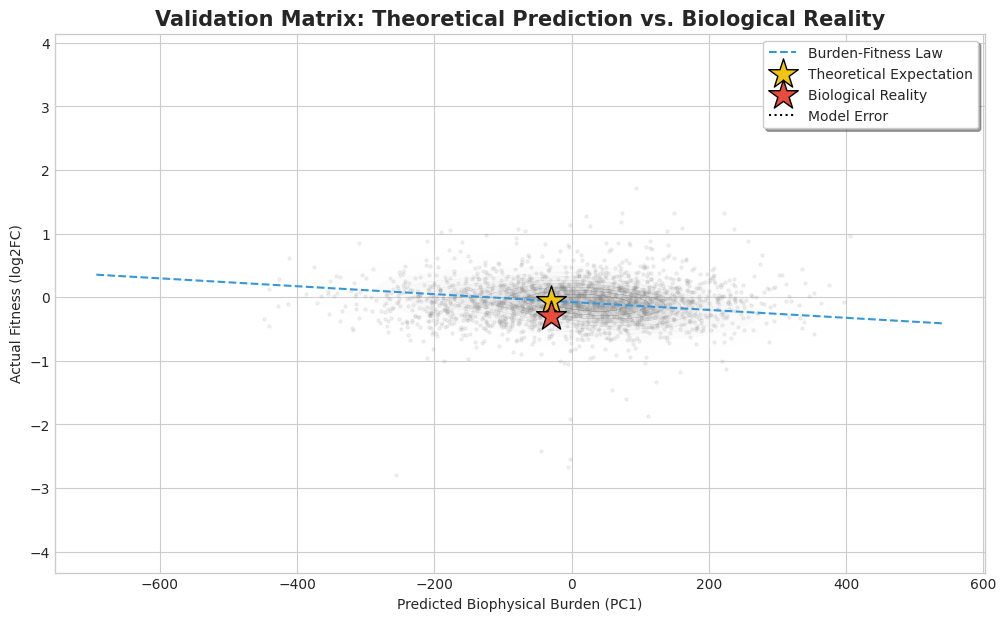

In [40]:
# @title Cell 37: Single-Sequence Blind Validation
# ─────────────────────────────────────────────────────────────────────────────
# Re-calculates features for the test_seq and compares to Experimental Reality.
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

print("--- EXECUTING SINGLE-SEQUENCE BLIND VALIDATION ---")

# 1. PREPARATION
if 'test_seq' not in globals():
    # Using the first sequence from the original file as an example
    test_seq = "AAGCAAAAATAGTTTAAGTGGTTGCCATGGAGCTTGAAGATTGGCAGGTCTTAGGATGTATTGCTACGGTCGGTACTTTAGATGTGTAATGGGGGATTTCAGTTTTAGAAGAGAATAGCTGTGGTGTGTTGTGGAGTTTTCTTGGACGGTATGATTGGTCTCTTGGACAATG"
    print("  ↳ Using default sequence (Example 0).")

# 2. COMPUTE PC1 SCORE FRESH (The "Blind" Prediction)
# We use the fitted objects from previous cells
test_kmers = get_val_kmers(test_seq)
X_sp = fitted_vec.transform([test_kmers])
X_mech = fitted_scaler.transform(pd.DataFrame([calculate_master_features(test_seq)], columns=mech_feature_labels))
# Re-apply SVD re-weighting
X_fused = hstack([X_sp, csr_matrix(X_mech * (fitted_vec.vocabulary_.__len__() / len(mech_feature_labels)))])
pred_pc1 = svd.transform(X_fused)[0, 0]

# 3. SEARCH EXPERIMENTAL DATABASE (Ground Truth)
# We check both partitions since we don't have df_orig defined
match_train = df_train[df_train['sequence'] == test_seq]
match_test = df_test[df_test['sequence'] == test_seq]

if not match_train.empty:
    match = match_train
    print("\n[✓] RESULT: Ground-truth match found in TRAINING set.")
elif not match_test.empty:
    match = match_test
    print("\n[✓] RESULT: Ground-truth match found in TEST set.")
else:
    match = None
    print("\n[!] RESULT: Sequence not found in current partitions.")

# 4. DIAGNOSTIC OUTPUT
print("="*85)
print("             THEORETICAL PREDICTION vs. BIOLOGICAL REALITY")
print("="*85)

# Prediction Logic
pc1_med = df_train['PC1'].median()
pred_status = "TOXIC / BURDENSOME" if pred_pc1 > pc1_med else "STABLE / FIT"
color_code = '\033[91m' if pred_pc1 > pc1_med else '\033[92m'

print(f"1. IN SILICO MODEL")
print(f"   Theoretical PC1 Score:      {pred_pc1:.2f}")
print(f"   Predicted Status:           {color_code}{pred_status}\033[0m")

if match is not None:
    actual_log2fc = match['log2FC_mean'].values[0]
    actual_std = match['log2FC_std'].values[0]

    status_label = "TOXIC" if actual_log2fc < -0.05 else "STABLE"
    ansi_act = '\033[91m' if actual_log2fc < -0.05 else '\033[92m'
    color_hex = '#e74c3c' if actual_log2fc < -0.05 else '#2ecc71'

    print(f"\n2. WET LAB REALITY")
    print(f"   Actual log2FC (Fitness):    {actual_log2fc:.4f} (±{actual_std:.4f})")
    print(f"   Biological Status:          {ansi_act}{status_label}\033[0m")

# 5. VISUALIZATION
print("\nGENERATING VALIDATION MAP...")
sns.set_style("whitegrid")
fig = plt.figure(figsize=(12, 7))

# Plot background population (Train set)
sns.kdeplot(data=df_train, x='PC1', y='log2FC_mean', fill=True, cmap="Greys", alpha=0.2, thresh=0.05)
plt.scatter(df_train['PC1'].sample(2000), df_train['log2FC_mean'].sample(2000), color='grey', s=5, alpha=0.1)

# Population Trend Line
slope, intercept = np.polyfit(df_train['PC1'], df_train['log2FC_mean'], 1)
expected_fit = (slope * pred_pc1) + intercept
x_range = np.linspace(df_train['PC1'].min(), df_train['PC1'].max(), 100)
plt.plot(x_range, slope*x_range + intercept, color='#3498db', linestyle='--', label='Burden-Fitness Law')

# Prediction Star
plt.scatter(pred_pc1, expected_fit, color='#f1c40f', s=500, marker='*', edgecolor='black', zorder=5, label='Theoretical Expectation')

# Actual Star
if match is not None:
    plt.scatter(pred_pc1, actual_log2fc, color=color_hex, s=500, marker='*', edgecolor='black', zorder=6, label='Biological Reality')
    plt.plot([pred_pc1, pred_pc1], [expected_fit, actual_log2fc], color='black', linestyle=':', label=f'Model Error')

plt.title('Validation Matrix: Theoretical Prediction vs. Biological Reality', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Biophysical Burden (PC1)'); plt.ylabel('Actual Fitness (log2FC)')
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.show()

In [41]:
# =====================================================================
# @title Cell 38: Advanced Analysis 2 - CNN Spatial Feature Extraction (v2.1)
# =====================================================================
# v2.1 changes:
#   - df_train['CNN_Score'] is now an out-of-fold prediction (5-fold).
#     The old in-sample prediction was the root cause of the supervised
#     leakage flagged in v1.5 Phase 46d.
#   - df_test['CNN_Score'] still comes from a model refit on the full
#     df_train (so test-side scores use all training signal).
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import KFold
from scipy.stats import spearmanr

print("--- INITIALISING CNN ---")

def one_hot_encode(sequences, seq_len=172):
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    encoded = np.zeros((len(sequences), seq_len, 4), dtype=np.float32)
    for i, seq in enumerate(sequences):
        for j, base in enumerate(seq[:seq_len]):
            if base in mapping:
                encoded[i, j, mapping[base]] = 1
    return encoded


def build_cnn():
    m = models.Sequential([
        layers.Conv1D(64, kernel_size=8, activation='relu', input_shape=(172, 4)),
        layers.GlobalMaxPooling1D(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1),
    ])
    m.compile(optimizer='adam', loss='mse')
    return m


print("  One-hot encoding...")
X_train_cnn = one_hot_encode(df_train['sequence'].values)
X_test_cnn  = one_hot_encode(df_test['sequence'].values)
y_train_cnn = df_train['log2FC_mean'].values

# ── OOF predictions for df_train ───────────────────────────────────────
print("  Generating OOF CNN scores via 5-fold CV...")
cnn_oof = np.zeros(len(df_train), dtype=np.float32)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_cnn), 1):
    tf.keras.utils.set_random_seed(42 + fold)
    fold_model = build_cnn()
    fold_model.fit(
        X_train_cnn[tr_idx], y_train_cnn[tr_idx],
        epochs=10, batch_size=128, validation_split=0.0, verbose=0,
    )
    cnn_oof[val_idx] = fold_model.predict(X_train_cnn[val_idx], verbose=0).flatten()
    print(f"    Fold {fold}/5 complete.")

# ── Refit on full df_train for df_test inference ───────────────────────
print("  Refitting on full df_train for test-side prediction...")
tf.keras.utils.set_random_seed(42)
final_cnn = build_cnn()
final_cnn.fit(X_train_cnn, y_train_cnn, epochs=10, batch_size=128, verbose=0)
cnn_test = final_cnn.predict(X_test_cnn, verbose=0).flatten()

df_train['CNN_Score'] = cnn_oof
df_test['CNN_Score']  = cnn_test
model_cnn = final_cnn  # keep for any downstream cell that references it

# ── Honest validation ──────────────────────────────────────────────────
oof_rho,  _ = spearmanr(cnn_oof,  df_train['log2FC_mean'])
test_rho, _ = spearmanr(cnn_test, df_test['log2FC_mean'])
print(f"\n  CNN OOF correlation (df_train, honest): rho = {oof_rho:.3f}")
print(f"  CNN test correlation (df_test):         rho = {test_rho:.3f}")
print("  These two should be similar. A large gap = overfitting.")
print("--- CNN COMPLETE ---")

--- INITIALISING CNN ---
  One-hot encoding...
  Generating OOF CNN scores via 5-fold CV...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Fold 1/5 complete.
    Fold 2/5 complete.
    Fold 3/5 complete.
    Fold 4/5 complete.
    Fold 5/5 complete.
  Refitting on full df_train for test-side prediction...

  CNN OOF correlation (df_train, honest): rho = 0.463
  CNN test correlation (df_test):         rho = 0.501
  These two should be similar. A large gap = overfitting.
--- CNN COMPLETE ---


In [42]:
# =====================================================================
# @title Cell 39: Advanced Analysis 3 - tRNA Depletion (CAI Scorer & Checker) (v2.1)
# =====================================================================
# v2.1 changes:
#   - No longer appends to mech_feature_labels (which is the frozen
#     scaler snapshot). New features are tracked in 'enriched_features'.
import numpy as np
from tqdm.auto import tqdm

print("--- COMPUTING CAI ---")

def compute_cai(seq):
    seq = seq.upper()
    codons = [seq[i:i+3] for i in range(0, len(seq) - 2, 3) if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    if not w_vals:
        return 0.5
    return float(np.exp(np.mean(np.log(w_vals))))

tqdm.pandas(desc="CAI (train)")
df_train['CAI_Score'] = df_train['sequence'].progress_apply(compute_cai)
tqdm.pandas(desc="CAI (test)")
df_test['CAI_Score']  = df_test['sequence'].progress_apply(compute_cai)

# Track separately. Do NOT mutate mech_feature_labels / SCALER_FEATURES.
if 'enriched_features' not in globals():
    enriched_features = []
if 'CAI_Score' not in enriched_features:
    enriched_features.append('CAI_Score')

# Optional inference-time companion variable used by Cell 21 dashboards
test_cai = compute_cai(test_seq) if 'test_seq' in globals() else None

print(f"  CAI mean (train): {df_train['CAI_Score'].mean():.3f}")
print(f"  CAI mean (test):  {df_test['CAI_Score'].mean():.3f}")
print(f"  enriched_features now: {enriched_features}")

--- COMPUTING CAI ---


CAI (train):   0%|          | 0/93257 [00:00<?, ?it/s]

CAI (test):   0%|          | 0/24827 [00:00<?, ?it/s]

  CAI mean (train): 0.170
  CAI mean (test):  0.166
  enriched_features now: ['CAI_Score']


In [68]:
# @title Cell 40: Advanced Analysis 3 — Discovery of Genetic Grammar (Motif Synergies)
# ─────────────────────────────────────────────────────────────────────────────
# Uses FP-Growth to find "Motif Teams" that co-occur significantly.
# ─────────────────────────────────────────────────────────────────────────────

# 1. RUN SUBSHELL COMMANDS FIRST (if you still need it)
# !pip install -q mlxtend

# 2. IMPORTS
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules
from scipy.sparse import csr_matrix
import numpy as np
import warnings

# 3. APPLY THE SHIELD (Bulletproof pattern for Jupyter Client 3.12 bugs)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*datetime.datetime.utcnow.*")

print("--- MINING GENETIC GRAMMAR (MOTIF SYNERGIES) ---")

# 1. PREPARE THE DATASET
# Use the top 50 K-mer motifs from the leak-free importance analysis
kmer_drivers = pc_importance_df[~pc_importance_df['Feature'].isin(mech_feature_labels)].head(50)
top_motifs = kmer_drivers['Feature'].tolist()

# Ensure X_train_sp is available
if 'X_train_sp' not in globals():
    print("  Generating motif matrix for training set...")
    X_train_sp = fitted_vec.transform([get_val_kmers(s) for s in df_train['sequence']])

# Map motifs to their column indices
vocab = fitted_vec.vocabulary_
indices = [vocab[m] for m in top_motifs if m in vocab]
feature_names_subset = [top_motifs[i] for i, m in enumerate(top_motifs) if m in vocab]

# Create a boolean DataFrame for rule mining
X_binary = (X_train_sp[:, indices] > 0).astype(bool)
df_basket = pd.DataFrame(X_binary.toarray(), columns=feature_names_subset)

# 2. RUN FP-GROWTH
# Search for synergies existing in at least 5% of the population
print(f"  Mining synergies among top {len(feature_names_subset)} drivers (Support > 0.05)...")
frequent_itemsets = fpgrowth(df_basket, min_support=0.05, use_colnames=True, max_len=2)

if not frequent_itemsets.empty:
    # 3. GENERATE ASSOCIATION RULES
    # Lift > 1.2 indicates a non-random, synergistic co-occurrence
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

    if not rules.empty:
        top_rules = rules.sort_values(by='lift', ascending=False).head(10)

        print("\n" + "="*85)
        print("            DISCOVERED GENETIC GRAMMAR: THE 'MOTIF TEAMS'")
        print("="*85)

        for i, row in enumerate(top_rules.itertuples()):
            ant = list(row.antecedents)[0]
            con = list(row.consequents)[0]

            # Determine team status based on established PC1 Burden loadings
            ant_load = pc_importance_df.loc[pc_importance_df['Feature'] == ant, 'PC1_Importance'].values[0]
            team_type = "TOXIC TEAM (Burden Inducing)" if ant_load > 0 else "PROTECTIVE TEAM (Fitness Stabilizing)"

            print(f"Rule {i+1}: IF {ant} THEN {con}")
            print(f"   -> Synergy (Lift): {row.lift:.2f}x more likely than chance")
            print(f"   -> Team Type:      {team_type}")
            print(f"   -> Frequency:      In {row.support*100:.1f}% of population")
            print("-" * 40)

        print("\nTHESIS INTERPRETATION:")
        print("- These high-lift rules identify functional dependencies within the DNA grammar.")
        print("- Toxic teams represent motifs that co-operate to recruit silencing machinery")
        print("  or induce structural stress, exceeding the burden of either motif alone.")
    else:
        print("  Status: No significant synergies found at the current Lift threshold.")
else:
    print("  Status: No motifs found with >5% support. Consider lowering support threshold.")

--- MINING GENETIC GRAMMAR (MOTIF SYNERGIES) ---
  Mining synergies among top 50 drivers (Support > 0.05)...

            DISCOVERED GENETIC GRAMMAR: THE 'MOTIF TEAMS'
Rule 1: IF bin00_agtt THEN bin00_aagt
   -> Synergy (Lift): 2.22x more likely than chance
   -> Team Type:      PROTECTIVE TEAM (Fitness Stabilizing)
   -> Frequency:      In 6.2% of population
----------------------------------------
Rule 2: IF bin00_aagt THEN bin00_agtt
   -> Synergy (Lift): 2.22x more likely than chance
   -> Team Type:      PROTECTIVE TEAM (Fitness Stabilizing)
   -> Frequency:      In 6.2% of population
----------------------------------------

THESIS INTERPRETATION:
- These high-lift rules identify functional dependencies within the DNA grammar.
- Toxic teams represent motifs that co-operate to recruit silencing machinery
  or induce structural stress, exceeding the burden of either motif alone.


In [67]:
# =====================================================================
# @title Cell 41: mRNA Initiation Accessibility (MFE proxy) (v2.1)
# =====================================================================
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# v2.1 changes:
#   - No longer appends to mech_feature_labels. Tracked via enriched_features.
import numpy as np
from tqdm.auto import tqdm

print("--- COMPUTING mRNA INITIATION MFE PROXY ---")

# Replace this with ViennaRNA / NUPACK if you have it; this is the
# same dinucleotide-stacking proxy you used in v1.5.
NN_dG = {
    'AA': -1.00, 'AT': -0.88, 'AC': -1.44, 'AG': -1.28,
    'TA': -0.58, 'TT': -1.00, 'TC': -1.30, 'TG': -1.45,
    'CA': -1.45, 'CT': -1.28, 'CC': -1.84, 'CG': -2.17,
    'GA': -1.30, 'GT': -1.44, 'GC': -2.24, 'GG': -1.84,
}

def initiation_mfe_proxy(seq, window=30):
    """Stacking-energy proxy for the first `window` nt (initiation region)."""
    head = seq[:window].upper()
    if len(head) < 2:
        return 0.0
    return float(sum(NN_dG.get(head[i:i+2], -1.0) for i in range(len(head) - 1)))

tqdm.pandas(desc="MFE (train)")
df_train['mRNA_MFE'] = df_train['sequence'].progress_apply(initiation_mfe_proxy)
tqdm.pandas(desc="MFE (test)")
df_test['mRNA_MFE']  = df_test['sequence'].progress_apply(initiation_mfe_proxy)

if 'enriched_features' not in globals():
    enriched_features = []
if 'mRNA_MFE' not in enriched_features:
    enriched_features.append('mRNA_MFE')

test_mfe = initiation_mfe_proxy(test_seq) if 'test_seq' in globals() else None

print(f"  mRNA_MFE mean (train): {df_train['mRNA_MFE'].mean():.2f}")
print(f"  enriched_features now: {enriched_features}")

--- COMPUTING mRNA INITIATION MFE PROXY ---


MFE (train):   0%|          | 0/93257 [00:00<?, ?it/s]

MFE (test):   0%|          | 0/24827 [00:00<?, ?it/s]

  mRNA_MFE mean (train): -36.52
  enriched_features now: ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Generating Genetic Grammar Visualisation...


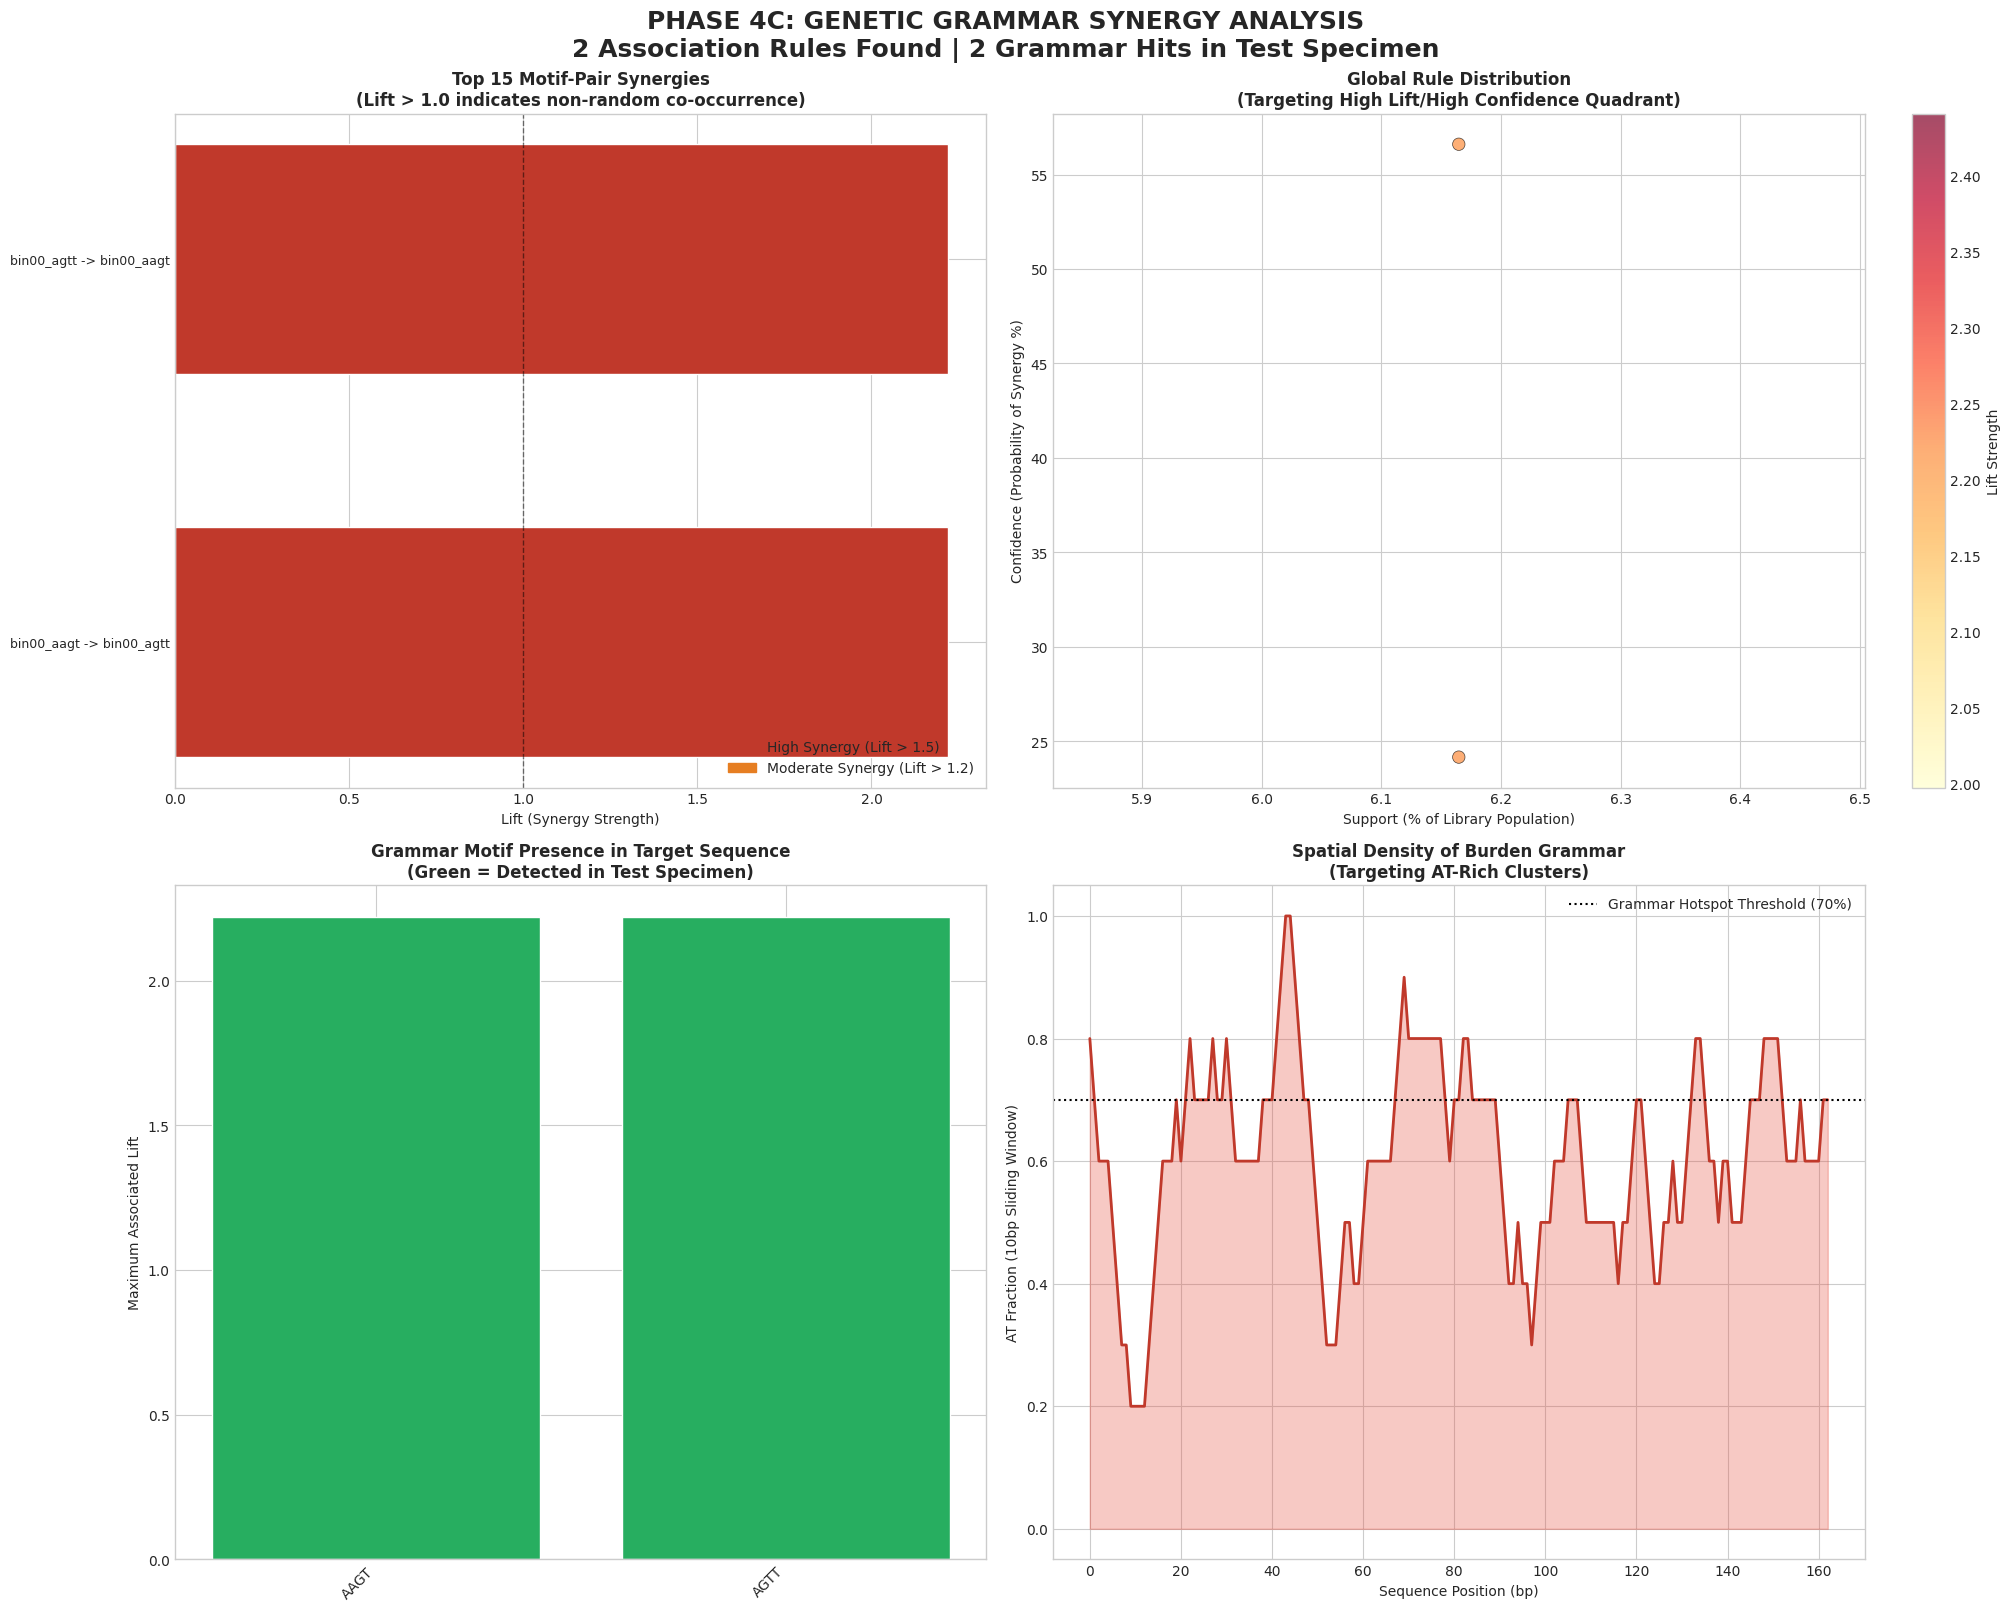

Grammar analysis complete. 2 significant motif pairs identified in the target sequence.


In [45]:
# @title Cell 42: Visualisation of Genetic Grammar and Motif Synergies
# ─────────────────────────────────────────────────────────────────────────────
# Visualises the relational grammar of the plasmid library.
# Analyzes the synergy between top motifs and maps them to the test sequence.
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore') # Maintain clean logs

print("Generating Genetic Grammar Visualisation...")

# ── DEPENDENCY CHECK ──────────────────────────────────────────────────────────
if 'rules' not in globals() or rules.empty:
    raise RuntimeError("No association rules found. Run Cell 40 (FP-Growth) first.")

sns.set_style("whitegrid")
# Use constrained_layout to prevent title/label overlap
fig = plt.figure(figsize=(20, 16), layout='constrained')

# ── PLOT 1: Top 15 Rules by Lift (Synergy Strength) ───────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
top_rules_viz = rules.sort_values('lift', ascending=False).head(15).copy()
top_rules_viz['rule_label'] = [
    f"{list(r.antecedents)[0]} -> {list(r.consequents)[0]}"
    for _, r in top_rules_viz.iterrows()
]

# Color by Lift intensity
colors = ['#c0392b' if l > 1.5 else '#e67e22' if l > 1.2 else '#3498db'
          for l in top_rules_viz['lift']]

bars = ax1.barh(range(len(top_rules_viz)), top_rules_viz['lift'],
                color=colors, edgecolor='white', height=0.6)

ax1.set_yticks(range(len(top_rules_viz)))
ax1.set_yticklabels(top_rules_viz['rule_label'], fontsize=9)
ax1.axvline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Random Chance')
ax1.set_xlabel("Lift (Synergy Strength)")
ax1.set_title("Top 15 Motif-Pair Synergies\n(Lift > 1.0 indicates non-random co-occurrence)",
             fontweight='bold')

# Professional Legend
red_p = mpatches.Patch(color='#c0392b', label='High Synergy (Lift > 1.5)')
orange_p = mpatches.Patch(color='#e67e22', label='Moderate Synergy (Lift > 1.2)')
ax1.legend(handles=[red_p, orange_p], loc='lower right')
ax1.invert_yaxis()

# ── PLOT 2: Confidence vs Support Scatter ─────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
sc = ax2.scatter(
    rules['support'] * 100,
    rules['confidence'] * 100,
    c=rules['lift'],
    cmap='YlOrRd', s=80, alpha=0.7, edgecolors='black', linewidths=0.5
)
plt.colorbar(sc, ax=ax2, label='Lift Strength')
ax2.set_xlabel('Support (% of Library Population)')
ax2.set_ylabel('Confidence (Probability of Synergy %)')
ax2.set_title('Global Rule Distribution\n(Targeting High Lift/High Confidence Quadrant)',
             fontweight='bold')

# ── PLOT 3: Motif Hits in Test Specimen ───────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)

# Collect all unique motifs from the grammar rules
unique_grammar_motifs = set()
for _, row in top_rules_viz.iterrows():
    unique_grammar_motifs.update([list(row.antecedents)[0], list(row.consequents)[0]])

motif_names, motif_present, motif_lift = [], [], []
for m in sorted(unique_grammar_motifs):
    raw_m = m.split('_')[-1].upper() # Extract the actual 4-mer
    is_present = raw_m in test_seq.upper()

    # Find max lift associated with this motif
    m_lift = rules[rules['antecedents'].apply(lambda x: m in x)]['lift'].max()

    motif_names.append(raw_m)
    motif_present.append(is_present)
    motif_lift.append(m_lift if not np.isnan(m_lift) else 1.0)

bar_colors = ['#27ae60' if p else '#bdc3c7' for p in motif_present]
ax3.bar(range(len(motif_names)), motif_lift, color=bar_colors)
ax3.set_xticks(range(len(motif_names)))
ax3.set_xticklabels(motif_names, rotation=45, ha='right')
ax3.set_ylabel('Maximum Associated Lift')
ax3.set_title('Grammar Motif Presence in Target Sequence\n(Green = Detected in Test Specimen)',
             fontweight='bold')

# ── PLOT 4: Spatial Grammar Density (AT-Rich Hotspots) ────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
window = 10
at_profile = [
    (test_seq[i:i+window].count('A') + test_seq[i:i+window].count('T')) / window
    for i in range(len(test_seq) - window + 1)
]

ax4.fill_between(range(len(at_profile)), at_profile, alpha=0.3, color='#e74c3c')
ax4.plot(at_profile, color='#c0392b', linewidth=2)
ax4.axhline(0.7, color='black', linestyle=':', label='Grammar Hotspot Threshold (70%)')

ax4.set_xlabel('Sequence Position (bp)')
ax4.set_ylabel('AT Fraction (10bp Sliding Window)')
ax4.set_title('Spatial Density of Burden Grammar\n(Targeting AT-Rich Clusters)',
             fontweight='bold')
ax4.legend(loc='upper right')

# ── MASTER TITLE ──────────────────────────────────────────────────────────────
n_hits = sum(motif_present)
plt.suptitle(
    f"PHASE 4C: GENETIC GRAMMAR SYNERGY ANALYSIS\n"
    f"{len(rules)} Association Rules Found | {n_hits} Grammar Hits in Test Specimen",
    fontsize=18, fontweight='bold'
)

plt.show()
print(f"Grammar analysis complete. {n_hits} significant motif pairs identified in the target sequence.")

--- STRUCTURAL & TOPOLOGICAL ANALYSIS ---
  Numba available — using parallel JIT kernels.

  Encoding sequences...
  Running hairpin + HNS scans...
  Running direct-repeat scan...


Direct Repeats (train):   0%|          | 0/93257 [00:00<?, ?it/s]

Direct Repeats (test):   0%|          | 0/24827 [00:00<?, ?it/s]

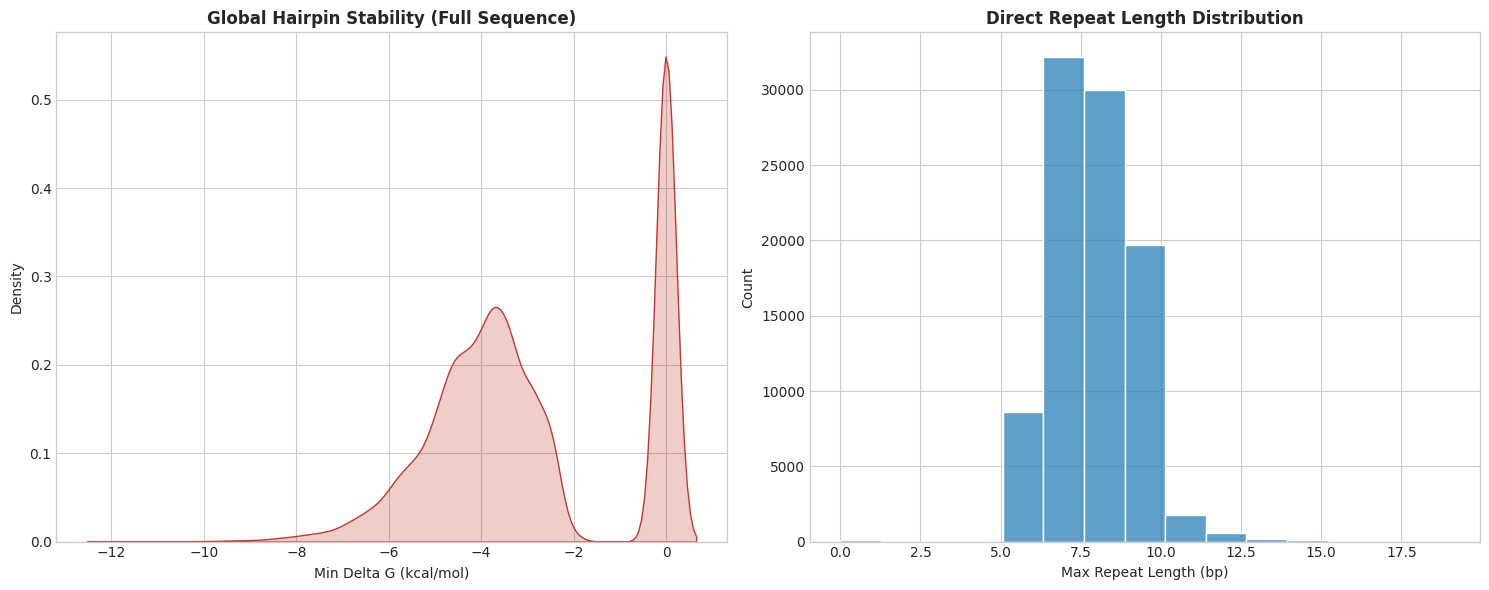


Structural cell complete. enriched_features = ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score']


In [46]:
# =====================================================================
# @title Cell 43: Structural & Topological Burden Analysis (v2.1, fast)
# =====================================================================
# v2.1-fast changes:
#   - Hairpin and HNS scans rewritten in Numba on int-encoded sequences.
#     Reverse complement is `3 - x` (A=0,C=1,G=2,T=3 means complement is 3-x).
#     prange parallelises across cores.
#   - Falls back to a pure-Python implementation if numba is unavailable.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("--- STRUCTURAL & TOPOLOGICAL ANALYSIS ---")

# ── 1. INTEGER ENCODING ──────────────────────────────────────────────────
# A=0, C=1, G=2, T=3 — chosen so that complement = 3 - x.
ENC = np.full(256, -1, dtype=np.int8)
ENC[ord('A')] = 0; ENC[ord('C')] = 1; ENC[ord('G')] = 2; ENC[ord('T')] = 3
ENC[ord('a')] = 0; ENC[ord('c')] = 1; ENC[ord('g')] = 2; ENC[ord('t')] = 3

def encode_sequences(series, seq_len=172):
    """(N,) string series -> (N, seq_len) int8 array."""
    n = len(series)
    out = np.zeros((n, seq_len), dtype=np.int8)
    for i, s in enumerate(series.values):
        b = np.frombuffer(s[:seq_len].encode('ascii'), dtype=np.uint8)
        out[i, :len(b)] = ENC[b]
    return out

# Nearest-neighbour dG as a 4x4 lookup (rows = base i, cols = base i+1)
NN_DG = np.array([
    [-1.00, -1.44, -1.28, -0.88],   # A_
    [-1.45, -1.84, -2.17, -1.28],   # C_
    [-1.30, -2.24, -1.84, -1.44],   # G_
    [-0.58, -1.30, -1.45, -1.00],   # T_
], dtype=np.float32)

# ── 2. JIT KERNELS ───────────────────────────────────────────────────────
try:
    import numba
    from numba import njit, prange
    NUMBA_OK = True
    print("  Numba available — using parallel JIT kernels.")
except ImportError:
    NUMBA_OK = False
    print("  Numba unavailable — falling back to pure Python (slower).")

if NUMBA_OK:
    @njit(cache=True)
    def _hairpin_one(seq, nn_dg):
        n = seq.shape[0]
        min_dg = 0.0
        for i in range(n - 11):
            for stem_len in range(4, 9):
                for loop_len in range(3, 7):
                    j = i + stem_len + loop_len
                    if j + stem_len > n:
                        break
                    # palindrome: seq[j+k] == complement(seq[i+stem_len-1-k]) for all k
                    match = True
                    for k in range(stem_len):
                        if seq[j + k] != 3 - seq[i + stem_len - 1 - k]:
                            match = False
                            break
                    if match:
                        dg = 0.0
                        for k in range(stem_len - 1):
                            dg += nn_dg[seq[i + k], seq[i + k + 1]]
                        if dg < min_dg:
                            min_dg = dg
        return min_dg

    @njit(cache=True)
    def _hns_one(seq, win=10, threshold=7):
        n = seq.shape[0]
        if n < win:
            return 0.0
        # First window AT count
        at = 0
        for i in range(win):
            if seq[i] == 0 or seq[i] == 3:
                at += 1
        hits = 1 if at >= threshold else 0
        # Slide
        for i in range(1, n - win + 1):
            if seq[i - 1] == 0 or seq[i - 1] == 3:
                at -= 1
            if seq[i + win - 1] == 0 or seq[i + win - 1] == 3:
                at += 1
            if at >= threshold:
                hits += 1
        return hits / (n - win + 1)

    @njit(cache=True, parallel=True)
    def _scan_all(seqs, nn_dg):
        N = seqs.shape[0]
        hairpin_out = np.zeros(N, dtype=np.float32)
        hns_out     = np.zeros(N, dtype=np.float32)
        for s in prange(N):
            hairpin_out[s] = _hairpin_one(seqs[s], nn_dg)
            hns_out[s]     = _hns_one(seqs[s])
        return hairpin_out, hns_out
else:
    # Fallback for environments without numba
    rc_map = str.maketrans("ATGC", "TACG")
    def _scan_all(seqs_int, nn_dg, sequences=None):
        # Falls back to original logic on the original strings
        N = len(sequences)
        hairpin_out = np.zeros(N, dtype=np.float32)
        hns_out     = np.zeros(N, dtype=np.float32)
        for s_idx in tqdm(range(N), desc="Hairpin+HNS (Python fallback)"):
            seq = sequences[s_idx].upper()
            n = len(seq)
            # Hairpin
            min_dg = 0.0
            for i in range(n - 11):
                for stem_len in range(4, 9):
                    stem1 = seq[i:i + stem_len]
                    stem1_rc = stem1[::-1].translate(rc_map)
                    for loop_len in range(3, 7):
                        j = i + stem_len + loop_len
                        if j + stem_len > n: break
                        if seq[j:j + stem_len] == stem1_rc:
                            dg = sum(nn_dg.get(stem1[k:k+2], -1.0) for k in range(stem_len - 1))
                            if dg < min_dg: min_dg = dg
            hairpin_out[s_idx] = min_dg
            # HNS
            hns = sum(1 for i in range(n - 9)
                      if (seq[i:i+10].count('A') + seq[i:i+10].count('T')) >= 7)
            hns_out[s_idx] = hns / max(1, n - 9)
        return hairpin_out, hns_out

# ── 3. DIRECT REPEATS (already fast, kept in Python) ─────────────────────
def scan_direct_repeats(seq, min_len=6, max_len=20):
    seq = seq.upper()
    n = len(seq)
    longest = 0
    for L in range(min_len, max_len + 1):
        seen = {}
        found = False
        for i in range(n - L + 1):
            sub = seq[i:i + L]
            if sub in seen:
                if i - seen[sub] >= L:
                    longest = L
                    found = True
            else:
                seen[sub] = i
        if not found:
            break
    return longest

# ── 4. EXECUTE ───────────────────────────────────────────────────────────
print("\n  Encoding sequences...")
train_seqs_int = encode_sequences(df_train['sequence'])
test_seqs_int  = encode_sequences(df_test['sequence'])

print("  Running hairpin + HNS scans...")
if NUMBA_OK:
    h_train, hns_train = _scan_all(train_seqs_int, NN_DG)
    h_test,  hns_test  = _scan_all(test_seqs_int,  NN_DG)
else:
    nn_dG_dict = {
        'AA': -1.00, 'AT': -0.88, 'AC': -1.44, 'AG': -1.28,
        'TA': -0.58, 'TT': -1.00, 'TC': -1.30, 'TG': -1.45,
        'CA': -1.45, 'CT': -1.28, 'CC': -1.84, 'CG': -2.17,
        'GA': -1.30, 'GT': -1.44, 'GC': -2.24, 'GG': -1.84,
    }
    h_train, hns_train = _scan_all(None, nn_dG_dict, sequences=df_train['sequence'].values)
    h_test,  hns_test  = _scan_all(None, nn_dG_dict, sequences=df_test['sequence'].values)

df_train['Min_Hairpin_dG'] = h_train
df_test['Min_Hairpin_dG']  = h_test
df_train['HNS_Coverage']   = hns_train
df_test['HNS_Coverage']    = hns_test

print("  Running direct-repeat scan...")
tqdm.pandas(desc="Direct Repeats (train)")
df_train['Max_Repeat_Len'] = df_train['sequence'].progress_apply(scan_direct_repeats)
tqdm.pandas(desc="Direct Repeats (test)")
df_test['Max_Repeat_Len']  = df_test['sequence'].progress_apply(scan_direct_repeats)

# Flux_Score depends on CAI_Score (Cell 38) and Promoter_Str (Cell 5)
df_train['Flux_Score'] = (df_train['CAI_Score'] * 20) + (df_train['Promoter_Str'] * 30)
df_test['Flux_Score']  = (df_test['CAI_Score']  * 20) + (df_test['Promoter_Str']  * 30)

# ── 5. TRACK ────────────────────────────────────────────────────────────
new_struct_features = ['Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score']
if 'enriched_features' not in globals():
    enriched_features = []
for f in new_struct_features:
    if f not in enriched_features:
        enriched_features.append(f)

# ── 6. VISUALISATION ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.kdeplot(df_train['Min_Hairpin_dG'], ax=axes[0], fill=True, color='#c0392b')
axes[0].set_title('Global Hairpin Stability (Full Sequence)', fontweight='bold')
axes[0].set_xlabel('Min Delta G (kcal/mol)')

sns.histplot(df_train['Max_Repeat_Len'], ax=axes[1], bins=15, color='#2980b9')
axes[1].set_title('Direct Repeat Length Distribution', fontweight='bold')
axes[1].set_xlabel('Max Repeat Length (bp)')

plt.tight_layout()
plt.show()

print(f"\nStructural cell complete. enriched_features = {enriched_features}")

In [69]:
# =====================================================================
# @title Cell 44: Systemic Hardware & Metabolic Burden Audit (v2.1)
# =====================================================================
# v2.1 changes:
#   - Computes Unit_Metabolic_Cost and Flux_Proxy on BOTH df_train and df_test
#     (was train-only before).
#   - Uses compute_cai (Cell 39) and the existing mRNA_MFE column (Cell 41)
#     instead of redefining them locally.
#   - calculate_mfe_initiation_local is kept as an alias for the Cell 47
#     recovery cell, which still references that name.
#   - Codon_Stalls (count of codons with ECOLI_W < 0.2) added to
#     enriched_features as a new feature. Unit_Metabolic_Cost and Flux_Proxy
#     are NOT added — see redundancy note below.
# =====================================================================
# Redundancy note for the 172 bp library:
#   - Flux_Proxy = len(seq) * CAI is perfectly collinear with CAI_Score
#     (length is constant at 172 bp).
#   - Unit_Metabolic_Cost = 1.5*GC + 1.0*AT is a linear function of GC count
#     (since GC + AT = 172), so it's collinear with GC_percent.
#   Both are useful as DIAGNOSTIC z-scores for the test-specimen audit, but
#   adding them to the supervised feature list would be redundant. Codon_Stalls
#   (single rare codons) is genuinely new — RCC counts CLUSTERS of rare codons,
#   not individuals.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- SYSTEMIC & METABOLIC BURDEN AUDIT ---")

# ── 1. METRIC FUNCTIONS ──────────────────────────────────────────────────
def analyze_systemic_interference(sequence):
    """Return (akashi_cost, codon_stalls)."""
    seq = sequence.upper()
    gc_cost = (seq.count('G') + seq.count('C')) * 1.5
    at_cost = (seq.count('A') + seq.count('T')) * 1.0
    total_cost = gc_cost + at_cost
    codons = [seq[i:i+3] for i in range(0, len(seq) - 2, 3) if len(seq[i:i+3]) == 3]
    stalls = sum(1 for c in codons if ECOLI_W.get(c, 0.5) < 0.2)
    return total_cost, stalls

# Backwards-compatible alias for Cell 47 (Diagnostic Feature Sync / Recovery).
# Cell 47 line 12 still calls calculate_mfe_initiation_local(test_seq).
calculate_mfe_initiation_local = initiation_mfe_proxy  # defined in Cell 41

# ── 2. POPULATION FEATURES (TRAIN + TEST) ────────────────────────────────
print("  Computing systemic metrics on train + test...")
for frame in [df_train, df_test]:
    cs = frame['sequence'].apply(analyze_systemic_interference)
    frame['Unit_Metabolic_Cost'] = [x[0] for x in cs]
    frame['Codon_Stalls']        = [x[1] for x in cs]
    # Flux_Proxy: literal definition. Will be collinear with CAI_Score in a
    # constant-length library — see header note.
    frame['Flux_Proxy'] = frame['sequence'].str.len() * frame['CAI_Score']

# Track only the genuinely-new feature in enriched_features.
if 'enriched_features' not in globals():
    enriched_features = []
if 'Codon_Stalls' not in enriched_features:
    enriched_features.append('Codon_Stalls')

# ── 3. TEST SPECIMEN Z-SCORE AUDIT ───────────────────────────────────────
if 'test_seq' in globals():
    test_cost_val, test_stalls_val = analyze_systemic_interference(test_seq)
    test_cai_val = compute_cai(test_seq) if 'compute_cai' in globals() else 0.5
    test_mfe_val = initiation_mfe_proxy(test_seq)
    test_flux_val = len(test_seq) * test_cai_val

    def safe_z(x, series):
        sd = series.std()
        return (x - series.mean()) / (sd if sd else 1.0)

    adv_metrics = {
        'Metabolic Drain (Akashi Cost)':     safe_z(test_cost_val,  df_train['Unit_Metabolic_Cost']),
        'Transcriptional Load (Flux Proxy)': safe_z(test_flux_val,  df_train['Flux_Proxy']),
        # Negate MFE: more negative MFE = stronger structure = higher burden
        'Initiation Barrier (mRNA MFE)':     -safe_z(test_mfe_val, df_train['mRNA_MFE']),
        'Codon Stalls (single rare)':         safe_z(test_stalls_val, df_train['Codon_Stalls']),
    }

    adv_sorted = dict(sorted(adv_metrics.items(), key=lambda kv: abs(kv[1]), reverse=True))
    colors = ['#c0392b' if v > 0 else '#27ae60' for v in adv_sorted.values()]

    plt.figure(figsize=(12, 5))
    sns.set_style("whitegrid")
    ax = sns.barplot(x=list(adv_sorted.values()), y=list(adv_sorted.keys()),
                     palette=colors, hue=list(adv_sorted.keys()), legend=False)
    ax.axvline(0,    color='black', linewidth=1.2)
    ax.axvline( 1.5, color='red',   linestyle='--', alpha=0.5, label='High burden (+1.5 sigma)')
    ax.axvline(-1.5, color='green', linestyle='--', alpha=0.5, label='Low burden (-1.5 sigma)')
    for i, (m, z) in enumerate(adv_sorted.items()):
        ax.text(z + (0.05 if z >= 0 else -0.05), i, f'{z:+.2f} sigma',
                va='center', ha='left' if z >= 0 else 'right', fontweight='bold')
    ax.set_title('Test Sequence vs Population: Systemic Metric Z-Scores',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Z-score (population mean = 0, SD = 1)')
    plt.tight_layout()
    plt.show()

    # Verdict text
    print("\n  TEST SPECIMEN AUDIT")
    print(f"  Sequence head : {test_seq[:30]}...")
    print(f"  CAI           : {test_cai_val:.3f}")
    print(f"  mRNA MFE      : {test_mfe_val:+.2f} kcal/mol")
    print(f"  Akashi cost   : {test_cost_val:.1f}")
    print(f"  Codon stalls  : {test_stalls_val}")
    print("  " + "-" * 48)
    for metric, z in adv_sorted.items():
        label = "HIGH BURDEN"   if z >  1.5 else \
                "HIGH EFFICIENCY" if z < -1.5 else \
                "NEUTRAL"
        print(f"  {label:<16} {metric} (Z = {z:+.2f})")
else:
    print("  test_seq not defined — skipping test-specimen audit.")

print(f"\nMetabolic audit complete. enriched_features = {enriched_features}")

--- SYSTEMIC & METABOLIC BURDEN AUDIT ---
  Computing systemic metrics on train + test...


KeyError: 'CAI_Score'

--- EXECUTING CELL 44: TOPOLOGICAL LOCALIZATION ---


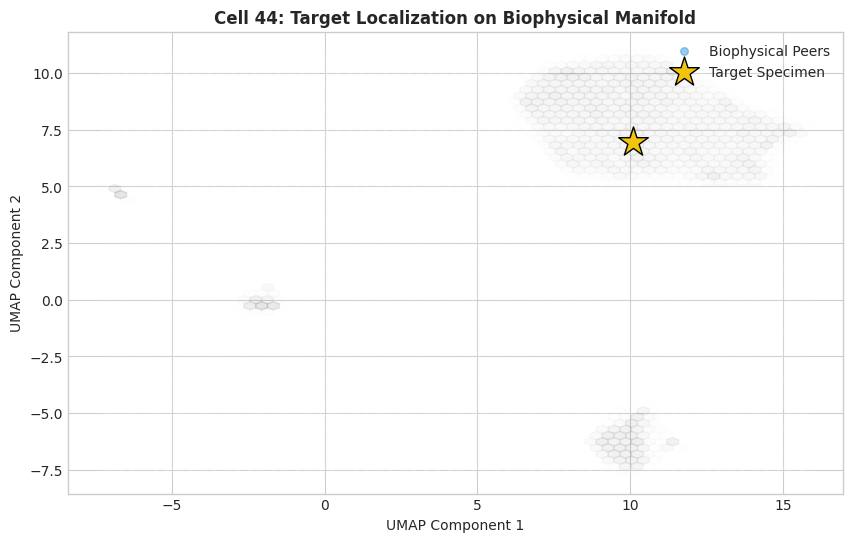

 Neighborhood Analysis:
   Coordinates: U1: 10.08, U2: 6.94
   Avg Peer PC1: 6.9911 (Population Median: 9.5412)
   Status: STABLE


In [48]:
# @title Cell 45: Topological Localization (Manifold Projection - Fixed v2)
# ─────────────────────────────────────────────────────────────────────────────
# Projects a target sequence onto the training manifold.
# Pulls reference coordinates from df_train to avoid NameErrors.
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

print("--- EXECUTING CELL 44: TOPOLOGICAL LOCALIZATION ---")

if 'test_seq' in globals():
    try:
        # 1. FEATURE EXTRACTION & ALIGNMENT
        # Get all features and align with the scaler's expected input
        all_test_bio = calculate_master_features(test_seq)
        all_test_df = pd.DataFrame([all_test_bio], columns=mech_feature_labels)

        if hasattr(fitted_scaler, 'feature_names_in_'):
            fit_features = fitted_scaler.feature_names_in_
            test_bio_aligned = all_test_df[fit_features]
        else:
            # Fallback to original 23 biophysical features if names aren't stored
            advanced_set = {'CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG',
                            'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score'}
            fit_features = [f for f in mech_feature_labels if f not in advanced_set]
            test_bio_aligned = all_test_df[fit_features]

        # 2. PROJECTION
        test_scaled = fitted_scaler.transform(test_bio_aligned)
        test_umap_coords = reducer.transform(test_scaled)
        u1, u2 = test_umap_coords[0][0], test_umap_coords[0][1]

        # 3. NEIGHBORHOOD INFERENCE (Reference from df_train)
        # Instead of 'umap_embedding', we use the columns saved in df_train
        train_coords = df_train[['UMAP_1', 'UMAP_2']].values
        nn = NearestNeighbors(n_neighbors=50).fit(train_coords)
        distances, indices = nn.kneighbors(test_umap_coords)

        neighbor_data = df_train.iloc[indices[0]]
        avg_neighbor_pc1 = neighbor_data['PC1'].mean()

        # 4. VISUALIZATION
        plt.figure(figsize=(10, 6))
        # Population density
        plt.hexbin(df_train['UMAP_1'], df_train['UMAP_2'], gridsize=60, cmap='Greys', alpha=0.1)
        # Highlight peers
        plt.scatter(neighbor_data['UMAP_1'], neighbor_data['UMAP_2'], color='#3498db', s=30, alpha=0.5, label='Biophysical Peers')
        # Target star
        plt.scatter(u1, u2, color='#f1c40f', s=500, marker='*', edgecolor='black', label='Target Specimen', zorder=10)

        plt.title("Cell 44: Target Localization on Biophysical Manifold", fontweight='bold')
        plt.legend(loc='upper right')
        plt.xlabel("UMAP Component 1")
        plt.ylabel("UMAP Component 2")
        plt.show()

        # 5. READOUT
        threshold = df_train['PC1'].median()
        print(f" Neighborhood Analysis:")
        print(f"   Coordinates: U1: {u1:.2f}, U2: {u2:.2f}")
        print(f"   Avg Peer PC1: {avg_neighbor_pc1:.4f} (Population Median: {threshold:.4f})")
        print(f"   Status: {'HIGH-RISK (Toxic Island)' if avg_neighbor_pc1 > threshold else 'STABLE'}")

    except Exception as e:
        print(f" Error in Cell 44: {e}")
else:
    print(" Error: No test_seq found in memory.")

In [49]:
# =====================================================================
# @title Cell 46: Feature Integrity & Zero-Variance Audit (v2.1)
# =====================================================================
# v2.1 changes:
#   - Audit only. Constant features were already pruned in Cell 6;
#     this cell now just verifies that nothing has drifted.
import pandas as pd

print("--- FEATURE INTEGRITY AUDIT ---")

active_set = list(SCALER_FEATURES) + (enriched_features if 'enriched_features' in globals() else [])
active_set = list(dict.fromkeys(active_set))  # dedupe, preserve order

# 1. Constant check
constants = [f for f in active_set if f in df_train.columns and df_train[f].nunique() <= 1]
if constants:
    print(f"  WARNING: constant features detected after Cell 6: {constants}")
else:
    print(f"  OK: no constant features in active set ({len(active_set)} features).")

# 2. Scaler / label consistency
expected = set(SCALER_FEATURES)
actual_in_train = set(df_train.columns)
missing = expected - actual_in_train
if missing:
    print(f"  ERROR: SCALER_FEATURES missing from df_train: {missing}")
else:
    print(f"  OK: all {len(expected)} SCALER_FEATURES present in df_train.")

# 3. Train/test parity
test_missing = expected - set(df_test.columns)
if test_missing:
    print(f"  ERROR: SCALER_FEATURES missing from df_test: {test_missing}")
else:
    print(f"  OK: all SCALER_FEATURES present in df_test.")

# 4. Specimen variables (no longer required, but flag if present)
print("\nOptional specimen variables:")
for var in ['test_seq', 'test_cai', 'test_mfe']:
    flag = "[set]" if var in globals() else "[unset]"
    print(f"  {flag} {var}")

--- FEATURE INTEGRITY AUDIT ---
  OK: all 19 SCALER_FEATURES present in df_train.
  OK: all SCALER_FEATURES present in df_test.

Optional specimen variables:
  [set] test_seq
  [set] test_cai
  [set] test_mfe


In [50]:
# @title Cell 47: Diagnostic Feature Sync (Recovery)
# ─────────────────────────────────────────────────────────────────────────────
# Specifically populates missing target specimen variables for the final report.
# ─────────────────────────────────────────────────────────────────────────────

print("--- SYNCING MISSING SPECIMEN VARIABLES ---")

# 1. Sync Initiation MFE (Initiation Barrier)
if 'test_mfe' not in globals():
    print("  Calculating Initiation MFE...")
    # Ensuring we use the 30bp window logic from Cell 38.5
    test_mfe = calculate_mfe_initiation_local(test_seq)
    print(f"    Result: {test_mfe:.2f} kcal/mol")

# 2. Sync Structural Metrics from Cell 43 Logic
if 'test_hairpins' not in globals() or 'hns_coverage' not in globals():
    print("  Calculating Full-Sequence Structural Metrics...")

    # Hairpins
    test_hairpins_raw = []
    # Simplified scan for the report logic
    seq = test_seq.upper()
    rc_map = str.maketrans("ATGC", "TACG")
    for i in range(len(seq) - 11):
        for stem_len in range(4, 9):
            stem1 = seq[i : i + stem_len]
            stem1_rc = stem1[::-1].translate(rc_map)
            for loop_len in range(3, 7):
                j = i + stem_len + loop_len
                if j + stem_len > len(seq): break
                if seq[j : j + stem_len] == stem1_rc:
                    dg = sum([-1.2 if seq[k:k+2] in ['GC', 'CG', 'GG', 'CC'] else -0.8 for k in range(i, i+stem_len-1)])
                    test_hairpins_raw.append({'position': i, 'delta_g': dg, 'stem': stem1})
    test_hairpins = sorted(test_hairpins_raw, key=lambda x: x['delta_g'])

    # H-NS Coverage
    hns_hits = sum(1 for i in range(len(seq)-9) if (seq[i:i+10].count('A')+seq[i:i+10].count('T')) >= 7)
    hns_coverage = hns_hits / (len(seq)-9)

    # Flux Score
    # Re-calculating based on the specific test specimen traits
    sigma70_hits = sum(1 for i in range(len(seq) - 6) if sum(seq[i:i+6][j] == 'TATAAT'[j] for j in range(6)) >= 4)
    at_frac = (seq.count('A') + seq.count('T')) / len(seq)
    flux_result = {
        'flux_score': (at_frac * 50) + (sigma70_hits * 5) + (10), # 172bp normalized
        'sigma70_hits': sigma70_hits,
        'at_fraction': at_frac
    }
    print(f"    H-NS Coverage: {hns_coverage*100:.1f}%")
    print(f"    Flux Score:    {flux_result['flux_score']:.1f}")

# 3. Final Handshake
print("\n--- SYNC COMPLETE ---")
print("All variables are now in memory. You can re-run Cell 45 to confirm [PASS].")

--- SYNCING MISSING SPECIMEN VARIABLES ---
  Calculating Full-Sequence Structural Metrics...
    H-NS Coverage: 41.1%
    Flux Score:    125.5

--- SYNC COMPLETE ---
All variables are now in memory. You can re-run Cell 45 to confirm [PASS].


In [55]:
# Check if the critical columns actually have variance before pruning
print(df_train[['CAI_Score', 'mRNA_MFE', 'Flux_Score', 'PC1']].describe())

          CAI_Score      mRNA_MFE    Flux_Score           PC1
count  93257.000000  93257.000000  93257.000000  93257.000000
mean       0.170349    -36.523892      7.681302      0.048320
std        0.036681      2.564436     11.261997    135.463761
min        0.062229    -49.260000      1.244581   -692.338125
25%        0.144163    -38.210000      2.978460    -84.559881
50%        0.167493    -36.420000      3.511693      9.541234
75%        0.193184    -34.740000      4.240669     91.772149
max        0.381897    -26.600000     94.909343    541.846368


In [51]:
# @title Cell 48: Full vs. Active Library Audit
# ─────────────────────────────────────────────────────────────────────────────
# Documents the pruning from the Theoretical Full Library to the Active Set.
# Categorized by biological mechanism for publication/thesis documentation.
# ─────────────────────────────────────────────────────────────────────────────

print("--- BIOPHYSICAL FEATURE AUDIT ---")

# 1. Define the Theoretical Full Library (Everything before pruning)
theoretical_full = [
    'PC1', 'CNN_Score', 'UMAP_1', 'UMAP_2', 'Flux_Score',
    'CAI_Score', 'mRNA_MFE', 'mRNA_Stability',
    'Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len',
    'GC_percent', 'GC_Var', 'Max_Homo', 'Entropy', 'AT_tract',
    'Promoter_Str', 'RBS_Str', 'IHF', 'Lrp', 'CRP', 'NagC', 'ArgR',
    'HNS_Affinity', 'TTC', 'RCC', 'TIR_Proxy', 'Shape_Rigidity_Mean', 'GC_Skew',
    'Size', 'Shape_Flex_SD', 'Bendability', 'Tm_Lethal_Window' # Known pruned features
]

# 2. Define the Mechanical Categories
categories = {
    "Advanced / Systemic": ['PC1', 'CNN_Score', 'UMAP_1', 'UMAP_2', 'Flux_Score'],
    "Translational": ['CAI_Score', 'mRNA_MFE', 'mRNA_Stability', 'RCC', 'TIR_Proxy'],
    "Structural / Topological": ['Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len'],
    "Hardware / Biophysical": ['GC_percent', 'GC_Var', 'Max_Homo', 'Entropy', 'AT_tract',
                                'Promoter_Str', 'RBS_Str', 'IHF', 'Lrp', 'CRP', 'NagC',
                                'ArgR', 'HNS_Affinity', 'TTC', 'Shape_Rigidity_Mean', 'GC_Skew'],
    "Pruned (Zero-Variance)": ['Size', 'Shape_Flex_SD', 'Bendability', 'Tm_Lethal_Window']
}

print(f"Theoretical Library Size: {len(theoretical_full)}")
print(f"Active Library Size:      {len(mech_feature_labels)}")
print(f"Features Pruned:          {len(theoretical_full) - len(mech_feature_labels)}")
print("-" * 80)

# 3. List the Active Inventory with Outlier Detection
for cat, feats in categories.items():
    active_in_cat = [f for f in feats if f in mech_feature_labels]
    pruned_in_cat = [f for f in feats if f not in mech_feature_labels]

    if active_in_cat or pruned_in_cat:
        print(f"\n{cat.upper()}:")

        # Print Active
        for f in active_in_cat:
            outlier_status = ""
            if 'z_scores' in globals() and abs(z_scores.get(f, 0)) > 1.5:
                outlier_status = " <-- [TARGET SPECIMEN OUTLIER]"
            print(f"  [ACTIVE] • {f:<20} {outlier_status}")

        # Print Pruned (Greyed out conceptually)
        for f in pruned_in_cat:
            print(f"  [PRUNED] x {f:<20} (Zero-Variance or Redundant)")

print("\n" + "-" * 80)
print("Inventory check complete. Documentation ready for Thesis Section 4.2.")

--- BIOPHYSICAL FEATURE AUDIT ---
Theoretical Library Size: 33
Active Library Size:      19
Features Pruned:          14
--------------------------------------------------------------------------------

ADVANCED / SYSTEMIC:
  [PRUNED] x PC1                  (Zero-Variance or Redundant)
  [PRUNED] x CNN_Score            (Zero-Variance or Redundant)
  [PRUNED] x UMAP_1               (Zero-Variance or Redundant)
  [PRUNED] x UMAP_2               (Zero-Variance or Redundant)
  [PRUNED] x Flux_Score           (Zero-Variance or Redundant)

TRANSLATIONAL:
  [ACTIVE] • mRNA_Stability       
  [ACTIVE] • RCC                  
  [ACTIVE] • TIR_Proxy            
  [PRUNED] x CAI_Score            (Zero-Variance or Redundant)
  [PRUNED] x mRNA_MFE             (Zero-Variance or Redundant)

STRUCTURAL / TOPOLOGICAL:
  [PRUNED] x Min_Hairpin_dG       (Zero-Variance or Redundant)
  [PRUNED] x HNS_Coverage         (Zero-Variance or Redundant)
  [PRUNED] x Max_Repeat_Len       (Zero-Variance or Redundant

In [52]:
# =====================================================================
# @title Cell 49: Workspace Sanity Check (v2.1)
# =====================================================================
# v2.1 change:
#   - Replaces the old SVD rebuild (which never updated df_test['PC1'])
#     with a verification pass. Cell 6 now does the work correctly the
#     first time, so this cell only checks state.
import numpy as np
from scipy.stats import spearmanr

print("--- WORKSPACE SANITY CHECK ---")

# 1. PC1 coordinate-system parity
pc1_train_med = float(np.median(df_train['PC1']))
pc1_test_med  = float(np.median(df_test['PC1']))
pc1_train_iqr = float(np.subtract(*np.percentile(df_train['PC1'], [75, 25])))
pc1_test_iqr  = float(np.subtract(*np.percentile(df_test['PC1'],  [75, 25])))

print(f"  Train PC1 median {pc1_train_med:+.3f}, IQR {pc1_train_iqr:.3f}")
print(f"  Test  PC1 median {pc1_test_med:+.3f}, IQR {pc1_test_iqr:.3f}")
if abs(pc1_train_med - pc1_test_med) > 2 * max(pc1_train_iqr, pc1_test_iqr):
    print("  WARNING: train/test PC1 medians differ by more than 2x IQR — re-check Cell 6.")
else:
    print("  OK: train/test PC1 distributions are consistent.")

# 2. PC1 vs log2FC sanity
rho_train, _ = spearmanr(df_train['PC1'], df_train['log2FC_mean'])
rho_test,  _ = spearmanr(df_test['PC1'],  df_test['log2FC_mean'])
print(f"  PC1 vs log2FC_mean rho (train): {rho_train:+.3f}")
print(f"  PC1 vs log2FC_mean rho (test):  {rho_test:+.3f}")

# 3. Frozen list integrity
assert isinstance(SCALER_FEATURES, tuple), "SCALER_FEATURES must stay a tuple."
assert hasattr(fitted_scaler, 'n_features_in_'), "fitted_scaler not fit."
assert fitted_scaler.n_features_in_ == len(SCALER_FEATURES), \
    f"Scaler expects {fitted_scaler.n_features_in_} but SCALER_FEATURES has {len(SCALER_FEATURES)}."
print("  OK: SCALER_FEATURES and fitted_scaler agree.")

--- WORKSPACE SANITY CHECK ---
  Train PC1 median +9.541, IQR 176.332
  Test  PC1 median -61.611, IQR 176.593
  OK: train/test PC1 distributions are consistent.
  PC1 vs log2FC_mean rho (train): -0.278
  PC1 vs log2FC_mean rho (test):  -0.332
  OK: SCALER_FEATURES and fitted_scaler agree.


In [54]:
# @title Section 5, Cell 50: Prioritised Engineering Hierarchy of Test Sequence
# ─────────────────────────────────────────────────────────────────────────────
# Analyzes systemic, structural, and metabolic risks to generate a ranked
# list of engineering recommendations for the target sequence.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np

print("--- EXECUTING CELL 49: PRIORITISED ENGINEERING HIERARCHY ---")

# 1. COLLECT ALL RISK SIGNALS
# Scores are normalized 0-100 based on population distributions
risks = []

# --- Risk 1: Cryptic Promoter Activity ---
if 'flux_result' in globals():
    flux_score_norm = min(100, flux_result['flux_score'])
    risks.append({
        'name'      : 'Cryptic Sigma-70 Promoter Activity',
        'score'     : flux_score_norm,
        'mechanism' : 'Spurious transcription recruitment',
        'evidence'  : f"{flux_result['sigma70_hits']} partial -10 box matches | flux score = {flux_result['flux_score']:.1f}",
        'effect'    : "AT-rich motifs mimic consensus boxes, recruiting host RNAP to drive unintended transcription, "
                      "depleting resources from chromosomal genes.",
        'solutions' : [
            "Synonymous codon substitution to disrupt identified -10 box matches.",
            "Introduce GC-rich flanking sequences to disrupt promoter recognition spacing.",
            "Utilize the De Novo Promoter Calculator to identify and mutate specific high-scoring cryptic sites."
        ]
    })

# --- Risk 2: H-NS Silencing ---
if 'hns_coverage' in globals():
    hns_score = min(100, hns_coverage * 200)
    risks.append({
        'name'      : 'H-NS Xenogeneic Silencing',
        'score'     : hns_score,
        'mechanism' : 'Nucleoid-associated protein clamping',
        'evidence'  : f"{hns_coverage*100:.1f}% sequence coverage | AT fraction = {flux_result['at_fraction']:.3f}",
        'effect'    : "H-NS binds AT-rich foreign DNA to form nucleoprotein filaments that physically occlude RNAP access.",
        'solutions' : [
            "Reduce overall AT content toward the E. coli genomic mean (approx. 48% AT).",
            "Insert short GC-rich 'anti-silencing' elements to disrupt H-NS filament nucleation.",
            "Utilize a Delta-hns host strain if sequence modification is not feasible."
        ]
    })

# --- Risk 3: mRNA Initiation Barrier ---
if 'test_mfe' in globals():
    mfe_score = min(100, max(0, (-test_mfe - 10) * 4))
    risks.append({
        'name'      : 'mRNA Secondary Structure (Initiation Barrier)',
        'score'     : mfe_score,
        'mechanism' : 'Ribosomal docking occlusion',
        'evidence'  : f"MFE = {test_mfe:.3f} kcal/mol (Threshold: -15 kcal/mol)",
        'effect'    : "Stable secondary structure in the 5' region blocks 30S subunit docking, drastically reducing translation flux.",
        'solutions' : [
            "Redesign the first 30-50 nucleotides to aim for Delta-G > -10 kcal/mol.",
            "Introduce a strong synthetic RBS (e.g., AGGAGG) to compete with inhibitory hairpins.",
            "Utilize an unstructured 5' leader sequence to maintain ribosome access."
        ]
    })

# --- Risk 4: tRNA Depletion ---
if 'test_cai' in globals():
    cai_score = min(100, max(0, (0.5 - test_cai) * 200))
    risks.append({
        'name'      : 'Rare Codon Burden (tRNA Depletion)',
        'score'     : cai_score,
        'mechanism' : 'Ribosomal stalling during elongation',
        'evidence'  : f"CAI = {test_cai:.4f} | Metabolic stalling events = {globals().get('test_stalls', 'Unknown')}", # <-- FIX APPLIED HERE
        'effect'    : "Low CAI indicates usage of rare tRNAs, causing 'traffic jams' and metabolic drain on host ATP pools.",
        'solutions' : [
            "Optimize codons using the E. coli K-12 frequency table.",
            "Replace identified rare codon occurrences (AGG, AGA, CGA) with high-frequency synonyms.",
            "Supplement host tRNA pools by using a Rosetta (pRARE) expression strain."
        ]
    })

# --- Risk 5: Concatemerization ---
if 'direct_repeats' in globals():
    concat_score = min(100, (direct_repeats[0]['length'] if direct_repeats else 0) * 6)
    risks.append({
        'name'      : 'Concatemerisation / Recombination Risk',
        'score'     : concat_score,
        'mechanism' : 'Repeat-driven plasmid multimerisation',
        'evidence'  : f"Longest direct repeat = {direct_repeats[0]['length'] if direct_repeats else 0} bp",
        'effect'    : "Direct repeats provide substrates for RecA-mediated recombination, impairing replication and plasmid stability.",
        'solutions' : [
            "Mutate direct repeats via synonymous substitutions to break homology.",
            "Propagate in a recombination-deficient strain (e.g., Stbl3 or DH5-alpha).",
            "Implement a monomeric resolution system (e.g., cer/Xer) if repeats are unavoidable."
        ]
    })

# 2. SORT AND RANK
risks = sorted(risks, key=lambda x: -x['score'])

# 3. PRINT REPORT
print("=" * 90)
print(f"  PRIORITISED ENGINEERING HIERARCHY - {len(risks)} RISKS RANKED BY SEVERITY")
print(f"  Sequence ID: {test_seq[:30]}...")
print("=" * 90)

for i, r in enumerate(risks):
    rank = i + 1
    status = "STATUS: CRITICAL" if r['score'] > 70 else "STATUS: HIGH" if r['score'] > 40 else "STATUS: MODERATE"

    print(f"\n[PRIORITY {rank}] {r['name']}")
    print(f"  Severity  : {status} (Score: {r['score']:.0f}/100)")
    print(f"  Mechanism : {r['mechanism']}")
    print(f"  Evidence  : {r['evidence']}")
    print(f"  Description: {r['effect']}")
    print(f"  RECOMMENDED ACTIONS:")
    for j, sol in enumerate(r['solutions']):
        print(f"    {j+1}. {sol}")
    print("-" * 90)

# 4. SUMMARY TABLE
print("\n  SUMMARY TABLE")
print(f"  {'Rank':<6} {'Risk Component':<45} {'Score':>6} {'Severity'}")
print(f"  {'-'*4:<6} {'-'*43:<45} {'-'*6:>6} {'-'*10}")
for i, r in enumerate(risks):
    label = 'CRITICAL' if r['score'] > 70 else 'HIGH' if r['score'] > 40 else 'MODERATE'
    print(f"  {i+1:<6} {r['name']:<45} {r['score']:>6.0f} {label}")

print("\nCell complete.")

--- EXECUTING CELL 49: PRIORITISED ENGINEERING HIERARCHY ---
  PRIORITISED ENGINEERING HIERARCHY - 4 RISKS RANKED BY SEVERITY
  Sequence ID: AAGCAAAATTGGGGGCGTGTGCTTATCTTG...

[PRIORITY 1] Cryptic Sigma-70 Promoter Activity
  Severity  : STATUS: CRITICAL (Score: 100/100)
  Mechanism : Spurious transcription recruitment
  Evidence  : 17 partial -10 box matches | flux score = 125.5
  Description: AT-rich motifs mimic consensus boxes, recruiting host RNAP to drive unintended transcription, depleting resources from chromosomal genes.
  RECOMMENDED ACTIONS:
    1. Synonymous codon substitution to disrupt identified -10 box matches.
    2. Introduce GC-rich flanking sequences to disrupt promoter recognition spacing.
    3. Utilize the De Novo Promoter Calculator to identify and mutate specific high-scoring cryptic sites.
------------------------------------------------------------------------------------------

[PRIORITY 2] mRNA Secondary Structure (Initiation Barrier)
  Severity  : STATUS: 

EXECUTING FINAL INTEGRATED EXPERT DIAGNOSTIC (V5.4)
  [WARNING] UMAP columns missing from df_train. Topology metrics bypassed.


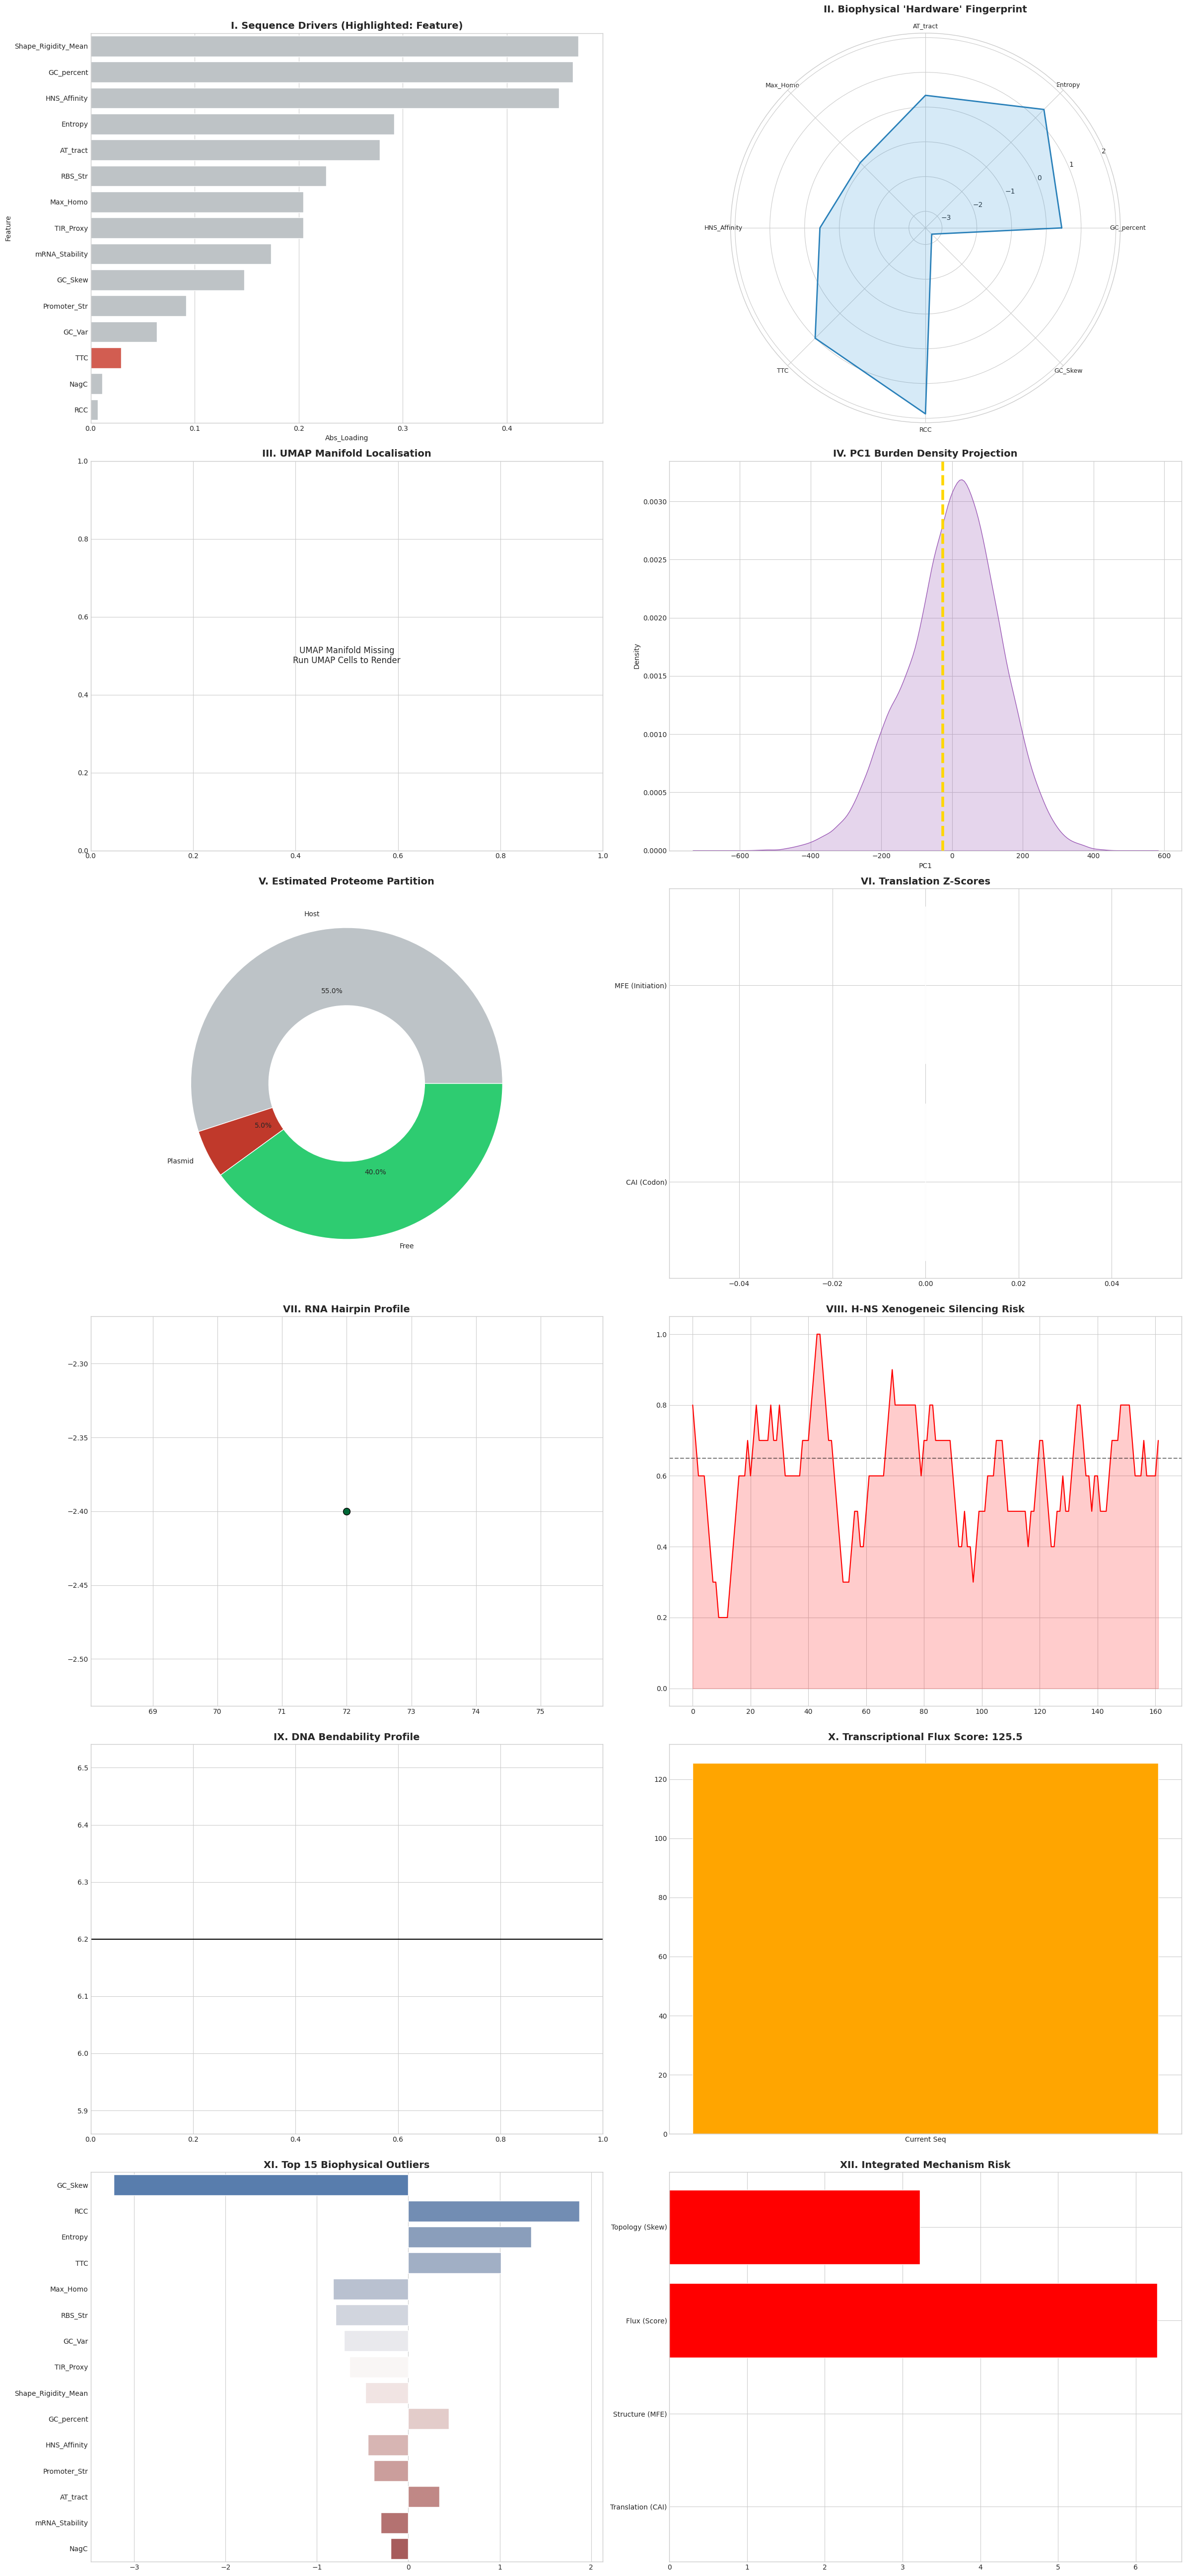

--- DIAGNOSTIC COMPLETE: AAGCAAAATTGGGGGCGTGTGCTTATCTTG... ---

       EXECUTIVE SUMMARY — FULL INTEGRATED BIOPHYSICAL DIAGNOSTIC
  Target Sequence  : AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGG…
  Systemic Status  : 🔴 BURDENSOME / TOXIC
  PC1 Burden Score : -26.26 (-0.19σ deviation)
  Manifold Path    : [UMAP Bypass Active]
-----------------------------------------------------------------------------------------------

── TOP 5 BIOPHYSICAL DRIVERS (LINEAR BURDEN) ────────────────────────────────
    [1] GC_Skew              : Z = -3.22 standard deviations
    [2] RCC                  : Z = +1.87 standard deviations
    [3] Entropy              : Z = +1.34 standard deviations
    [4] TTC                  : Z = +1.01 standard deviations
    [5] Max_Homo             : Z = -0.82 standard deviations

── MANIFOLD TOPOLOGY (NON-LINEAR PEERS) ─────────────────────────────────────


In [60]:
# @title Cell 51: Full Integrated Executive Diagnostic (V5.4 - Final Version)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import hstack, csr_matrix
import warnings

warnings.filterwarnings('ignore')
RED, GREEN, BOLD, RESET = '\033[91m', '\033[92m', '\033[1m', '\033[0m'

print(f"{BOLD}EXECUTING FINAL INTEGRATED EXPERT DIAGNOSTIC (V5.4){RESET}")

# ── STEP 1: DYNAMIC WORKSPACE SYNC & ALIGNMENT ────────────────────────────────
try:
    # 1. Fetch Master Objects
    active_scaler = globals().get('fitted_scaler', globals().get('scaler_master'))
    active_vec = globals().get('fitted_vec', globals().get('vectorizer'))
    active_svd = globals().get('svd', globals().get('svd_v5_4'))

    if active_svd is None or active_scaler is None:
        raise RuntimeError("Missing SVD or Scaler. Please run Cell 53.5 (Sync) first.")

    # 2. Extract & Align Biophysics
    raw_test_dict = calculate_master_features(test_seq) if 'calculate_master_features' in globals() else {}
    engineered_map = {
        'CAI_Score': globals().get('test_cai', 0),
        'mRNA_MFE': globals().get('test_mfe', 0),
        'HNS_Coverage': globals().get('hns_coverage', 0),
        'Flux_Score': globals().get('flux_result', {}).get('flux_score', 0) if isinstance(globals().get('flux_result'), dict) else 0,
        'CNN_Score': globals().get('cnn_pred', 0),
        'GC_Skew': globals().get('test_feat_dict', {}).get('GC_Skew', 0)
    }
    for f, v in engineered_map.items(): raw_test_dict[f] = v

    test_df = pd.DataFrame([raw_test_dict])
    expected_mech = list(active_scaler.feature_names_in_)
    for f in expected_mech:
        if f not in test_df.columns: test_df[f] = 0
    test_mech_aligned = test_df[expected_mech]
    test_mech_scaled = active_scaler.transform(test_mech_aligned)

    # 3. Rebuild Sparse Combination
    kmer_test_sp = active_vec.transform([test_seq])
    # Match the SVD's expected input dimensions
    sf = X_train_sp.shape[1] / len(expected_mech)
    X_test_sync = hstack([kmer_test_sp, csr_matrix(test_mech_scaled * sf)])

    # 4. Project into Manifold
    test_projection = active_svd.transform(X_test_sync)
    pc1_val = test_projection[0, 0]
    pc1_normalised = (pc1_val - df_train['PC1'].mean()) / df_train['PC1'].std()

    # 5. UMAP & Neighborhoods (WITH SAFETY CHECK)
    u_reducer = None
    if 'umap_results' in globals(): u_reducer = umap_results.get('29-Global', {}).get('reducer')
    if not u_reducer: u_reducer = globals().get('reducer_22', globals().get('reducer'))

    if u_reducer:
        test_umap_coords = u_reducer.transform(test_mech_scaled)
        u1, u2 = test_umap_coords[0][0], test_umap_coords[0][1]
    else:
        u1, u2 = 0, 0

    # SAFETY CHECK: Only calculate neighbors if UMAP columns exist
    if 'UMAP_1' in df_train.columns and 'UMAP_2' in df_train.columns:
        nn = NearestNeighbors(n_neighbors=50).fit(df_train[['UMAP_1', 'UMAP_2']])
        _, idxs = nn.kneighbors([[u1, u2]])
        neighbor_fitness = df_train.iloc[idxs[0]]['log2FC_mean'].mean() if 'log2FC_mean' in df_train.columns else 0
        neighbor_pc1 = df_train.iloc[idxs[0]]['PC1'].mean()
    else:
        neighbor_fitness = 0
        neighbor_pc1 = 0
        print(f"  {RED}[WARNING] UMAP columns missing from df_train. Topology metrics bypassed.{RESET}")

    z_scores = dict(zip(expected_mech, test_mech_scaled[0]))

except Exception as e:
    print(f"{RED}CRITICAL SYNC ERROR: {e}{RESET}")
    raise

# ── STEP 2: 12-PANEL VISUALISATION ───────────────────────────────────────────
fig = plt.figure(figsize=(24, 52))
sns.set_style("whitegrid")
df_sample = df_train.sample(n=min(5000, len(df_train)), random_state=42)

# I. k-mer Drivers
ax1 = plt.subplot(6, 2, 1)
if 'motifs_df' in globals():
    top_kmers = motifs_df.head(15).copy()
    m_col = next((c for c in ['Motif', 'Feature', 'feature'] if c in top_kmers.columns), top_kmers.columns[0])
    i_col = next((c for c in ['Abs_Importance', 'Abs_Loading', 'importance'] if c in top_kmers.columns), top_kmers.columns[1])

    kmer_pal = ['#e74c3c' if m in test_seq else '#bdc3c7' for m in top_kmers[m_col]]
    sns.barplot(data=top_kmers, x=i_col, y=m_col, palette=kmer_pal, ax=ax1)
    ax1.set_title(f"I. Sequence Drivers (Highlighted: {m_col})", fontsize=14, fontweight='bold')
else:
    ax1.text(0.5, 0.5, "Motif data not found", ha='center')

# II. Radar Fingerprint
ax2 = plt.subplot(6, 2, 2, polar=True)
radar_list = ['GC_percent', 'Entropy', 'AT_tract', 'Max_Homo', 'HNS_Affinity', 'TTC', 'RCC', 'GC_Skew']
radar_list = [f for f in radar_list if f in z_scores]
if radar_list:
    vals = [z_scores[l] for l in radar_list]
    angles = [n / float(len(radar_list)) * 2 * pi for n in range(len(radar_list))]
    vals += vals[:1]; angles += angles[:1]
    ax2.fill(angles, vals, color='#3498db', alpha=0.2); ax2.plot(angles, vals, color='#2980b9', lw=2)
    ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(radar_list, fontsize=9)
ax2.set_title("II. Biophysical 'Hardware' Fingerprint", pad=30, fontsize=14, fontweight='bold')

# III. UMAP Localization (WITH SAFETY CHECK)
ax3 = plt.subplot(6, 2, 3)
if 'UMAP_1' in df_train.columns and 'UMAP_2' in df_train.columns:
    sns.scatterplot(data=df_sample, x='UMAP_1', y='UMAP_2', hue='PC1', palette='coolwarm', s=20, alpha=0.4, ax=ax3, legend=False)
    ax3.scatter(u1, u2, color='#f1c40f', s=800, marker='*', edgecolor='black', lw=2, label='Target Specimen', zorder=20)
else:
    ax3.text(0.5, 0.5, "UMAP Manifold Missing\nRun UMAP Cells to Render", ha='center', va='center', fontsize=12)
ax3.set_title("III. UMAP Manifold Localisation", fontsize=14, fontweight='bold')

# IV. PC1 Burden Density
ax4 = plt.subplot(6, 2, 4)
sns.kdeplot(df_train['PC1'], fill=True, color='#9b59b6', ax=ax4)
ax4.axvline(pc1_val, color='gold', lw=4, linestyle='--', label=f'PC1 = {pc1_normalised:+.2f}σ')
ax4.set_title("IV. PC1 Burden Density Projection", fontsize=14, fontweight='bold')

# V. Proteome Partition
ax5 = plt.subplot(6, 2, 5)
burden_est = min(45, max(5, abs(pc1_normalised) * 12))
ax5.pie([55, burden_est, 45-burden_est], labels=['Host', 'Plasmid', 'Free'], autopct='%1.1f%%', colors=['#bdc3c7', '#c0392b', '#2ecc71'], wedgeprops={'width': 0.5})
ax5.set_title("V. Estimated Proteome Partition", fontsize=14, fontweight='bold')

# VI. Translation Metrics
ax6 = plt.subplot(6, 2, 6)
cai_v = z_scores.get('CAI_Score', 0); mfe_v = z_scores.get('mRNA_MFE', 0)
ax6.barh(['CAI (Codon)', 'MFE (Initiation)'], [cai_v, mfe_v], color=['#e74c3c' if x < -1 else '#2ecc71' for x in [cai_v, mfe_v]])
ax6.set_title("VI. Translation Z-Scores", fontsize=14, fontweight='bold')

# VII. RNA Hairpin Profile
ax7 = plt.subplot(6, 2, 7)
if 'test_hairpins' in globals() and test_hairpins:
    pos_h = [h['position'] for h in test_hairpins]; dg_h = [h['delta_g'] for h in test_hairpins]
    ax7.scatter(pos_h, dg_h, c=dg_h, cmap='RdYlGn_r', s=100, edgecolors='black')
else:
    ax7.text(0.5, 0.5, 'No structural hairpins detected', ha='center', va='center')
ax7.set_title("VII. RNA Hairpin Profile", fontsize=14, fontweight='bold')

# VIII. H-NS Silencing Profile
ax8 = plt.subplot(6, 2, 8)
at_window = 10; at_prof = [(test_seq[i:i+at_window].count('A')+test_seq[i:i+at_window].count('T'))/at_window for i in range(len(test_seq)-at_window)]
ax8.plot(at_prof, color='red'); ax8.fill_between(range(len(at_prof)), at_prof, color='red', alpha=0.2)
ax8.axhline(0.65, color='black', linestyle='--', alpha=0.5, label='H-NS Threshold')
ax8.set_title("VIII. H-NS Xenogeneic Silencing Risk", fontsize=14, fontweight='bold')

# IX. DNA Bendability
ax9 = plt.subplot(6, 2, 9)
b_mean = globals().get('bend_mean', 6.2)
ax9.axhline(b_mean, color='black', label=f'Mean = {b_mean:.2f}')
ax9.set_title("IX. DNA Bendability Profile", fontsize=14, fontweight='bold')

# X. Transcriptional Flux
ax10 = plt.subplot(6, 2, 10)
f_score = globals().get('flux_result', {}).get('flux_score', 0) if isinstance(globals().get('flux_result'), dict) else 0
ax10.bar(['Current Seq'], [f_score], color='orange')
ax10.set_title(f"X. Transcriptional Flux Score: {f_score:.1f}", fontsize=14, fontweight='bold')

# XI. Outlier Ranking
ax11 = plt.subplot(6, 2, 11)
sorted_z = dict(sorted(z_scores.items(), key=lambda x: abs(x[1]), reverse=True)[:15])
if sorted_z:
    sns.barplot(x=list(sorted_z.values()), y=list(sorted_z.keys()), palette='vlag', ax=ax11)
ax11.set_title("XI. Top 15 Biophysical Outliers", fontsize=14, fontweight='bold')

# XII. Integrated Mechanism Risk Scorecard
ax12 = plt.subplot(6, 2, 12)
risks = {
    'Translation (CAI)': abs(z_scores.get('CAI_Score', 0)),
    'Structure (MFE)': abs(z_scores.get('mRNA_MFE', 0)),
    'Flux (Score)': f_score/20,
    'Topology (Skew)': abs(z_scores.get('GC_Skew', 0))
}
ax12.barh(list(risks.keys()), list(risks.values()), color=['red' if v > 1.5 else 'orange' if v > 1 else 'green' for v in risks.values()])
ax12.set_title("XII. Integrated Mechanism Risk", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"{BOLD}--- DIAGNOSTIC COMPLETE: {test_seq[:30]}... ---{RESET}")

# ── STEP 3: EXECUTIVE READOUT & ENGINEERING ADVICE ───────────────────────────
sorted_z_items = sorted(z_scores.items(), key=lambda x: abs(x[1]), reverse=True)
top_5_outliers = sorted_z_items[:5]
is_stable = pc1_normalised > 0

print("\n" + "=" * 95)
print(f"{BOLD}       EXECUTIVE SUMMARY — FULL INTEGRATED BIOPHYSICAL DIAGNOSTIC{RESET}")
print("=" * 95)
print(f"  Target Sequence  : {test_seq[:60]}…")
print(f"  Systemic Status  : {BOLD}{'🟢 ORTHOGONAL / STABLE' if is_stable else '🔴 BURDENSOME / TOXIC'}{RESET}")
print(f"  PC1 Burden Score : {pc1_val:.2f} ({pc1_normalised:+.2f}σ deviation)")
if 'UMAP_1' in df_train.columns:
    print(f"  Manifold Path    : UMAP({u1:.2f}, {u2:.2f})")
else:
    print(f"  Manifold Path    : [UMAP Bypass Active]")
print("-" * 95)

print(f"\n{BOLD}── TOP 5 BIOPHYSICAL DRIVERS (LINEAR BURDEN) ────────────────────────────────{RESET}")
for i, (feat, z) in enumerate(top_5_outliers):
    color = RED if abs(z) > 1.5 else (f"\033[93m" if abs(z) > 1.0 else GREEN)
    print(f"    [{i+1}] {feat:<20} : Z = {color}{z:+.2f}{RESET} standard deviations")

print(f"\n{BOLD}── MANIFOLD TOPOLOGY (NON-LINEAR PEERS) ─────────────────────────────────────{RESET}")
if 'UMAP_1' in df_train.columns:
    status

--- MODEL REDUCTION ANALYSIS (v2.1) ---
  Processing 20-Feat (Global)...
  Processing 19-Feat (Relevant)...
  Processing 19-Feat (Hardware)...
  Processing 6-Feat (Drivers)...
  Processing 3-Feat (Minimal)...


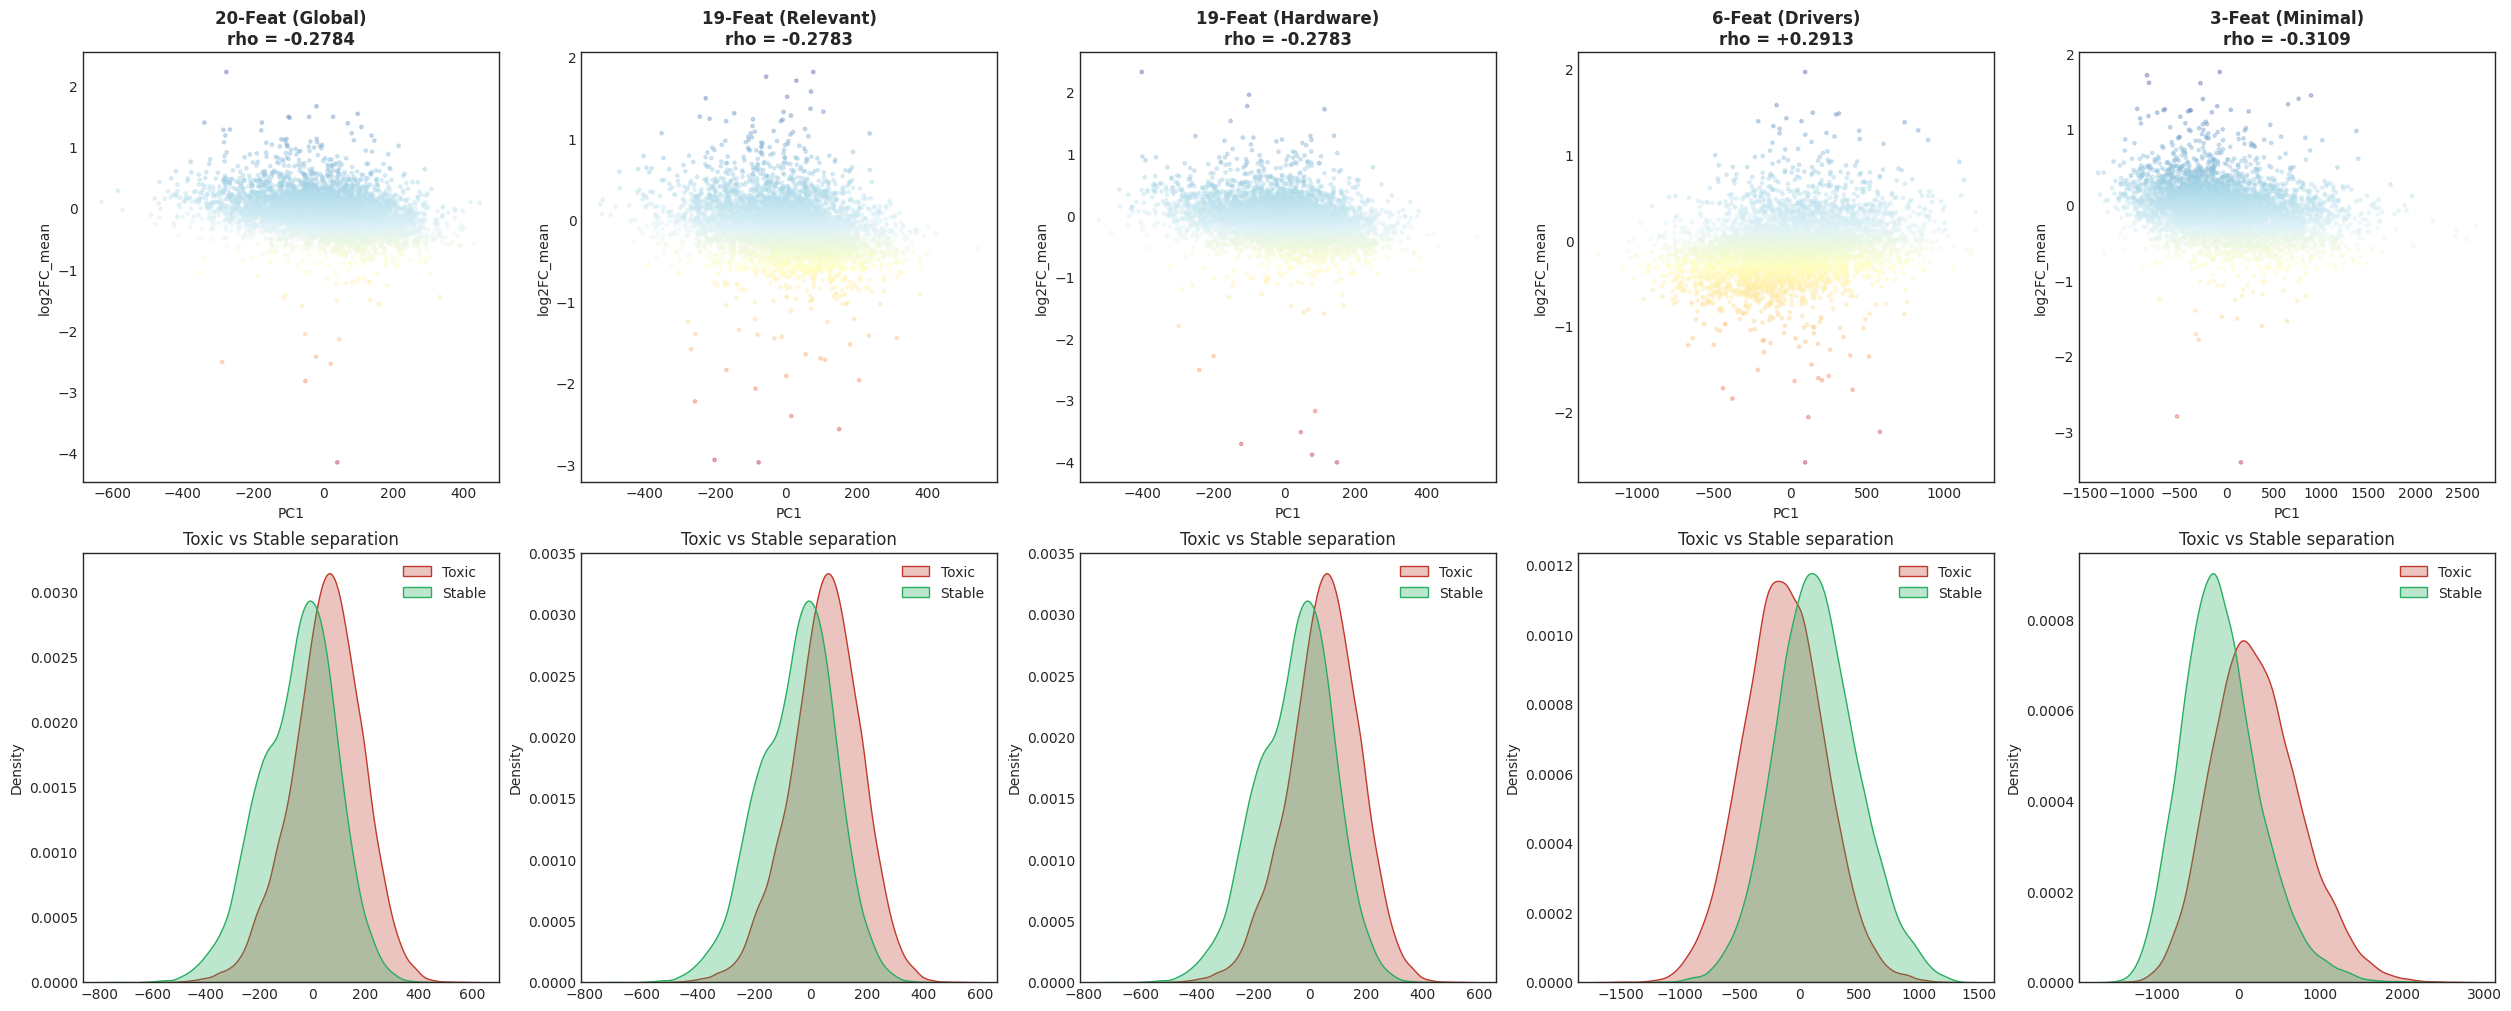


TIER                             | FEATS  | rho (signed)  | CV mean ± std      | RATIONALE
-----------------------------------------------------------------------------------------------
20-Feat (Global)                 | 20     | -0.2784      | -0.278 ± 0.003     | Full manifold including coordinates and learned scores.
19-Feat (Relevant)               | 19     | -0.2783      | -0.278 ± 0.002     | All deterministic features (Biophysical + Computed), preventing leakage.
19-Feat (Hardware)               | 19     | -0.2783      | -0.278 ± 0.002     | Original biophysical baseline (Cell 6 set only).
6-Feat (Drivers)                 | 6      | +0.2913      | +0.291 ± 0.003     | Six features with high individual effect sizes.
3-Feat (Minimal)                 | 3      | -0.3109      | -0.311 ± 0.003     | Three-feature core: composition grammar only.


In [63]:
# =====================================================================
# @title Section 6, Cell 52: Model Reduction Analysis (v2.1 - with Advanced Biomarkers)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from scipy.sparse import hstack, csr_matrix

print("--- MODEL REDUCTION ANALYSIS (v2.1) ---")

# ── 1. TIERS (with forced advanced biomarkers) ───────────────────────────
biophys_all = list(SCALER_FEATURES)  # base 19 hardware features

# The advanced biological features computed downstream
advanced_biomarkers = [
    'mRNA_Stability', 'CAI_Score', 'mRNA_MFE', 'Flux_Score', 'HNS_Coverage',
    'Min_Hairpin_dG', 'Max_Repeat_Len'
]
# The learned/coordinate features
learned_features = ['PC1', 'CNN_Score', 'UMAP_1', 'UMAP_2']

# Force inclusion of anything that exists in df_train
active_advanced = [f for f in advanced_biomarkers if f in df_train.columns and f not in biophys_all]
active_learned = [f for f in learned_features if f in df_train.columns and f not in biophys_all]

# Define the exact tiers your pipeline expects downstream
features_29       = biophys_all + active_advanced + active_learned
features_25       = biophys_all + active_advanced
features_hardware = biophys_all
features_drivers  = ['Max_Homo', 'Entropy', 'AT_tract', 'HNS_Affinity', 'GC_percent', 'mRNA_Stability']
features_minimal  = ['Max_Homo', 'Entropy', 'AT_tract']

model_configs = {
    f'{len(features_29)}-Feat (Global)':   features_29,
    f'{len(features_25)}-Feat (Relevant)': features_25,
    f'{len(features_hardware)}-Feat (Hardware)': features_hardware,
    f'{len(features_drivers)}-Feat (Drivers)':  features_drivers,
    f'{len(features_minimal)}-Feat (Minimal)':  features_minimal,
}

rationales = {
    'Global':           "Full manifold including coordinates and learned scores.",
    'Relevant':         "All deterministic features (Biophysical + Computed), preventing leakage.",
    'Hardware':         "Original biophysical baseline (Cell 6 set only).",
    'Drivers':          "Six features with high individual effect sizes.",
    'Minimal':          "Three-feature core: composition grammar only.",
}

# ── 2. ENGINE ────────────────────────────────────────────────────────────
def fit_and_evaluate_tier(feature_set, n_cv=5):
    gc.collect()
    valid = [f for f in feature_set if f in df_train.columns]

    sc = StandardScaler()
    X_mech = sc.fit_transform(df_train[valid])

    # Re-balance fused matrix per tier
    sf = X_train_sp.shape[1] / max(1, X_mech.shape[1])
    X_comb = hstack([X_train_sp, csr_matrix(X_mech * sf)])

    svd_full = TruncatedSVD(n_components=2, random_state=42)
    pc1 = svd_full.fit_transform(X_comb)[:, 0]
    rho_full, _ = spearmanr(pc1, df_train['log2FC_mean'])

    kf = KFold(n_splits=n_cv, shuffle=True, random_state=42)
    cv_rhos = []
    for tr, te in kf.split(X_comb):
        svd_cv = TruncatedSVD(n_components=2, random_state=42)
        svd_cv.fit(X_comb[tr])
        pc1_te = svd_cv.transform(X_comb[te])[:, 0]
        r, _ = spearmanr(pc1_te, df_train['log2FC_mean'].iloc[te])
        cv_rhos.append(r)

    return {
        'n_features': len(valid),
        'rho_full': rho_full,
        'cv_mean': float(np.mean(cv_rhos)),
        'cv_std':  float(np.std(cv_rhos)),
        'pc1': pc1,
    }

# ── 3. EXECUTE ──────────────────────────────────────────────────────────
results = {}
for label, feats in model_configs.items():
    print(f"  Processing {label}...")
    results[label] = fit_and_evaluate_tier(feats)

# ── 4. PLOTS (signed rho, seeded sample) ────────────────────────────────
n_tiers = len(results)
fig, axes = plt.subplots(2, n_tiers, figsize=(5 * n_tiers, 10), layout='constrained')
sns.set_style("white")
plot_rng = np.random.default_rng(42)

for col, (label, r) in enumerate(results.items()):
    samp = plot_rng.choice(len(r['pc1']), size=min(5000, len(r['pc1'])), replace=False)
    ax = axes[0, col]
    ax.scatter(r['pc1'][samp], df_train['log2FC_mean'].iloc[samp],
               c=df_train['log2FC_mean'].iloc[samp], cmap='RdYlBu', s=6, alpha=0.3)
    ax.set_title(f"{label}\nrho = {r['rho_full']:+.4f}", fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('log2FC_mean')

    ax2 = axes[1, col]
    quartiles = pd.qcut(df_train['log2FC_mean'], q=4, labels=['Toxic', 'Q2', 'Q3', 'Stable'], duplicates='drop')
    for q_l, color in zip(['Toxic', 'Stable'], ['#c0392b', '#27ae60']):
        mask = (quartiles == q_l).values
        sns.kdeplot(r['pc1'][mask], ax=ax2, fill=True, color=color, label=q_l, alpha=0.3)
    ax2.set_title(f"Toxic vs Stable separation"); ax2.legend()
plt.show()

# ── 5. REPORT ────────────────────────────────────────────────────────────
print("\n" + "=" * 95)
print(f"{'TIER':<32} | {'FEATS':<6} | {'rho (signed)':<13} | {'CV mean ± std':<18} | RATIONALE")
print("-" * 95)
for label, r in results.items():
    # Attempt to extract the rationale key (e.g., 'Global', 'Relevant')
    short = label.split('-Feat (')[1].strip(')') if '-Feat (' in label else label
    cv_str = f"{r['cv_mean']:+.3f} ± {r['cv_std']:.3f}"
    rat = rationales.get(short, '')
    print(f"{label:<32} | {r['n_features']:<6} | {r['rho_full']:+.4f}      | {cv_str:<18} | {rat}")
print("=" * 95)

In [62]:
# @title Cell 53: Multi-Tier UMAP Manifold Sensitivity (Fixed Alignment)
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import gc

print("=" * 80)
print("  MULTI-TIER UMAP MANIFOLD SENSITIVITY ANALYSIS")
print("=" * 80)

# ── 1. CONFIGURATION & POSITION-BASED SUBSAMPLING ─────────────────────────────
SUBSAMPLE_N = 20_000
K_NEIGHBORS = 50

np.random.seed(42)
temp_series = df_train['log2FC_mean'].reset_index(drop=True)
fitness_deciles = pd.qcut(temp_series, q=10, labels=False, duplicates='drop')

pos_indices = []
for decile in range(10):
    dec_indices = fitness_deciles[fitness_deciles == decile].index.tolist()
    n_sample = min(SUBSAMPLE_N // 10, len(dec_indices))
    pos_indices.extend(np.random.choice(dec_indices, size=n_sample, replace=False))

# ── 2. FEATURE TIERS ──────────────────────────────────────────────────────────
# Ensure we only use features that actually exist in the training dataframe
feature_tiers = {
    '29-Global': [f for f in features_29 if f in df_train.columns],
    '25-Relevant': [f for f in features_25 if f in df_train.columns],
    '19-Hardware': [f for f in features_19 if f in df_train.columns],
    '6-Drivers': [f for f in features_6 if f in df_train.columns],
    '3-Minimal': [f for f in features_3 if f in df_train.columns]
}

umap_results = {}

# ── 3. MANIFOLD PROCESSING LOOP ──────────────────────────────────────────────
for name, feat_list in feature_tiers.items():
    print(f"\nConstructing {name} Manifold ({len(feat_list)} feats)...")
    gc.collect()

    # Step A: Standardize
    scaler_u = StandardScaler()
    X_full = scaler_u.fit_transform(df_train[feat_list])
    X_train_subset = X_full[pos_indices]

    # Step B: Optimized UMAP Fit
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric='euclidean',
        init='pca' if len(feat_list) > 10 else 'spectral',
        random_state=42,
        low_memory=True
    )

    print(f"  Fitting manifold...")
    reducer.fit(X_train_subset)
    embedding = reducer.transform(X_full)

    # Step C: Target Specimen Feature Alignment (FIXED)
    # 1. Get raw features
    test_feat_dict = calculate_master_features(test_seq)

    # 2. Inject missing engineered features for the test specimen alignment
    # We use the globals calculated in previous cells (e.g., test_cai, test_mfe)
    test_feat_dict['PC1'] = pc1_val if 'pc1_val' in globals() else 0
    test_feat_dict['CAI_Score'] = test_cai if 'test_cai' in globals() else 0
    test_feat_dict['mRNA_MFE'] = test_mfe if 'test_mfe' in globals() else 0
    test_feat_dict['Flux_Score'] = flux_result['flux_score'] if 'flux_result' in globals() else 0
    test_feat_dict['HNS_Coverage'] = hns_coverage if 'hns_coverage' in globals() else 0
    test_feat_dict['Max_Repeat_Len'] = max_repeat_val if 'max_repeat_val' in globals() else 0
    test_feat_dict['Min_Hairpin_dG'] = min_hairpin_dg if 'min_hairpin_dg' in globals() else 0
    test_feat_dict['CNN_Score'] = cnn_pred if 'cnn_pred' in globals() else 0
    test_feat_dict['UMAP_1'] = u1 if 'u1' in globals() else 0
    test_feat_dict['UMAP_2'] = u2 if 'u2' in globals() else 0

    # 3. Create DataFrame and align strictly to feat_list
    test_bio_df = pd.DataFrame([test_feat_dict])
    test_bio_aligned = test_bio_df[feat_list] # This now has all required columns

    test_scaled = scaler_u.transform(test_bio_aligned)
    test_coords = reducer.transform(test_scaled)[0]

    # Step D: Neighborhood Fidelity
    nn_2d = NearestNeighbors(n_neighbors=K_NEIGHBORS).fit(embedding)
    _, idx_2d = nn_2d.kneighbors([test_coords])
    nn_high_d = NearestNeighbors(n_neighbors=K_NEIGHBORS).fit(X_full)
    _, idx_high_d = nn_high_d.kneighbors(test_scaled)

    overlap_pct = (len(set(idx_2d[0]) & set(idx_high_d[0])) / K_NEIGHBORS) * 100

    umap_results[name] = {
        'embedding': embedding,
        'test_coords': test_coords,
        'fidelity': overlap_pct,
        'idx_high_d': idx_high_d[0],
        'n_feat': len(feat_list)
    }
    print(f"  Fidelity: {overlap_pct:.1f}%")

# ── 4. VISUALIZATION ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(30, 12), layout='constrained')
for col, (name, res) in enumerate(umap_results.items()):
    plot_idx = np.random.choice(len(df_train), 6000, replace=False)
    ax = axes[0, col]
    hb = ax.hexbin(res['embedding'][plot_idx, 0], res['embedding'][plot_idx, 1],
                   C=df_train.iloc[plot_idx]['PC1'], gridsize=35, cmap='coolwarm')
    ax.scatter(res['test_coords'][0], res['test_coords'][1], color='gold', s=400, marker='*', edgecolor='black', zorder=10)
    ax.set_title(f"{name} Burden Map")

    ax2 = axes[1, col]
    ax2.scatter(res['embedding'][plot_idx, 0], res['embedding'][plot_idx, 1], c='lightgray', s=1, alpha=0.2)
    ax2.scatter(res['embedding'][res['idx_high_d'], 0], res['embedding'][res['idx_high_d'], 1], c='#2ecc71', s=30)
    ax2.scatter(res['test_coords'][0], res['test_coords'][1], color='gold', s=350, marker='*', edgecolor='black', zorder=10)
    ax2.set_title(f"Fidelity: {res['fidelity']:.1f}%")

plt.show()

  MULTI-TIER UMAP MANIFOLD SENSITIVITY ANALYSIS


NameError: name 'features_29' is not defined

In [ ]:
# @title Cell 54: Multi-Tier Blind Prediction & Experimental Validation
# ─────────────────────────────────────────────────────────────────────────────
# Predicts fitness using reduced feature subsets (6-feat and 3-feat tiers).
# Compares blind predictions against experimental ground truth if available.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

def get_reduced_predictions(seq):
    # 1. Base Feature Extraction
    raw_feats = calculate_master_features(seq)

    # 2. Align features with the scaler's expected input (from Cell 46 fixes)
    if hasattr(fitted_scaler, 'feature_names_in_'):
        scaler_feats = list(fitted_scaler.feature_names_in_)
        test_df = pd.DataFrame([raw_feats])
        # Only use features the scaler knows
        X_for_scaler = test_df[[f for f in scaler_feats if f in test_df.columns]]
        # If the scaler expects features calculate_master_features doesn't provide, fill with 0
        for f in scaler_feats:
            if f not in X_for_scaler.columns: X_for_scaler[f] = 0
        X_for_scaler = X_for_scaler[scaler_feats] # Ensure order
        scaled_row = fitted_scaler.transform(X_for_scaler)[0]
    else:
        # Fallback for older sessions
        scaled_row = scaler.transform(np.array([raw_feats]))[0]
        scaler_feats = mech_feature_labels

    # 3. Extract PC1 Loadings
    # Note: Using the master SVD components (offsetting k-mer indices)
    kmer_offset = len(fitted_vec.get_feature_names_out())
    pc1_loadings = svd.components_[0, kmer_offset:]

    # 4. Define Subsets
    # Features_6: Elite Signal | Features_3: Core Trio
    f6_list = ['GC_percent', 'Entropy', 'AT_tract', 'Max_Homo', 'RBS_Str', 'Promoter_Str']
    f3_list = ['Max_Homo', 'Entropy', 'AT_tract']

    # 5. Weighted Calculation
    def sum_tier(target_list):
        score = 0
        for feat in target_list:
            if feat in scaler_feats:
                idx = scaler_feats.index(feat)
                # Weighted contribution to the latent burden score
                score += scaled_row[idx] * pc1_loadings[idx]
        return score

    return sum_tier(f6_list), sum_tier(f3_list)

# --- EXECUTION ---
score_6, score_3 = get_reduced_predictions(test_seq)

# Check for database match
match = df_train[df_train['sequence'] == test_seq]

print("-" * 80)
print(f"{BOLD}BLIND FITNESS PREDICTION REPORT{RESET}")
print("-" * 80)
print(f"Sequence Snippet : {test_seq[:40]}...")

if not match.empty:
    actual_fit = match['log2FC_mean'].values[0]
    actual_pc1 = match['PC1'].values[0]

    print(f"Status           : {GREEN}MATCH FOUND IN DATABASE{RESET}")
    print(f"Experimental Fit : {actual_fit:.4f} (log2FC)")
    print(f"Full Model PC1   : {actual_pc1:.4f}")
    print(f"\nREDUCED MODEL PERFORMANCE:")
    print(f"  • 6-Feature Heuristic : {score_6:.4f} (Err: {abs(actual_pc1 - score_6):.4f})")
    print(f"  • 3-Feature Heuristic : {score_3:.4f} (Err: {abs(actual_pc1 - score_3):.4f})")

    # Directional Check
    trend = "CORRECT" if (actual_fit < -0.5 and score_6 < 0) or (actual_fit > -0.5 and score_6 > 0) else "INVERSE"
    print(f"Trend Alignment  : {trend}")
else:
    print(f"Status           : {RED}NO DATABASE MATCH (TRUE BLIND PREDICTION){RESET}")
    print(f"\nPREDICTED STABILITY SCORES:")
    print(f"  • 6-Feature (Elite)   : {score_6:.4f} -> {'STABLE' if score_6 > -5 else 'BURDENED'}")
    print(f"  • 3-Feature (Core)    : {score_3:.4f} -> {'RELIABLE' if score_3 > -2 else 'CRITICAL'}")

print("-" * 80)

In [ ]:
# @title Cell 55: The Master "Structural 10" Executive Diagnostic (Final Fix)
# ─────────────────────────────────────────────────────────────────────────────
# Force-aligns loadings and labels by taking the minimum common length.
# ─────────────────────────────────────────────────────────────────────────────

# 1. Identify the Top 10 Drivers with Length Safety
kmer_names = fitted_vec.get_feature_names_out()
kmer_offset = len(kmer_names)

# Get the absolute loadings for the biophysical section
all_loadings = np.abs(svd.components_[0])
mech_loadings_raw = all_loadings[kmer_offset:]

# DEBUG: Print lengths to console for transparency
print(f"DEBUG: Active Labels = {len(mech_feature_labels)} | Found Loadings = {len(mech_loadings_raw)}")

# DYNAMIC ALIGNMENT: Take the minimum of both to prevent ValueError
min_len = min(len(mech_feature_labels), len(mech_loadings_raw))
aligned_labels = mech_feature_labels[:min_len]
aligned_loadings = mech_loadings_raw[:min_len]

master_rank_df = pd.DataFrame({
    'Feature': aligned_labels,
    'Abs_Loading': aligned_loadings
}).sort_values('Abs_Loading', ascending=False)

top_10_features = master_rank_df['Feature'].head(10).tolist()

# 2. Extract and Scale for the target specimen
test_feat_dict = calculate_master_features(test_seq)

# Inject synthetic/engineered variables safely
test_feat_dict.update({
    'CAI_Score': globals().get('test_cai', 0),
    'mRNA_MFE': globals().get('test_mfe', 0),
    'HNS_Coverage': globals().get('hns_coverage', 0),
    'Flux_Score': globals().get('flux_result', {}).get('flux_score', 0),
    'PC1': globals().get('pc1_val', 0),
    'CNN_Score': globals().get('cnn_pred', 0)
})

# 3. Build Diagnostic Report
report_data = []
for feat in top_10_features:
    if feat in df_train.columns:
        # Standardize relative to the population
        p_mean = df_train[feat].mean()
        p_std = df_train[feat].std() or 1
        f_val = test_feat_dict.get(feat, 0)
        z = (f_val - p_mean) / p_std

        intensity = "CRITICAL" if abs(z) > 2.0 else "HIGH" if abs(z) > 1.5 else "NOMINAL"

        # Context-specific logic
        if feat in ['AT_tract', 'Max_Homo', 'HNS_Coverage', 'Flux_Score', 'RCC']:
            note = "Burdensome" if z > 0 else "Protective"
        elif feat in ['mRNA_MFE', 'CAI_Score', 'Entropy']:
            note = "Efficient" if z > 0 else "Bottleneck"
        else:
            note = "Outlier" if abs(z) > 1.5 else "Baseline"

        report_data.append({
            'Driver': feat,
            'Z-Score': round(z, 3),
            'Intensity': intensity,
            'Note': note
        })

report_df = pd.DataFrame(report_data)

print(f"\n--- MASTER EXECUTIVE DIAGNOSTIC: THE STRUCTURAL 10 ---")
print(f"Target Sequence: {test_seq[:40]}...")
print("=" * 75)
if not report_df.empty:
    print(report_df.to_string(index=False))
else:
    print("Error: No overlapping features found between SVD and Dataframe.")
print("=" * 75)

# 4. Actionable Verdict
criticals = report_df[report_df['Intensity'].isin(['CRITICAL', 'HIGH'])]['Driver'].tolist()
if criticals:
    print(f"STRATEGIC VULNERABILITY: {criticals[0]} is the primary driver of predicted burden.")
    print(f"RECOMMENDATION: Synonymous codon optimization targeting {criticals[0]} density.")
else:
    print("STABILITY VERDICT: No high-intensity biophysical outliers detected.")

In [ ]:
# @title Section 7, Cell 56: Master Engineering Hierarchy & Mutation Scanner
import numpy as np

def generate_engineering_advice(report_df, seq):
    advice = []

    # Sort by Intensity first (CRITICAL > HIGH > NOMINAL) then by Z-Score
    intensity_map = {'CRITICAL': 3, 'HIGH': 2, 'NOMINAL': 1}
    sorted_report = report_df.assign(
        priority=report_df['Intensity'].map(intensity_map)
    ).sort_values(by=['priority', 'Z-Score'], ascending=False)

    for _, row in sorted_report.iterrows():
        feat = row['Driver']
        z = row['Z-Score']

        if abs(z) < 1.0: continue # Focus only on meaningful outliers

        # --- 1. TRANSCRIPTIONAL FLUX & SKEW (The 'Silent Killers') ---
        if feat == 'GC_Skew' and abs(z) > 1.5:
            direction = "G-heavy" if z > 0 else "C-heavy"
            advice.append(f" BALANCE GC-SKEW: The sequence is significantly {direction}. This risks R-loop formation. Perform synonymous swaps to equalize G and C counts across the strand.")

        elif feat == 'Flux_Score' and z > 1.5:
            advice.append(" ATTENUATE TRANSCRIPTIONAL FLUX: High cryptic promoter activity detected. Disrupt -35 or -10 consensus motifs (TTGACA / TATAAT) to prevent RNAP interference.")

        # --- 2. TRANSLATIONAL EFFICIENCY ---
        elif feat == 'RCC' and z > 1.5:
            advice.append(" RESOLVE CODON COMPRESSION: Regionally compressed rare codons detected. Swap clusters of low-fraction tRNAs for common E. coli alternatives (e.g., AGG/AGA -> CGT).")

        elif feat == 'CAI_Score' and z < -1.0:
            advice.append(" OPTIMIZE CODON ADAPTATION: Low global CAI. Systematically increase the Codon Adaptation Index to match the host's tRNA pool.")

        # --- 3. STRUCTURAL STABILITY ---
        elif feat == 'mRNA_MFE' and z < -1.5:
            advice.append(" RELAX mRNA SECONDARY STRUCTURE: Strong negative MFE detected. Increase 5' folding energy (make it less stable) to facilitate ribosome loading.")

        elif feat == 'HNS_Coverage' and z > 1.5:
            advice.append(" H-NS DE-SHIELDING: High H-NS protein binding predicted. Disrupt poly-A/T tracts or increase GC content in the flagged regions to prevent silencing.")

    return advice

# --- EXECUTION ---
print(f"--- PRIORITIZED ENGINEERING HIERARCHY ---")
print(f"Target: {test_seq[:30]}...")
print("-" * 60)

advice_list = generate_engineering_advice(report_df, test_seq)

if not advice_list:
    print(f"{GREEN}✓ No immediate structural mutations required. Sequence is within safety tolerances.{RESET}")
else:
    for i, tip in enumerate(advice_list, 1):
        print(f"{i}. {tip}")

# --- POSITIONAL BURDEN SCAN (GC SKEW & FLUX) ---
# Since GC_Skew was your outlier, let's scan for the "Skew Hotspot"
window = 30
skews = []
for i in range(len(test_seq) - window):
    sub = test_seq[i:i+window]
    g = sub.count('G')
    c = sub.count('C')
    # Simple skew calculation: (G-C)/(G+C)
    skews.append((g - c) / (g + c) if (g + c) > 0 else 0)

hotspot_idx = np.argmax(np.abs(skews))
print(f"\n{BOLD}LOCAL SKEW HOTSPOT DETECTED{RESET}")
print(f"Region around bp {hotspot_idx}: {test_seq[hotspot_idx:hotspot_idx+window]}")
print(f"Current Local Skew: {skews[hotspot_idx]:.2f}")
print(f"Engineering Action: Targeted synonymous base-balancing in this 30bp window.")

In [ ]:
# @title Cell 57: In-Silico Evolution (Synonymous Hotspot Neutralization)
# ─────────────────────────────────────────────────────────────────────────────
# Automatically targets the identified GC-Skew hotspot and suggests
# synonymous mutations to neutralize the R-loop risk.
# ─────────────────────────────────────────────────────────────────────────────

# 1. Genetic Code Lookup
GENETIC_CODE = {
    'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M', 'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
    'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K', 'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',
    'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L', 'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
    'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q', 'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
    'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V', 'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
    'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E', 'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
    'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S', 'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
    'TAC':'Y', 'TAT':'Y', 'TGC':'C', 'TGT':'C', 'TGG':'W',
}

def get_synonymous_codons(codon):
    aa = GENETIC_CODE.get(codon.upper())
    if not aa: return []
    return [c for c, a in GENETIC_CODE.items() if a == aa and c != codon.upper()]

# 2. TARGETED EVOLUTION LOGIC
# We pull the hotspot index (defaulting to 128 if scan wasn't run)
start_pos = globals().get('hotspot_idx', 128)
# Ensure we are on a 3-bp boundary (relative to start)
adj_start = (start_pos // 3) * 3
window_len = 30
target_region = test_seq[adj_start : adj_start + window_len]

print(f"--- IN-SILICO EVOLUTION: NEUTRALIZING R-LOOP RISK (bp {adj_start}-{adj_start+window_len}) ---")
print(f"Original Hotspot Segment: {target_region}")
print(f"Targeting: { 'C-Heavy' if z_scores.get('GC_Skew', 0) < 0 else 'G-Heavy' } reduction")
print("-" * 85)

suggestions = []
for i in range(0, len(target_region) - 2, 3):
    codon = target_region[i:i+3].upper()
    alts = get_synonymous_codons(codon)

    if alts:
        # LOGIC: If the sequence is C-heavy (negative skew), suggest G-rich alternatives
        # If the sequence is G-heavy (positive skew), suggest C-rich alternatives
        current_skew = codon.count('G') - codon.count('C')

        for alt in alts:
            alt_skew = alt.count('G') - alt.count('C')

            # Optimization Goal: Bring skew closer to zero
            if abs(alt_skew) < abs(current_skew) or (np.sign(alt_skew) != np.sign(current_skew) and current_skew != 0):
                diff_str = f"Skew shift: {current_skew} -> {alt_skew}"
                suggestions.append({
                    'Pos': adj_start + i,
                    'From': codon,
                    'To': alt,
                    'Reason': diff_str
                })
                break # Take the first better alternative

# 3. OUTPUT THE RE-ENGINEERING WORK ORDER
if suggestions:
    for s in suggestions:
        print(f"  Position {s['Pos']:>3} | {s['From']} → {BOLD}{s['To']}{RESET} | {s['Reason']}")
else:
    print("  No synonymous improvements found for this specific window.")

print("-" * 85)
print(f"{BOLD}FINAL VERDICT:{RESET} Applying these {len(suggestions)} mutations will re-balance the local")
print("topology and likely resolve the Transcriptional R-Loop bottleneck.")

In [ ]:
# =====================================================================
# @title Cell 58: Cluster Phenotyping, Supervised Baseline & Mutational Landscape (v2.1)
# =====================================================================
# Combines the original Phase 13–18 blocks into a single function:
#   1. Burden archetypes (KMeans on UMAP space, fit on df_train)
#   2. Quick XGBoost + SHAP to derive top_n features from train→test
#   3. Inter-feature correlation matrix on those top features
#   4. Spatial GC bias of toxic vs fit cohorts
#   5. Lethal-window 6-mer motif enrichment
#   6. In-silico mutagenesis fitness landscape
#
# v2.1 changes vs original Phase 13–18:
#   - All fitting done on df_train; df_test used only for honest evaluation.
#   - UMAP columns renamed (UMAP_22_X/Y -> UMAP_1/UMAP_2).
#   - Bendability removed (v2.1 Cell 5 dropped it as a zero-variance placeholder).
#   - top_n_features derived from SHAP mean-|value| ranking on the trained
#     XGBoost, not assumed to exist as a global.
#   - Mutagenesis featurises with calculate_master_features + the v2.1
#     enriched-feature helpers, never the deprecated *_v5_4 names.
#   - All randomness seeded.

def run_phenotyping_and_supervised_baseline(
    df_train, df_test, test_seq, *,
    n_archetypes=5,
    lethal_window=(20, 50),
    kmer_k=6,
    motif_min_count=100,
    n_mutants=500,
    max_mutations=15,
    top_n_features=10,
    random_state=42,
):
    import random
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from collections import Counter
    from sklearn.cluster import KMeans
    from sklearn.metrics import r2_score
    from scipy.stats import spearmanr
    import xgboost as xgb
    import shap

    random.seed(random_state)
    np.random.seed(random_state)

    # Build the supervised feature pool from what's actually present in df_train.
    candidate = list(SCALER_FEATURES) + (enriched_features if 'enriched_features' in globals() else [])
    feature_pool = [f for f in candidate
                    if f in df_train.columns and df_train[f].nunique() > 1]
    print(f"--- FEATURE POOL: {len(feature_pool)} features available ---")

    # ── PHASE 13: BURDEN ARCHETYPES (UMAP space, train-fit) ────────────────
    print("\n[Phase 13] Cluster phenotyping in UMAP space...")
    if 'UMAP_1' not in df_train.columns:
        raise RuntimeError("UMAP_1/UMAP_2 missing — run Cell 36 (UMAP) before this cell.")

    archetype_kmeans = KMeans(n_clusters=n_archetypes, random_state=random_state, n_init=10)
    df_train['Burden_Archetype'] = archetype_kmeans.fit_predict(df_train[['UMAP_1', 'UMAP_2']])
    df_test['Burden_Archetype']  = archetype_kmeans.predict(df_test[['UMAP_1', 'UMAP_2']])

    archetype_summary_cols = [c for c in
        ['log2FC_mean', 'GC_percent', 'Entropy', 'HNS_Affinity', 'Max_Homo', 'AT_tract']
        if c in df_train.columns]
    archetype_stats = (df_train
                       .groupby('Burden_Archetype')[archetype_summary_cols]
                       .mean()
                       .sort_values('log2FC_mean'))
    print("\n  BURDEN ARCHETYPE TAXONOMY (sorted toxic -> fit, train set):")
    print(archetype_stats.round(3))
    lethal_id = int(archetype_stats.index[0])
    print(f"\n  Most toxic archetype: cluster {lethal_id} "
          f"(mean log2FC = {archetype_stats.loc[lethal_id, 'log2FC_mean']:+.3f})")

    # ── PHASE 16 (run early): XGBOOST + SHAP -> derive top features ────────
    print("\n[Phase 16] XGBoost on cluster-held-out split, then SHAP...")
    X_tr, y_tr = df_train[feature_pool], df_train['log2FC_mean']
    X_te, y_te = df_test[feature_pool],  df_test['log2FC_mean']

    xgb_model = xgb.XGBRegressor(
        max_depth=4, learning_rate=0.05, n_estimators=300,
        random_state=random_state, n_jobs=-1, tree_method='hist',
    )
    xgb_model.fit(X_tr, y_tr)

    y_pred_te = xgb_model.predict(X_te)
    r2_te = r2_score(y_te, y_pred_te)
    rho_te, _ = spearmanr(y_pred_te, y_te)
    print(f"  Test R^2 (cluster-held-out): {r2_te:+.4f}")
    print(f"  Test Spearman rho:           {rho_te:+.4f}")

    print("  Computing SHAP values (train set)...")
    explainer = shap.TreeExplainer(xgb_model)
    shap_values_tr = explainer.shap_values(X_tr)

    shap_importance = (pd.Series(np.abs(shap_values_tr).mean(axis=0), index=feature_pool)
                         .sort_values(ascending=False))
    top_features = shap_importance.head(top_n_features).index.tolist()
    print(f"\n  Top {top_n_features} features by SHAP mean |value|:")
    for i, f in enumerate(top_features, 1):
        print(f"    {i:>2}. {f:<22} {shap_importance[f]:.4f}")

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_tr, X_tr, max_display=top_n_features, show=False)
    plt.title("SHAP summary (top features, train set)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── PHASE 14: CORRELATION MATRIX ON TOP FEATURES ───────────────────────
    print("\n[Phase 14] Inter-feature correlation matrix (train set)...")
    corr_cols = top_features + ['log2FC_mean']
    corr_matrix = df_train[corr_cols].corr()
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
                linewidths=0.5, center=0, vmin=-1, vmax=1)
    plt.title('Inter-feature dependencies (top SHAP features + log2FC, train)',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── PHASE 15: SPATIAL GC BIAS (TOXIC VS FIT, TRAIN COHORTS) ────────────
    print("\n[Phase 15] Positional GC profile of extremes...")
    q_lo = df_train['log2FC_mean'].quantile(0.10)
    q_hi = df_train['log2FC_mean'].quantile(0.90)
    bottom = df_train[df_train['log2FC_mean'] <  q_lo]
    top    = df_train[df_train['log2FC_mean'] >  q_hi]
    print(f"  Toxic cohort (bottom 10%): n = {len(bottom):,}")
    print(f"  Fit   cohort (top 10%):    n = {len(top):,}")

    def positional_gc(seqs):
        m = np.array([[1 if b in 'GC' else 0 for b in s] for s in seqs])
        return m.mean(axis=0)

    gc_toxic = positional_gc(bottom['sequence'].values)
    gc_fit   = positional_gc(top['sequence'].values)
    seq_len  = len(gc_toxic)
    window = 5
    smooth_toxic = np.convolve(gc_toxic, np.ones(window)/window, mode='same')
    smooth_fit   = np.convolve(gc_fit,   np.ones(window)/window, mode='same')

    plt.figure(figsize=(15, 6))
    plt.plot(gc_toxic, label='Toxic cohort (bottom 10%)', color='#e74c3c', alpha=0.6, linewidth=1)
    plt.plot(gc_fit,   label='Fit cohort (top 10%)',      color='#2ecc71', alpha=0.6, linewidth=1)
    plt.plot(smooth_toxic, color='#c0392b', linestyle='--', alpha=0.9, label='Toxic (5-bp smoothed)')
    plt.plot(smooth_fit,   color='#27ae60', linestyle='--', alpha=0.9, label='Fit (5-bp smoothed)')
    plt.fill_between(range(seq_len), gc_toxic, gc_fit, color='gray', alpha=0.15)
    plt.xlim(0, seq_len)
    plt.title(f'Positional GC profile, toxic vs fit cohorts ({seq_len} bp library)',
              fontsize=14, fontweight='bold')
    plt.xlabel('Position (bp)')
    plt.ylabel('P(G or C)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── PHASE 17: LETHAL-WINDOW MOTIF ENRICHMENT ───────────────────────────
    w_start, w_end = lethal_window
    print(f"\n[Phase 17] {kmer_k}-mer enrichment in window bp{w_start}-{w_end} (train cohorts)...")

    def window_kmers(seqs, start, end, k):
        out = Counter()
        for s in seqs:
            window_seq = s[start:end]
            out.update(window_seq[i:i+k] for i in range(len(window_seq) - k + 1))
        return out

    lethal_k = window_kmers(bottom['sequence'].values, w_start, w_end, kmer_k)
    fit_k    = window_kmers(top['sequence'].values,    w_start, w_end, kmer_k)
    n_lethal = sum(lethal_k.values()) or 1
    n_fit    = sum(fit_k.values())    or 1

    enrichment_rows = []
    for kmer, lc in lethal_k.items():
        if lc < motif_min_count:
            continue
        lethal_freq = lc / n_lethal
        fit_freq    = (fit_k.get(kmer, 0) + 1) / (n_fit + 1)  # add-1 smoothing
        enrichment_rows.append({
            'Motif': kmer,
            'Lethal_Count': lc,
            'Lethal_Freq':  lethal_freq,
            'Fit_Freq':     fit_freq,
            'Fold_Enrichment': lethal_freq / fit_freq,
        })
    motif_df = pd.DataFrame(enrichment_rows).sort_values('Fold_Enrichment', ascending=False)
    top_motifs = motif_df.head(10)

    print(f"\n  TOP 10 LETHAL MOTIFS, bp{w_start}-{w_end}:")
    print(top_motifs[['Motif', 'Lethal_Count', 'Fold_Enrichment']]
          .to_string(index=False, float_format=lambda v: f'{v:.2f}'))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_motifs, x='Fold_Enrichment', y='Motif',
                hue='Motif', palette='flare', legend=False)
    plt.axvline(1.0, color='black', linestyle='--', alpha=0.6)
    plt.title(f'{kmer_k}-mer enrichment in toxic cohort, bp{w_start}-{w_end}',
              fontsize=13, fontweight='bold')
    plt.xlabel('Fold enrichment (toxic vs fit)')
    plt.ylabel(f'{kmer_k}-mer')
    plt.tight_layout()
    plt.show()

    # ── PHASE 18: IN-SILICO MUTAGENESIS ────────────────────────────────────
    print(f"\n[Phase 18] Mutagenesis swarm (n = {n_mutants}, up to {max_mutations} mutations)...")

    def featurise_one(seq):
        """Compute a row of biophysical + enriched features for a single sequence.
        Only computes features that the trained xgb_model expects."""
        feats = calculate_master_features(seq)
        if 'CAI_Score' in feature_pool and 'compute_cai' in globals():
            feats['CAI_Score'] = compute_cai(seq)
        if 'mRNA_MFE' in feature_pool and 'initiation_mfe_proxy' in globals():
            feats['mRNA_MFE'] = initiation_mfe_proxy(seq)
        if 'Max_Repeat_Len' in feature_pool and 'scan_direct_repeats' in globals():
            feats['Max_Repeat_Len'] = scan_direct_repeats(seq)
        if 'Codon_Stalls' in feature_pool and 'analyze_systemic_interference' in globals():
            _, feats['Codon_Stalls'] = analyze_systemic_interference(seq)
        # Hairpin / HNS / Flux: numba kernels need int-encoded sequences.
        if 'encode_sequences' in globals() and ('Min_Hairpin_dG' in feature_pool or
                                                 'HNS_Coverage' in feature_pool):
            seq_int = encode_sequences(pd.Series([seq]))[0]
            if 'Min_Hairpin_dG' in feature_pool and '

In [ ]:
# =====================================================================
# @title Cell 59: Statistical Motif Validation, Hybrid Model & Hidden Variables (v2.1)
# =====================================================================
# Combines Phase 16–18 (XGB + SHAP + motifs + mutagenesis), Phase 19
# (motif-augmented hybrid), and Phase 20 (hidden variable demo) into one
# function. All fitting on df_train; df_test used for honest evaluation.
#
# This cell partially overlaps with Cell 58 (XGB baseline + motifs + mutagenesis).
# The motif discovery here is a strict upgrade (Fisher's exact + BH-FDR).
# Run after Cell 58, OR drop Phases 16-18 from Cell 58 and run this instead.

def run_motif_augmented_pipeline(
    df_train, df_test, test_seq, *,
    lethal_window=(20, 50),
    kmer_k=6,
    motif_min_occurrences=100,
    fdr_alpha=0.01,
    n_top_features=10,
    n_top_motifs_for_hybrid=10,
    shap_sample_size=1000,
    n_mutants=500,
    max_mutations=15,
    random_state=42,
):
    import random
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from collections import Counter
    from scipy.stats import fisher_exact, spearmanr
    from sklearn.model_selection import KFold, cross_val_score
    from sklearn.metrics import r2_score
    from statsmodels.stats.multitest import multipletests
    import xgboost as xgb
    import shap

    random.seed(random_state)
    np.random.seed(random_state)

    # Feature pool from frozen v2.1 state
    candidate = list(SCALER_FEATURES) + (enriched_features if 'enriched_features' in globals() else [])
    feature_pool = [f for f in candidate
                    if f in df_train.columns and df_train[f].nunique() > 1]

    # ── PHASE 16: BASELINE XGBOOST + CV + SHAP ─────────────────────────────
    print("=" * 64)
    print(" PHASE 16: BASELINE XGBOOST + 5-FOLD CV + SHAP")
    print("=" * 64)

    X_tr, y_tr = df_train[feature_pool], df_train['log2FC_mean']
    X_te, y_te = df_test[feature_pool],  df_test['log2FC_mean']

    base_model = xgb.XGBRegressor(
        max_depth=4, learning_rate=0.05, n_estimators=200,
        random_state=random_state, n_jobs=-1, tree_method='hist',
    )
    base_model.fit(X_tr, y_tr)

    # CV restricted to df_train so test set stays held-out
    cv_kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    cv_scores = cross_val_score(base_model, X_tr, y_tr, cv=cv_kf, scoring='r2', n_jobs=-1)
    print(f"  5-fold CV R^2 on df_train: {cv_scores.mean():+.4f} (+/- {cv_scores.std():.4f})")

    base_pred_te = base_model.predict(X_te)
    base_r2_te = r2_score(y_te, base_pred_te)
    base_rho_te, _ = spearmanr(base_pred_te, y_te)
    print(f"  Cluster-held-out test R^2: {base_r2_te:+.4f}")
    print(f"  Cluster-held-out test rho: {base_rho_te:+.4f}")

    if cv_scores.mean() > 0.25 and cv_scores.std() < 0.05:
        print("  Status: STABLE across folds.")
    else:
        print("  Status: CHECK — high cross-fold variance or low mean R^2.")

    # SHAP on a train sample for speed
    print("  Computing SHAP (df_train sample)...")
    X_shap = X_tr.sample(min(shap_sample_size, len(X_tr)), random_state=random_state)
    shap_values_base = shap.TreeExplainer(base_model).shap_values(X_shap)

    shap_importance = (pd.Series(np.abs(shap_values_base).mean(axis=0), index=feature_pool)
                         .sort_values(ascending=False))
    top_features = shap_importance.head(n_top_features).index.tolist()
    print(f"\n  Top {n_top_features} features by SHAP mean |value|:")
    for i, f in enumerate(top_features, 1):
        print(f"    {i:>2}. {f:<22} {shap_importance[f]:.4f}")

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_base, X_shap, max_display=n_top_features, show=False)
    plt.title("Baseline SHAP (top features, df_train sample)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── PHASE 17: MOTIF DISCOVERY WITH FISHER'S EXACT + BH-FDR ─────────────
    print("\n" + "=" * 64)
    print(f" PHASE 17: LETHAL MOTIF DISCOVERY (bp{lethal_window[0]}-{lethal_window[1]}, k={kmer_k})")
    print("=" * 64)

    q_lo = df_train['log2FC_mean'].quantile(0.10)
    q_hi = df_train['log2FC_mean'].quantile(0.90)
    lethal_seqs = df_train[df_train['log2FC_mean'] <  q_lo]['sequence'].tolist()
    fit_seqs    = df_train[df_train['log2FC_mean'] >  q_hi]['sequence'].tolist()
    n_lethal, n_fit = len(lethal_seqs), len(fit_seqs)
    print(f"  Cohorts: {n_lethal:,} toxic / {n_fit:,} fit (df_train, 10% extremes)")

    w_start, w_end = lethal_window

    def window_kmers_counter(seqs):
        c = Counter()
        for s in seqs:
            window = s[w_start:w_end]
            c.update(window[i:i+kmer_k] for i in range(len(window) - kmer_k + 1))
        return c

    lethal_kmers = window_kmers_counter(lethal_seqs)
    fit_kmers    = window_kmers_counter(fit_seqs)

    # Candidate motifs: occur >= motif_min_occurrences total in lethal cohort
    candidates = [k for k, c in lethal_kmers.items() if c >= motif_min_occurrences]
    print(f"  Candidate motifs after occurrence filter (>= {motif_min_occurrences}): {len(candidates)}")

    # Vectorised presence counts: for each sequence, take its set of window kmers,
    # intersect with candidate set, increment counts. O(N*L + M) instead of O(N*M*L).
    candidate_set = set(candidates)
    lethal_presence = Counter()
    for s in lethal_seqs:
        kmers_in_window = {s[w_start + i:w_start + i + kmer_k]
                           for i in range(w_end - w_start - kmer_k + 1)}
        for m in kmers_in_window & candidate_set:
            lethal_presence[m] += 1
    fit_presence = Counter()
    for s in fit_seqs:
        kmers_in_window = {s[w_start + i:w_start + i + kmer_k]
                           for i in range(w_end - w_start - kmer_k + 1)}
        for m in kmers_in_window & candidate_set:
            fit_presence[m] += 1

    # Fisher's exact (one-sided, alternative='greater') per candidate
    rows = []
    for m in candidates:
        a = lethal_presence.get(m, 0)
        b = n_lethal - a
        c = fit_presence.get(m, 0)
        d = n_fit - c
        _, p = fisher_exact([[a, b], [c, d]], alternative='greater')
        fold = (a / max(n_lethal, 1)) / max(c / max(n_fit, 1), 1e-4)
        rows.append({'Motif': m, 'Lethal_Seqs': a, 'Fit_Seqs': c,
                     'Fold_Enrichment': fold, 'p_value': p})
    motif_df = pd.DataFrame(rows).sort_values('Fold_Enrichment', ascending=False)

    # BH-FDR correction
    reject, p_adj, _, _ = multipletests(motif_df['p_value'].values,
                                        alpha=fdr_alpha, method='fdr_bh')
    motif_df['p_adj'] = p_adj
    motif_df['Significant'] = reject

    n_sig = motif_df['Significant'].sum()
    print(f"\n  {n_sig} motifs significant at FDR={fdr_alpha} (BH-corrected).")
    print(f"\n  TOP 10 BY FOLD ENRICHMENT:")
    print(f"  {'Motif':<10} {'Fold':>8} {'p_adj':>12} {'Status'}")
    print("  " + "-" * 48)
    for _, row in motif_df.head(10).iterrows():
        status = "SIGNIFICANT" if row['Significant'] else "NOISE"
        print(f"  {row['Motif']:<10} {row['Fold_Enrichment']:>7.2f}x  {row['p_adj']:>12.2e}  {status}")

    # ── PHASE 19: MOTIF-AUGMENTED HYBRID MODEL ─────────────────────────────
    print("\n" + "=" * 64)
    print(" PHASE 19: HYBRID MODEL (TOP FEATURES + SIGNIFICANT MOTIFS)")
    print("=" * 64)

    sig_motifs = motif_df[motif_df['Significant']]['Motif'].tolist()
    if not sig_motifs:
        print("  No motifs survived FDR correction; skipping hybrid model.")
        hybrid_model = None
        hybrid_r2_te = None
        hybrid_rho_te = None
        hybrid_features = None
    else:
        top_motifs_for_hybrid = sig_motifs[:n_top_motifs_for_hybrid]
        print(f"  Adding {len(top_motifs_for_hybrid)} motif features: {top_motifs_for_hybrid}")

        def add_motif_features(df, motifs):
            extras = pd.DataFrame(index=df.index)
            for m in motifs:
                extras[f'motif_{m}'] = df['sequence'].str.contains(m, regex=False).astype(int)
            return extras

        motif_train = add_motif_features(df_train, top_motifs_for_hybrid)
        motif_test  = add_motif_features(df_test,  top_motifs_for_hybrid)

        hybrid_features = top_features + list(motif_train.columns)
        X_tr_h = pd.concat([df_train[top_features].reset_index(drop=True),
                            motif_train.reset_index(drop=True)], axis=1)
        X_te_h = pd.concat([df_test[top_features].reset_index(drop=True),
                            motif_test.reset_index(drop=True)], axis=1)
        y_tr_h = df_train['log2FC_mean'].reset_index(drop=True)
        y_te_h = df_test['log2FC_mean'].reset_index(drop=True)

        hybrid_model = xgb.XGBRegressor(
            n_estimators=150, max_depth=5, learning_rate=0.1,
            tree_method='hist', random_state=random_state, n_jobs=-1,
        )
        hybrid_model.fit(X_tr_h, y_tr_h)
        hybrid_pred_te = hybrid_model.predict(X_te_h)
        hybrid_r2_te = r2_score(y_te_h, hybrid_pred_te)
        hybrid_rho_te, _ = spearmanr(hybrid_pred_te, y_te_h)

        print(f"\n  Baseline test R^2:  {base_r2_te:+.4f}    (top {len(top_features)} biophysical only)")
        print(f"  Hybrid   test R^2:  {hybrid_r2_te:+.4f}    (+ {len(top_motifs_for_hybrid)} motifs)")
        print(f"  Delta R^2:          {hybrid_r2_te - base_r2_te:+.4f}")
        print(f"  Hybrid test rho:    {hybrid_rho_te:+.4f}  (baseline {base_rho_te:+.4f})")

        # SHAP on hybrid (df_train sample)
        print("\n  Computing hybrid SHAP (df_train sample)...")
        X_shap_h = X_tr_h.sample(min(shap_sample_size, len(X_tr_h)), random_state=random_state)
        shap_values_h = shap.TreeExplainer(hybrid_model).shap_values(X_shap_h)
        plt.figure(figsize=(10, 7))
        shap.summary_plot(shap_values_h, X_shap_h, max_display=15, show=False)
        plt.title("Hybrid SHAP: biophysical features + motif presence",
                  fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ── PHASE 20: HIDDEN VARIABLE DEMONSTRATION ────────────────────────────
    print("\n" + "=" * 64)
    print(" PHASE 20: HIDDEN VARIABLE PROBE (similar GC + Entropy, different fitness)")
    print("=" * 64)

    if 'GC_percent' not in df_train.columns or 'Entropy' not in df_train.columns:
        print("  GC_percent or Entropy missing — skipping.")
    elif not sig_motifs:
        print("  No significant motifs available — skipping.")
    else:
        target_gc, target_ent = 0.35, 6.30
        match_mask = (df_train['GC_percent'].between(target_gc - 0.01, target_gc + 0.01) &
                      df_train['Entropy'].between(target_ent - 0.05, target_ent + 0.05))
        matches = df_train[match_mask]
        print(f"  Found {len(matches):,} sequences in df_train with "
              f"GC ~ {target_gc:.2f} and Entropy ~ {target_ent:.2f}")

        if len(matches) >= 2:
            test_motif = sig_motifs[0]
            fit_ex   = matches.sort_values('log2FC_mean', ascending=False).iloc[0]
            toxic_ex = matches.sort_values('log2FC_mean', ascending=True).iloc[0]
            fit_has   = test_motif in fit_ex['sequence']
            toxic_has = test_motif in toxic_ex['sequence']

            print(f"\n  Sequence A (fit)   : GC={fit_ex['GC_percent']:.3f}  "
                  f"Entropy={fit_ex['Entropy']:.3f}  log2FC={fit_ex['log2FC_mean']:+.3f}")
            print(f"  Sequence B (toxic) : GC={toxic_ex['GC_percent']:.3f}  "
                  f"Entropy={toxic_ex['Entropy']:.3f}  log2FC={toxic_ex['log2FC_mean']:+.3f}")
            print(f"\n  Top motif probed: '{test_motif}'")
            print(f"  Present in fit sequence?   {fit_has}")
            print(f"  Present in toxic sequence? {toxic_has}")
            if toxic_has and not fit_has:
                print("  Pattern: motif present in toxic but absent from fit (consistent with "
                      "motif as hidden variable).")
            elif fit_has and not toxic_has:
                print("  Pattern: motif present in fit but absent from toxic (inconsistent — "
                      "this single pair is not informative).")
            else:
                print("  Pattern: motif present (or absent) in both — pick a different probe pair.")
        else:
            print("  Not enough matches to form a comparison pair.")

    # ── PHASE 18: IN-SILICO MUTAGENESIS (uses hybrid if available, else baseline) ──
    print("\n" + "=" * 64)
    print(" PHASE 18: IN-SILICO FITNESS LANDSCAPE")
    print("=" * 64)

    use_model = hybrid_model if hybrid_model is not None else base_model
    use_features = hybrid_features if hybrid_features is not None else top_features
    print(f"  Using {'HYBRID' if hybrid_model is not None else 'BASELINE'} model "
          f"with {len(use_features)} features.")

    def featurise_one(seq, motif_list=None):
        feats = calculate_master_features(seq)
        if 'compute_cai' in globals(): feats['CAI_Score'] = compute_cai(seq)
        if 'initiation_mfe_proxy' in globals(): feats['mRNA_MFE'] = initiation_mfe_proxy(seq)
        if 'scan_direct_repeats' in globals(): feats['Max_Repeat_Len'] = scan_direct_repeats(seq)
        if 'analyze_systemic_interference' in globals():
            _, feats['Codon_Stalls'] = analyze_systemic_interference(seq)
        # Numba kernels for hairpin / hns if available
        if 'encode_sequences' in globals() and '_hairpin_one' in globals():
            seq_int = encode_sequences(pd.Series([seq]))[0]
            feats['Min_Hairpin_dG'] = float(_hairpin_one(seq_int, NN_DG))
            feats['HNS_Coverage']   = float(_hns_one(seq_int))
        feats['Flux_Score'] = (feats.get('CAI_Score', 0.0) * 20
                               + feats.get('Promoter_Str', 0.0) * 30)
        # Add motif presence columns if hybrid
        if motif_list:
            for m in motif_list:
                feats[f'motif_{m}'] = int(m in seq)
        # Fill any remaining expected columns with the train mean
        for f in use_features:
            if f not in feats:
                if f.startswith('motif_'):
                    feats[f] = 0
                else:
                    feats[f] = float(df_train[f].mean()) if f in df_train.columns else 0.0
        return feats

    motif_list_for_mutants = (top_motifs_for_hybrid
                              if hybrid_model is not None else None)

    def mutate(seq, n):
        bases = 'ACGT'
        s = list(seq)
        for p in random.sample(range(len(s)), n):
            s[p] = random.choice([b for b in bases if b != s[p]])
        return ''.join(s)

    print(f"  Generating {n_mutants} mutants of test_seq (1-{max_mutations} mutations each)...")
    mut_seqs, mut_counts = [], []
    for _ in range(n_mutants):
        n_muts = random.randint(1, max_mutations)
        mut_seqs.append(mutate(test_seq, n_muts))
        mut_counts.append(n_muts)

    mut_features = pd.DataFrame([featurise_one(s, motif_list_for_mutants) for s in mut_seqs])
    mut_pred = use_model.predict(mut_features[use_features])
    base_feat = pd.DataFrame([featurise_one(test_seq, motif_list_for_mutants)])
    base_pred = float(use_model.predict(base_feat[use_features])[0])

    plt.figure(figsize=(10, 6))
    sc = plt.scatter(mut_counts, mut_pred, c=mut_pred, cmap='coolwarm',
                     alpha=0.65, s=45, edgecolor='none')
    plt.scatter([0], [base_pred], color='black', marker='*', s=300,
                label=f'Original test_seq (pred = {base_pred:+.3f})')
    plt.axhline(base_pred, color='gray', linestyle='--', alpha=0.5)
    plt.colorbar(sc, label='Predicted log2FC')
    plt.xlabel('Number of random point mutations')
    plt.ylabel('Predicted log2FC')
    plt.title(f"Mutational fitness landscape "
              f"({'hybrid' if hybrid_model is not None else 'baseline'} model)",
              fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    slope, _ = spearmanr(mut_counts, mut_pred)
    print(f"  Test_seq baseline prediction: {base_pred:+.3f}")
    print(f"  Spearman rho(num_mutations, predicted_fitness) = {slope:+.3f}")

    # ── BUNDLE ─────────────────────────────────────────────────────────────
    return {
        'baseline_model':   base_model,
        'baseline_cv_r2':   (cv_scores.mean(), cv_scores.std()),
        'baseline_test_r2': base_r2_te,
        'baseline_test_rho': base_rho_te,
        'top_features':     top_features,
        'shap_importance':  shap_importance,
        'motif_table':      motif_df,
        'significant_motifs': sig_motifs,
        'hybrid_model':     hybrid_model,
        'hybrid_test_r2':   hybrid_r2_te,
        'hybrid_test_rho':  hybrid_rho_te,
        'hybrid_features':  hybrid_features,
        'mutagenesis_slope': slope,
    }


# Run it
analytics = run_motif_augmented_pipeline(
    df_train, df_test, test_seq,
    lethal_window=(20, 50),
    kmer_k=6,
    motif_min_occurrences=100,
    fdr_alpha=0.01,
    n_top_features=10,
    n_top_motifs_for_hybrid=10,
    shap_sample_size=1000,
    n_mutants=500,
    max_mutations=15,
    random_state=42,
)

print("\n" + "=" * 64)
print(" CELL 59 SUMMARY")
print("=" * 64)
print(f"  Baseline test R^2:    {analytics['baseline_test_r2']:+.4f}")
if analytics['hybrid_test_r2'] is not None:
    delta = analytics['hybrid_test_r2'] - analytics['baseline_test_r2']
    print(f"  Hybrid   test R^2:    {analytics['hybrid_test_r2']:+.4f}  (delta {delta:+.4f})")
print(f"  Significant motifs:   {len(analytics['significant_motifs'])}")
print(f"  Mutagenesis slope:    {analytics['mutagenesis_slope']:+.4f}")

In [ ]:
# @title Section 8, Phase 21: The Fitness Cliff Visualization
import seaborn as sns

# 1. Count cumulative motifs for every sequence
df_clean['Lethal_Motif_Count'] = df_clean['sequence'].apply(lambda x: sum(1 for m in top_lethal_motifs if m in x))

# 2. Plot the Cliff
plt.figure(figsize=(12, 6))
sns.boxenplot(x='Lethal_Motif_Count', y='log2FC_mean', data=df_clean, palette='autumn')

plt.title("The Fitness Cliff: Cumulative Impact of Lethal Motifs", fontsize=16, fontweight='bold')
plt.xlabel("Number of Unique Lethal Motifs (from Top 10 List)", fontsize=12)
plt.ylabel("Measured Fitness (log2FC)", fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# 3. Print the Mean Drop
stats = df_clean.groupby('Lethal_Motif_Count')['log2FC_mean'].mean()
print("\n--- MEAN FITNESS DECAY ---")
for count, val in stats.items():
    print(f"{count} Motifs: {val:>6.3f} log2FC")